<a href="https://colab.research.google.com/github/WVF-1/FULPs-Framework-CA-Application/blob/main/FULPs_CA_v7_armpool_thompson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FULPs CA — v7
**Genetic Mutation Engine with Working Memory (formerly Bayesian Belief Updating / Thompson Sampling)**

Author: William V. Fullerton  
Conscientiâ Research Group

---

## Role of v7

Version 7 advances beyond adaptive rule *selection* toward cells that maintain genuine
**internal beliefs** about which rules best describe their world, and update those beliefs
through contradiction-driven experience.

The progression:

```
Survival → Adaptation → Prediction Improvement → Contradiction Minimization
```

Contradiction reduction is the *mechanism* by which cells improve predictions and survive
better — not the terminal goal. The terminal goal is survival.

---

## Architecture Layers

| Layer | Name | Role |
|-------|------|------|
| 0 | Game of Life | Environmental dynamics |
| 1 | ARE | Contradiction detection |
| 2 | Prediction model | Frequency-table prediction (from v1–v6) |
| 3 | Working Memory | 50-timestep sliding window of recent experience |
| 4 | Genome + Fitness | 18-bit evolvable per-cell rule genome, fitness EMA |
| 5 | Mutation Engine | Mutation-selection hill-climbing + distress-gated spatial crossover |
| 6 | Survival & Reproduction | GoL tick under selected rule |

---

## What is New in v7

| Component | v6/v6.5 | v7 |
|-----------|---------|-----|
| Rule selection | Softmax over score/goal | **Mutation + selection on an evolvable per-cell genome** |
| Credit signal | Prediction success + contradiction | **Contradiction minimization only** |
| Memory | Infinite accumulation | **50-step sliding window (Working Memory)** |
| Rule representation | Fixed library of 4 | **18-bit genome, free to mutate beyond A–D** |
| Exploration/exploitation | Temperature parameter | **Mutation trials (independent) + distress-gated crossover (spatial)** |

All v6/v6.5 conditions (base/learn/gate/signal/ARS) and diagnostics are fully preserved.
The v7 condition runs alongside them as an additional condition.

---

## Scientific Questions

| ID | Question |
|----|----------|
| SQ1 | Does contradiction minimization alone produce adaptive behaviour? |
| SQ2 | Do cells accumulate fitness gains through mutation-selection over time? |
| SQ3 | Does prediction improve over time? |
| SQ4 | Does working memory improve adaptation vs infinite accumulation? |
| SQ5 | Does genome diversity naturally balance exploration and exploitation? |
| SQ6 | Do emergent attractors appear in the rule/genome landscape? |
| SQ7 | Does v7 survive better than v6? |

In [179]:
# ── Cell 1: Install ──────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'scipy', '--quiet'])
print('Done.')

Done.


In [180]:
# ── Cell 2: Imports and Configuration ────────────────────────────────────────
#
# ALL v5 parameters are UNCHANGED.
# v6 adds only ARS parameters at the bottom of this cell.
#
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
from scipy.linalg import cholesky
from scipy import stats

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120

# ── Grid (unchanged) ──────────────────────────────────────────────────────────
GRID_H, GRID_W     = 50, 50
N_TIMESTEPS        = 200
T_PERTURB          = 100
PRE_WIN_START,  PRE_WIN_END  = 50,  100
POST_WIN_START, POST_WIN_END = 150, 200
COLLAPSE_THRESHOLD = 50
NBR_DIM, N_STATES  = 9, 512

# ── VoidStabilizer (unchanged) ────────────────────────────────────────────────
VOID_HIDDEN, EA_TARGET_STD, EA_WEIGHT = 16, 0.3, 0.5
VOID_EPOCHS, VOID_BATCH                = 100, 256
VT_WEIGHT                              = 0.05

# ── ARE (unchanged) ───────────────────────────────────────────────────────────
CONTRA_START, CONTRA_END = 0.20, 0.05
CONF_GATE                = 0.60
BUFFER_DELAY             = 10
EMA_ALPHA                = 0.1
CURIOSITY_WEIGHT         = 2.0

# ── Prediction thresholds (unchanged) ────────────────────────────────────────
BASE_THRESHOLD, CONTRA_THRESHOLD = 0.70, 0.60

# ── Gating (unchanged from v4.5/v5) ──────────────────────────────────────────
GATE_CONF_GATE     = 0.80
MARGIN_DROP_THRESH = 0.05
MARGIN_EMA_ALPHA   = 0.05
STABLE_MAX_CHANGES = 10

# ── v5 Signalling (unchanged) ─────────────────────────────────────────────────
SIGNAL_WEIGHT = 0.25

# ── Spike windows (unchanged) ─────────────────────────────────────────────────
SPIKE_PRE_START, SPIKE_PRE_END     = T_PERTURB - 10, T_PERTURB
SPIKE_POST_START, SPIKE_POST_END   = T_PERTURB + 1,  T_PERTURB + 11

# ── Multi-run (unchanged) ─────────────────────────────────────────────────────
N_RUNS, BATCH_SIZE = 50, 5
BASE_SEED          = 42
OUT_DIR            = '/content'
REP_DIM            = VOID_HIDDEN

# ── v6 NEW: Adaptive Rule Selection (ARS) ─────────────────────────────────────
#
# SWITCH_INTERVAL  : How many timesteps between rule reconsideration events.
#                    Lower = more frequent evaluation; higher = more stable.
#                    Set to 40 so cells have ~80 reconsideration points across
#                    200 timesteps — enough to migrate without thrashing.
SWITCH_INTERVAL   = 40
#
# MIN_RULE_TRIALS  : Minimum observations on a rule before it can be abandoned.
#                    Prevents cells from discarding rules too quickly on noise.
MIN_RULE_TRIALS   = 5
#
# SWITCH_COOLDOWN  : Timesteps a cell is locked to a new rule after switching.
#                    Prevents runaway oscillation (rule collapse protection).
SWITCH_COOLDOWN   = 5
#
# N_RULES          : Number of candidate rules in the library (always 4 for v6).
N_RULES           = 4
#
# RULE_NAMES       : Labels for plots and diagnostics.
RULE_NAMES        = ['A (Standard)', 'B (High-Survival)', 'C (Sparse)', 'D (Dense)']
RULE_COLORS       = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']  # blue, green, orange, pink
#
# EXPLOIT_TEMP     : Temperature for softmax rule selection.
#                    Lower = more greedy; higher = more exploratory.
#                    0.50 gives meaningful differentiation without pure exploitation.
EXPLOIT_TEMP      = 0.50

os.makedirs(OUT_DIR, exist_ok=True)

print('Configuration ready (v6 ARS + v7 Arm-Pool Thompson Sampling).')
print(f'  Grid: {GRID_H}x{GRID_W}  |  Timesteps: {N_TIMESTEPS}  |  T_PERTURB: {T_PERTURB}')
print(f'  SWITCH_INTERVAL={SWITCH_INTERVAL}  MIN_RULE_TRIALS={MIN_RULE_TRIALS}  SWITCH_COOLDOWN={SWITCH_COOLDOWN}')
print(f'  N_RULES={N_RULES}  EXPLOIT_TEMP={EXPLOIT_TEMP}')
print(f'  Multi-run: {N_RUNS} runs (seeds {BASE_SEED}-{BASE_SEED+N_RUNS-1})')
print()
print('Rule Library:')
for i, nm in enumerate(RULE_NAMES):
    print(f'  Rule {i}: {nm}')
# ── v6.5 NEW: Goal System ─────────────────────────────────────────────────────
#
# GOAL_MODE    : Active goal mode for the goal-directed ARS experiment.
#                1 = Contradiction Minimization (internal)
#                2 = Predictive Accuracy        (internal)
#                3 = Homeostasis                (external)
#                4 = Future-State Preservation  (external)
#                5 = Composite (equal-weighted average of 1-4)
#   This parameter is set per-run in the goal experiment; the v6 multi-run
#   uses the original ARS score (backward-compatible).
GOAL_MODE     = 5   # default; overridden in goal experiment loop
#
# GOAL_WEIGHTS : Weights for composite mode (Mode 5).
#                Stored as a vector so future experiments can adjust.
GOAL_WEIGHTS  = np.array([0.25, 0.25, 0.25, 0.25], dtype=np.float32)
#
# DENSITY_EMA_ALPHA : Decay for the neighbourhood density EMA used in
#                     Homeostasis (Goal 3). Slow decay preserves history.
DENSITY_EMA_ALPHA = 0.05
#
# VOLATILITY_WINDOW : Number of past timesteps used to estimate local
#                     volatility for Goal 4. Short enough to be reactive.
VOLATILITY_WINDOW = 10
#
# GOAL_NAMES   : Human-readable labels for each mode.
GOAL_NAMES    = [
    'Contradiction Minimization',
    'Predictive Accuracy',
    'Homeostasis',
    'Future-State Preservation',
    'Composite',
]
GOAL_COLORS   = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2', '#C62828']

print('v6.5 Goal System parameters ready.')
print(f'  GOAL_MODE={GOAL_MODE}  GOAL_WEIGHTS={GOAL_WEIGHTS}')
print(f'  DENSITY_EMA_ALPHA={DENSITY_EMA_ALPHA}  VOLATILITY_WINDOW={VOLATILITY_WINDOW}')

# ── v7 NEW: Working Memory and Arm-Pool Thompson Sampling ────────────────────
#
# WM_LENGTH : Working memory window length (timesteps).
#             Cells remember only the most recent WM_LENGTH observations.
#             Older information exits the window naturally.
WM_LENGTH         = 50
#
# NBR_SUCCESS_WEIGHT : Weight given to neighbour survival/success evidence.
#                      Kept < 1 to preserve locality. Pure local = 0.
NBR_SUCCESS_WEIGHT = 0.25
#
# ── Arm-Pool Thompson Sampling parameters ────────────────────────────────────
#
# K_ARMS          : Size of each cell's evolvable rule pool. Set to N_RULES=4
#                   so the pool is seeded directly from the canonical rule
#                   library A-D, preserving continuity with v6's ARS design.
K_ARMS            = 4
#
# BETA_ALPHA_INIT : Initial alpha (success count) for a fresh arm's belief.
# BETA_BETA_INIT  : Initial beta  (failure count) for a fresh arm's belief.
#   Beta(1,1) is a uniform prior: an arm is equally plausible good or bad
#   until evidence accumulates. Applied both at t=0 and whenever an arm is
#   replaced (mutation or migration).
BETA_ALPHA_INIT   = 1.0
BETA_BETA_INIT    = 1.0
#
# BETA_DECAY      : Multiplicative decay applied to alpha and beta each
#                   evolve() call. Keeps beliefs responsive to recent
#                   history rather than all-time average.
BETA_DECAY        = 0.98
#
# MUTATION_RATE   : Per-bit flip probability when generating a candidate arm
#                   from the currently-favoured arm (genome is 18 bits: 9
#                   birth + 9 survive). Applied to the WORST-performing arm
#                   in the pool every SWITCH_INTERVAL, so cells are always
#                   trialing something new without disturbing the arm
#                   currently in use.
MUTATION_RATE     = 0.08
# Distress-driven mutation
MIN_MUTATION_PROB = 0.05

print('v7 parameters ready.')
print(f'  WM_LENGTH={WM_LENGTH}  NBR_SUCCESS_WEIGHT={NBR_SUCCESS_WEIGHT}')
print(f'  K_ARMS={K_ARMS}  BETA_ALPHA_INIT={BETA_ALPHA_INIT}  BETA_BETA_INIT={BETA_BETA_INIT}')
print(f'  BETA_DECAY={BETA_DECAY}  MUTATION_RATE={MUTATION_RATE}')


Configuration ready (v6 ARS + v7 Arm-Pool Thompson Sampling).
  Grid: 50x50  |  Timesteps: 200  |  T_PERTURB: 100
  SWITCH_INTERVAL=40  MIN_RULE_TRIALS=5  SWITCH_COOLDOWN=5
  N_RULES=4  EXPLOIT_TEMP=0.5
  Multi-run: 50 runs (seeds 42-91)

Rule Library:
  Rule 0: A (Standard)
  Rule 1: B (High-Survival)
  Rule 2: C (Sparse)
  Rule 3: D (Dense)
v6.5 Goal System parameters ready.
  GOAL_MODE=5  GOAL_WEIGHTS=[0.25 0.25 0.25 0.25]
  DENSITY_EMA_ALPHA=0.05  VOLATILITY_WINDOW=10
v7 parameters ready.
  WM_LENGTH=50  NBR_SUCCESS_WEIGHT=0.25
  K_ARMS=4  BETA_ALPHA_INIT=1.0  BETA_BETA_INIT=1.0
  BETA_DECAY=0.98  MUTATION_RATE=0.08


In [181]:
# ── Cell 3: Rule Library and GoL Engine ──────────────────────────────────────
#
# v6 CHANGE: tick() is replaced by tick_rule() which accepts a per-cell rule map.
# The four rules are defined as lookup tables over (live_cell, neighbour_count)
# pairs — simple, interpretable, and efficiently vectorised.
#
# Rule A: Standard Conway GoL
#   Live cell survives with 2 or 3 neighbours.
#   Dead cell is born with exactly 3 neighbours.
#
# Rule B: High-survival variant
#   Live cell survives with 2, 3, 4, or 5 neighbours.
#   Dead cell born with 3 neighbours.
#   Rationale: resists death by overcrowding; favours denser stable regions.
#
# Rule C: Sparse-population variant
#   Live cell survives with 2 or 3 neighbours.
#   Dead cell born with 2 OR 3 neighbours.
#   Rationale: easier birth threshold; favours spread and sparse colonisation.
#
# Rule D: Dense-population variant
#   Live cell survives with 3, 4, or 5 neighbours.
#   Dead cell born with 3 or 4 neighbours.
#   Rationale: requires denser neighbourhood to survive or be born.

def _build_rule_table(survive_set, birth_set):
    """
    Build a lookup array of shape (2, 9) where:
      result[0, n] = 1 if a DEAD cell with n neighbours becomes alive
      result[1, n] = 1 if a LIVE cell with n neighbours survives
    """
    t = np.zeros((2, 9), dtype=np.int8)
    for n in range(9):
        t[0, n] = 1 if n in birth_set   else 0  # dead -> alive
        t[1, n] = 1 if n in survive_set else 0  # live -> alive
    return t

RULE_TABLES = [
    _build_rule_table({2, 3},    {3}     ),  # A: Standard GoL
    _build_rule_table({2,3,4,5}, {3}     ),  # B: High-survival
    _build_rule_table({2, 3},    {2, 3}  ),  # C: Sparse birth
    _build_rule_table({3,4,5},   {3, 4}  ),  # D: Dense
]

def count_neighbours(grid):
    """Return per-cell Moore-neighbourhood count (toroidal, self excluded)."""
    nc = np.zeros(grid.shape, dtype=np.int8)
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            if di == 0 and dj == 0: continue
            nc += np.roll(np.roll(grid, di, 0), dj, 1)
    return nc

def tick_standard(grid, perturbed=False):
    """Uniform GoL tick — used by base/learn/gate/signal conditions (unchanged from v5)."""
    nc = count_neighbours(grid)
    nxt = np.zeros_like(grid)
    a = grid == 1
    if perturbed:
        nxt[a  & ((nc==2)|(nc==3)|(nc==4))] = 1
    else:
        nxt[a  & ((nc==2)|(nc==3))]         = 1
    nxt[~a & (nc==3)] = 1
    return nxt

def tick_ars(grid, rule_map):
    """
    v6 ARS tick: each cell evolves under its own active rule.
    rule_map: (H, W) int8 array with values 0-3 indicating which rule governs each cell.

    Implementation:
      For each of the 4 rules, compute the outcome for cells assigned to that rule,
      then assemble the final grid.
    """
    nc  = count_neighbours(grid)
    nxt = np.zeros_like(grid)
    for r, rt in enumerate(RULE_TABLES):
        mask = (rule_map == r)
        if not mask.any(): continue
        live_mask = mask & (grid == 1)
        dead_mask = mask & (grid == 0)
        # Vectorised lookup: rt[state, neighbour_count]
        if live_mask.any():
            nxt[live_mask] = rt[1, nc[live_mask]]
        if dead_mask.any():
            nxt[dead_mask] = rt[0, nc[dead_mask]]
    return nxt

def population(g): return int(g.sum())

# ── Sanity checks ────────────────────────────────────────────────────────────
# Rule A should behave identically to tick_standard
_tg = np.zeros((10,10), dtype=np.int8)
_tg[1,2]=_tg[2,3]=_tg[3,1]=_tg[3,2]=_tg[3,3]=1
_rm = np.zeros((10,10), dtype=np.int8)  # all Rule A
assert np.array_equal(tick_ars(_tg, _rm), tick_standard(_tg)), 'Rule A ≠ standard GoL'

# Rule B: a live cell with 4 neighbours should survive
_tg2 = np.zeros((5,5), dtype=np.int8)
_tg2[2,2]=_tg2[2,1]=_tg2[2,3]=_tg2[1,2]=_tg2[3,2]=1  # centre + 4 neighbours
_rm2 = np.ones((5,5), dtype=np.int8)  # all Rule B
assert tick_ars(_tg2, _rm2)[2,2] == 1, 'Rule B: centre with 4 neighbours should survive'
_rm_a = np.zeros((5,5), dtype=np.int8)  # all Rule A
assert tick_standard(_tg2)[2,2] == 0, 'Rule A: centre with 4 neighbours should die'

print('Rule library defined. Sanity checks: PASS')
print('  tick_standard (base/learn/gate/signal) — unchanged from v5')
print('  tick_ars (ARS condition) — per-cell rule dispatch')
for i, nm in enumerate(RULE_NAMES):
    rt = RULE_TABLES[i]
    survive = [n for n in range(9) if rt[1,n]==1]
    birth   = [n for n in range(9) if rt[0,n]==1]
    print(f'  Rule {i} ({nm}): survive={survive}  birth={birth}')

Rule library defined. Sanity checks: PASS
  tick_standard (base/learn/gate/signal) — unchanged from v5
  tick_ars (ARS condition) — per-cell rule dispatch
  Rule 0 (A (Standard)): survive=[2, 3]  birth=[3]
  Rule 1 (B (High-Survival)): survive=[2, 3, 4, 5]  birth=[3]
  Rule 2 (C (Sparse)): survive=[2, 3]  birth=[2, 3]
  Rule 3 (D (Dense)): survive=[3, 4, 5]  birth=[3, 4]


In [182]:
# ── Cell 4: IDF — Inner Depth Field (unchanged from v1–v5) ───────────────────
def build_idf(seed=0):
    rng = np.random.default_rng(seed)
    means = rng.normal(0, 0.02, NBR_DIM).astype(np.float32)
    stds  = rng.uniform(0.05, 0.30, NBR_DIM).astype(np.float32)
    rhos  = rng.uniform(-0.2, 0.2, (NBR_DIM, NBR_DIM)).astype(np.float32)
    rhos  = (rhos + rhos.T) / 2.0
    np.fill_diagonal(rhos, 1.0)
    L = cholesky(rhos + np.eye(NBR_DIM)*1e-6, lower=True).astype(np.float32)
    return means, stds, L

def sample_idf(means, stds, L, n):
    z = np.random.randn(n, NBR_DIM).astype(np.float32)
    return (z @ L.T) * stds + means

IDF_MEANS, IDF_STDS, IDF_L = build_idf(seed=0)
print(f'IDF ready. mean_abs_mean={np.abs(IDF_MEANS).mean():.4f}  '
      f'mean_std={IDF_STDS.mean():.4f}  corr_range=[{IDF_L.min():.3f},{IDF_L.max():.3f}]')

IDF ready. mean_abs_mean=0.0108  mean_std=0.1876  corr_range=[-0.117,1.000]


In [183]:
# ── Cell 5: VoidStabilizer (unchanged from v1–v5) ────────────────────────────
class VoidStabilizer(nn.Module):
    def __init__(self, inp=NBR_DIM, hidden=VOID_HIDDEN):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(inp, hidden), nn.Tanh())
        self.dec = nn.Sequential(nn.Linear(hidden, inp))
        self.dsc_head = nn.Sequential(nn.Linear(inp, 1), nn.Sigmoid())

    def encode(self, x):   return self.enc(x)
    def decode(self, z):   return self.dec(z)
    def dsc(self, x):      return self.dsc_head(x)

    def forward(self, x):
        z    = self.encode(x)
        xhat = self.decode(z)
        return xhat, z

def train_void_stabilizer(idf_means, idf_stds, idf_L, seed=42):
    np.random.seed(seed); torch.manual_seed(seed)
    model = VoidStabilizer()
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3)

    loss_hist = []
    for ep in range(VOID_EPOCHS):
        x  = torch.FloatTensor(sample_idf(idf_means, idf_stds, idf_L, VOID_BATCH))
        xh, z = model(x)
        rec   = nn.functional.mse_loss(xh, x)
        ea    = (z.std(dim=0) - EA_TARGET_STD).pow(2).mean()
        loss  = rec + EA_WEIGHT * ea
        opt.zero_grad(); loss.backward(); opt.step()
        loss_hist.append((float(loss), float(rec), float(ea)))

    model.eval()
    return model, np.array(loss_hist)

print('VoidStabilizer defined. Training in Cell 6.')

VoidStabilizer defined. Training in Cell 6.


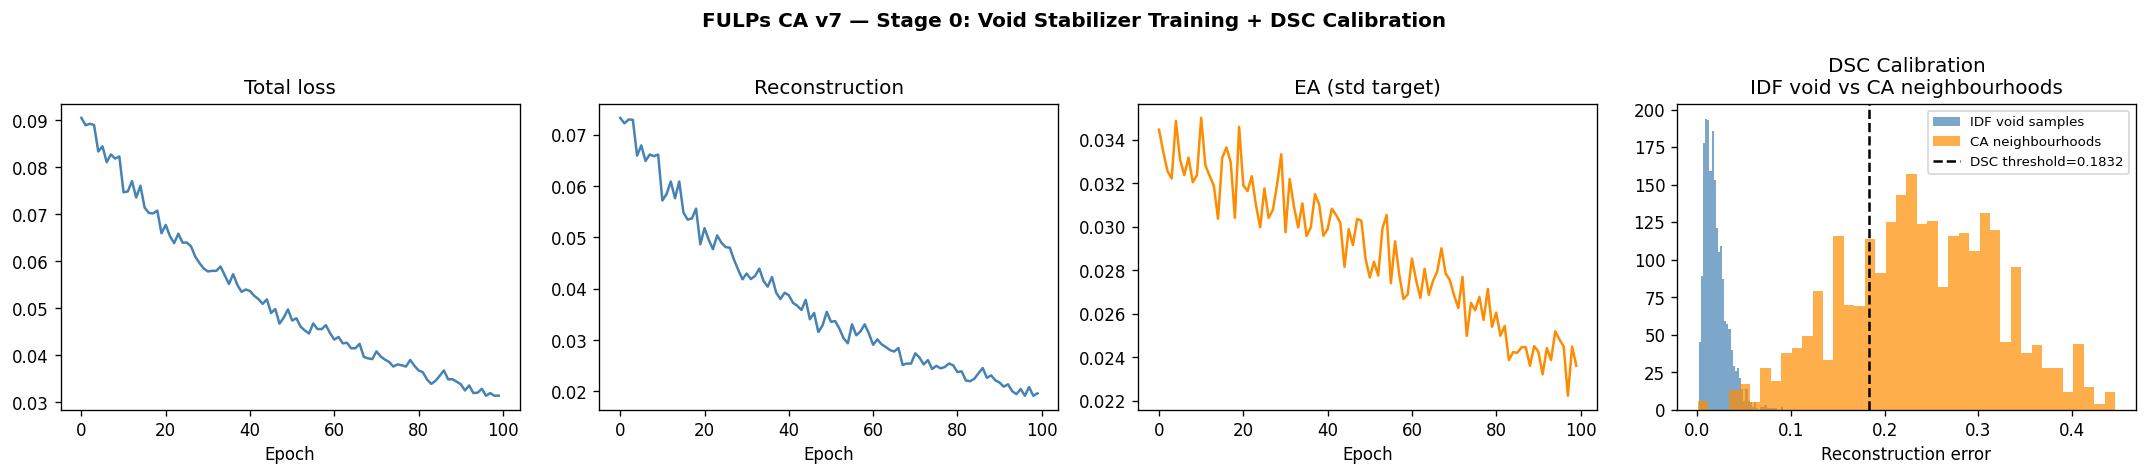

Void training complete.  Final reconstruction loss: 0.0196
DSC threshold (25th pct of CA distribution): 0.1832
Saved: /content/fulps_ca_v7_void_training.png


In [184]:
# ── Cell 6: Train VoidStabilizer + DSC Calibration ───────────────────────────
# Identical to v5. Model is trained once and frozen for all runs.

VOID_MODEL, void_loss_hist = train_void_stabilizer(IDF_MEANS, IDF_STDS, IDF_L, seed=42)

# DSC threshold calibration
with torch.no_grad():
    _void_s = torch.FloatTensor(sample_idf(IDF_MEANS, IDF_STDS, IDF_L, 2000))
    _void_xh, _ = VOID_MODEL(_void_s)
    _void_err = nn.functional.mse_loss(_void_s, _void_xh, reduction='none').mean(dim=1).numpy()

# Sample CA neighbourhoods for calibration
np.random.seed(99)
_cal_grid = np.random.randint(0, 2, (50, 50), dtype=np.int8)
_cal_nbrs = []
for di in range(-1, 2):
    for dj in range(-1, 2):
        _cal_nbrs.append(np.roll(np.roll(_cal_grid, di, 0), dj, 1).ravel())
_cal_nbr_arr = np.stack(_cal_nbrs, axis=1).astype(np.float32)
with torch.no_grad():
    _cal_t = torch.FloatTensor(_cal_nbr_arr)
    _cal_xh, _ = VOID_MODEL(_cal_t)
    _ca_err = nn.functional.mse_loss(_cal_t, _cal_xh, reduction='none').mean(dim=1).numpy()

DSC_THRESHOLD = float(np.percentile(_ca_err, 25))

# ── Plot: Void Training + DSC Calibration ────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('FULPs CA v7 — Stage 0: Void Stabilizer Training + DSC Calibration',
             fontsize=12, fontweight='bold')

for ax, col, lbl in zip(axes[:3],
                        [void_loss_hist[:,0], void_loss_hist[:,1], void_loss_hist[:,2]],
                        ['Total loss', 'Reconstruction', 'EA (std target)']):
    ax.plot(col, color='steelblue' if lbl!='EA (std target)' else 'darkorange')
    ax.set_title(lbl); ax.set_xlabel('Epoch')

ax = axes[3]
ax.hist(_void_err, bins=40, alpha=0.7, color='steelblue', label='IDF void samples')
ax.hist(_ca_err,   bins=40, alpha=0.7, color='darkorange', label='CA neighbourhoods')
ax.axvline(DSC_THRESHOLD, color='black', linestyle='--', label=f'DSC threshold={DSC_THRESHOLD:.4f}')
ax.set_title('DSC Calibration\nIDF void vs CA neighbourhoods')
ax.set_xlabel('Reconstruction error'); ax.legend(fontsize=8)

plt.tight_layout()
vp = os.path.join(OUT_DIR, 'fulps_ca_v7_void_training.png')
plt.savefig(vp, dpi=150, bbox_inches='tight'); plt.show()
print(f'Void training complete.  Final reconstruction loss: {void_loss_hist[-1,1]:.4f}')
print(f'DSC threshold (25th pct of CA distribution): {DSC_THRESHOLD:.4f}')
print(f'Saved: {vp}')

In [185]:
# ── Cell 7: GoL Truth Tables (unchanged from v5) ─────────────────────────────
def build_gol_truth(perturbed=False):
    truth = np.zeros(N_STATES, dtype=np.int8)
    for s in range(N_STATES):
        centre = (s >> 4) & 1
        neighbours = bin(s).count('1') - centre
        if centre == 1:
            truth[s] = 1 if (neighbours in ({2,3,4} if perturbed else {2,3})) else 0
        else:
            truth[s] = 1 if neighbours == 3 else 0
    return truth

GOL_TRUTH_ORIG = build_gol_truth(perturbed=False)
GOL_TRUTH_PERT = build_gol_truth(perturbed=True)
AFFECTED_MASK  = (GOL_TRUTH_ORIG != GOL_TRUTH_PERT)

print(f'GoL truth tables ready.  Affected states: {AFFECTED_MASK.sum()}/512')

GoL truth tables ready.  Affected states: 70/512


In [186]:
import numpy as np

# ── Neighbourhood encoding (unchanged) ───────────────────────────────────────
_II = np.repeat(np.arange(GRID_H), GRID_W)
_JJ = np.tile  (np.arange(GRID_W), GRID_H)

def encode_neighbourhoods(grid):
    """Returns (nbr_indices [H,W], nbr_flat [H*W, 9])."""
    rows = []
    for di in range(-1, 2):
        for dj in range(-1, 2):
            rows.append(np.roll(np.roll(grid, di, 0), dj, 1).ravel())
    nbr_flat = np.stack(rows, axis=1).astype(np.float32)
    # Index into 512-state table: bit-pack (centre at position 4)
    bits = nbr_flat.astype(np.int32)
    weights = 2**np.arange(9, dtype=np.int32)
    nbr_idx = (bits @ weights).reshape(GRID_H, GRID_W)
    return nbr_idx, nbr_flat

# ── Metric helpers (unchanged) ────────────────────────────────────────────────
def table_accuracy_grid(table, truth):
    p = table[..., 1] / np.maximum(table.sum(axis=-1), 1)
    return (((p > BASE_THRESHOLD).astype(np.int8) == truth[None, None, :]).mean(axis=-1)
            .astype(np.float32))

def table_coverage_grid(table):
    return (table.max(axis=-1) > 1.0).mean(axis=-1).astype(np.float32)

def per_state_accuracy_grid(table, truth):
    obs = (table.max(axis=-1) > 1.0)
    p   = table[..., 1] / np.maximum(table.sum(axis=-1), 1)
    corr = ((p > BASE_THRESHOLD).astype(np.int8) == truth[None, None, :]) & obs
    n = obs.sum(axis=-1).astype(np.float32)
    return np.where(n > 0, corr.sum(axis=-1).astype(np.float32) / np.maximum(n, 1),
                    np.nan).astype(np.float32)

def affected_state_accuracy(table, nbr_indices, truth):
    # Flatten nbr_indices to match _II and _JJ for advanced indexing
    nbr_indices_flat = nbr_indices.ravel()
    ia = AFFECTED_MASK[nbr_indices_flat]; n = int(ia.sum())
    if n == 0: return np.nan, 0
    c = table[_II, _JJ, nbr_indices_flat]
    p = c[..., 1] / np.maximum(c.sum(axis=-1), 1)
    return float(((p > BASE_THRESHOLD).astype(np.int8)[ia] == truth[nbr_indices_flat][ia]).mean()), n

def detect_stable_cells(sh, mc=STABLE_MAX_CHANGES):
    return np.sum(np.abs(np.diff(sh.astype(np.int16), axis=0)), axis=0) <= mc

def compute_cv(pl, s, e):
    a = np.array(pl[s:e], dtype=np.float64)
    return float(a.std() / a.mean()) if a.mean() > 1e-6 else np.nan

def compute_morans_i(binary_grid):
    """Moran's I spatial autocorrelation (toroidal 8-connectivity). Range approx [-1,1+]."""
    x = binary_grid.astype(np.float64)
    n = x.size; mean_x = x.mean()
    if mean_x < 1e-9 or mean_x > 1-1e-9: return 0.0
    z = x - mean_x
    lag = np.zeros_like(z)
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            if di==0 and dj==0: continue
            lag += np.roll(np.roll(z, di, 0), dj, 1)
    lag /= 8.0
    num   = n * np.sum(z * lag)
    denom = 8.0 * np.sum(z**2)
    return float(num / denom) if abs(denom) > 1e-9 else 0.0

def compute_morans_i_rule(rule_map, rule_id):
    """Moran's I for spatial clustering of cells using a specific rule."""
    return compute_morans_i((rule_map == rule_id).astype(np.float64))

def compute_nbr_mean_distress(distress_grid):
    nbr_sum = np.zeros((GRID_H, GRID_W), dtype=np.float32)
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            if di==0 and dj==0: continue
            nbr_sum += np.roll(np.roll(distress_grid, di, 0), dj, 1)
    return nbr_sum / 8.0

def cre_timestep(contra_history, pre_mean, post_start, tolerance=0.05):
    if np.isnan(pre_mean): return float(N_TIMESTEPS)
    threshold = pre_mean + tolerance
    for t in range(post_start, N_TIMESTEPS - 4):
        if all(contra_history[t+k] <= threshold for k in range(5)):
            return float(t)
    return float(N_TIMESTEPS)

def om(arr, mask):
    if not mask.any(): return np.nan
    v = arr[mask]; v = v[~np.isnan(v)]
    return float(v.mean()) if len(v) > 0 else np.nan

# ── v6 NEW: ARS metric helpers ────────────────────────────────────────────────

def shannon_entropy(counts):
    """
    Rule Diversity Index: Shannon entropy of rule distribution.
    counts: array of length N_RULES with cell counts per rule.
    Returns H in [0, log2(N_RULES)]. Zero = all cells on same rule.
    """
    total = counts.sum()
    if total == 0: return 0.0
    p = counts / total
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))

def rule_dominance(rule_map):
    """
    Rule Dominance: fraction of cells using the most common rule.
    Returns (dominance_fraction, dominant_rule_id).
    """
    counts = np.bincount(rule_map.ravel(), minlength=N_RULES)
    dom_id = int(np.argmax(counts))
    return float(counts[dom_id] / counts.sum()), dom_id

def compute_rule_counts(rule_map):
    """Return array of length N_RULES with per-rule cell counts."""
    return np.bincount(rule_map.ravel(), minlength=N_RULES).astype(np.float32)

print('Grid + ARS utilities defined.')
print('  v6 new: shannon_entropy, rule_dominance, compute_rule_counts, compute_morans_i_rule')

Grid + ARS utilities defined.
  v6 new: shannon_entropy, rule_dominance, compute_rule_counts, compute_morans_i_rule


In [187]:
import numpy as np
import torch
import torch.nn as nn

# ── State initialisers (unchanged from v5) ────────────────────────────────────
def init_tables():    return np.ones((GRID_H, GRID_W, N_STATES, 2), dtype=np.float32)
def init_are_state(): return {'pos_rep':    np.zeros((GRID_H, GRID_W, REP_DIM), dtype=np.float32),
                               'neg_rep':    np.zeros((GRID_H, GRID_W, REP_DIM), dtype=np.float32),
                               'pos_active': np.zeros((GRID_H, GRID_W), dtype=bool),
                               'neg_active': np.zeros((GRID_H, GRID_W), dtype=bool),
                               'margin_ema': np.zeros((GRID_H, GRID_W), dtype=np.float32)}
def init_conv_state(): return {'f_timestep':   np.full((GRID_H,GRID_W), float(N_TIMESTEPS), dtype=np.float32),
                                'f_locked':      np.zeros((GRID_H, GRID_W), dtype=bool),
                                'visit_counts':  np.zeros((GRID_H, GRID_W, N_STATES), dtype=np.int32)}
def init_rec_state():  return {'recovery_t':    np.full((GRID_H,GRID_W), float(N_TIMESTEPS), dtype=np.float32),
                                'rec_locked':    np.zeros((GRID_H, GRID_W), dtype=bool),
                                'has_observed':  np.zeros((GRID_H, GRID_W), dtype=bool)}

# ── v6 NEW: ARS state initialiser ────────────────────────────────────────────
def init_ars_state():
    """
    New state variables introduced in v6 for the ARS condition.

    active_rule      : (H,W) int8  — which rule governs each cell (0–3).
    rule_usage       : (H,W,R)     — how many timesteps each rule has been active.
    rule_successes   : (H,W,R)     — successful predictions while on each rule.
    rule_contra_hist : (H,W,R)     — contradiction events accumulated per rule.
    rule_recovery    : (H,W,R)     — post-perturbation recovery timestep per rule
                                     (proxy: 1/mean_contra after perturbation).
    cooldown         : (H,W)       — timesteps remaining before cell may switch again.
    switch_count     : (H,W)       — total number of rule switches by this cell.
    rule_at_perturb  : (H,W)       — which rule each cell was on when perturbation hit.
    """
    R = N_RULES
    return {
        'active_rule':      np.zeros((GRID_H, GRID_W), dtype=np.int8),
        'rule_usage':       np.zeros((GRID_H, GRID_W, R), dtype=np.float32),
        'rule_successes':   np.zeros((GRID_H, GRID_W, R), dtype=np.float32),
        'rule_contra_hist': np.zeros((GRID_H, GRID_W, R), dtype=np.float32),
        'rule_recovery':    np.full((GRID_H, GRID_W, R), np.nan, dtype=np.float32),
        'cooldown':         np.zeros((GRID_H, GRID_W), dtype=np.int32),
        'switch_count':     np.zeros((GRID_H, GRID_W), dtype=np.int32),
        'rule_at_perturb':  np.zeros((GRID_H, GRID_W), dtype=np.int8),
    }

# ── ARE functions (unchanged from v5) ────────────────────────────────────────
def compute_are_margin(reps_flat, are_state, threshold):
    rep = reps_flat.reshape(GRID_H, GRID_W, REP_DIM)
    def cs(a, b):
        d = np.sum(a*b, axis=-1)
        n = np.linalg.norm(a, axis=-1) * np.linalg.norm(b, axis=-1)
        return d / np.where(n > 1e-8, n, 1e-8)
    ps = np.where(are_state['pos_active'], cs(rep, are_state['pos_rep']), 0.0)
    ns = np.where(are_state['neg_active'], cs(rep, are_state['neg_rep']), 0.0)
    m  = ps - ns
    both   = are_state['pos_active'] & are_state['neg_active']
    contra = (np.abs(m) < threshold) & (np.maximum(ps, ns) > CONF_GATE) & both
    return m, contra, ps, ns

def update_are_buffers(are_state, reps_flat, outcomes):
    rep = reps_flat.reshape(GRID_H, GRID_W, REP_DIM)
    for mask, key in [(outcomes==1, 'pos'), (outcomes==0, 'neg')]:
        if mask.any():
            are_state[f'{key}_rep'][mask] = ((1-EMA_ALPHA)*are_state[f'{key}_rep'][mask]
                                             + EMA_ALPHA*rep[mask])
            are_state[f'{key}_active'][mask] = True

def update_table_single(table, ni, outcomes, cw):
    table[_II, _JJ, ni.ravel(), outcomes.ravel().astype(int)] += cw.ravel()

def update_convergence_single(cs, t, table, ni, outcomes, ac):
    ni_flat = ni.ravel()
    outcomes_flat = outcomes.ravel()
    ac_flat = ac.ravel()

    cs['visit_counts'][_II, _JJ, ni_flat] += 1
    v  = cs['visit_counts'][_II, _JJ, ni_flat]
    o2 = (v >= 2)

    c  = table[_II, _JJ, ni_flat]
    p = c[...,1] / np.maximum(c.sum(axis=-1), 1)

    th = np.where(ac_flat, CONTRA_THRESHOLD, BASE_THRESHOLD)

    corr = ((p > th).astype(np.int8) == outcomes_flat)
    conf = np.where(outcomes_flat==1, p > th, p < (1-th))

    newly = corr & conf & o2 & ~cs['f_locked'].ravel()

    cs['f_timestep'].ravel()[newly] = t
    cs['f_locked'].ravel()[newly] = True

def update_recovery_single(rs, t, table, ni, ac):
    ni_flat = ni.ravel()
    ac_flat = ac.ravel()

    ia = AFFECTED_MASK[ni_flat]
    if not ia.any(): return
    rs['has_observed'].ravel()[ia] = True

    c  = table[_II, _JJ, ni_flat]
    p = c[...,1] / np.maximum(c.sum(axis=-1), 1)

    th = np.where(ac_flat, CONTRA_THRESHOLD, BASE_THRESHOLD)

    newly = ia & (p > th) & ~rs['rec_locked'].ravel()
    rs['recovery_t'].ravel()[newly] = t
    rs['rec_locked'].ravel()[newly] = True

def compute_gating_mask(ac_gate, pos_sim, neg_sim, are_state, nbr_distress=None):
    max_sim = np.maximum(pos_sim, neg_sim)
    if nbr_distress is not None:
        nbr_distress_clipped = np.clip(nbr_distress, 0.0, 1.0)
        effective_conf = GATE_CONF_GATE * (1.0 - SIGNAL_WEIGHT * nbr_distress_clipped)
        strong_belief  = max_sim > effective_conf
    else:
        strong_belief = max_sim > GATE_CONF_GATE
    return ac_gate & strong_belief

def compute_distress(pos_sim, neg_sim, margin):
    return np.maximum(pos_sim, neg_sim) * np.clip(np.abs(margin), 0.0, 1.0)

# ── v6 NEW: ARS update function ───────────────────────────────────────────────
def update_ars_state(ars, t, contra_mask, count_neighbours_current, current_grid, actual_outcome):
    """
    Update ARS bookkeeping for the current timestep:
      - Accumulate per-rule usage, contradiction, and success counts for ALL rules.
      - Decrement cooldown timers.

    contra_mask  : (H,W) bool — which cells have active ARE contradiction
    count_neighbours_current: (H,W) int8 — neighbourhood counts of the current grid
    current_grid : (H,W) int8 — the current state of the ARS grid
    actual_outcome: (H,W) int8 — the actual outcome (next state) of the ARS grid
    """
    nc = count_neighbours_current
    for r in range(N_RULES):
        rt = RULE_TABLES[r]
        # what rule r would have predicted based on current_grid and its neighbours
        rule_pred = rt[current_grid, nc]
        rule_correct = (rule_pred == actual_outcome)
        ars['rule_usage'][..., r] += 1.0  # all rules get usage every step
        ars['rule_successes'][rule_correct, r] += 1.0
        ars['rule_contra_hist'][contra_mask & ~rule_correct, r] += 1.0
    # Decrement cooldown
    ars['cooldown'] = np.maximum(ars['cooldown'] - 1, 0)

def compute_rule_score(ars):
    """
    Local rule quality estimate for each cell × rule combination.
    Score = (successes / max(usage, 1)) - lambda * (contra / max(usage, 1))
    where lambda=0.5 penalises contradiction.

    Returns score array of shape (H, W, N_RULES).
    """
    LAMBDA = 0.5  # contradiction penalty weight
    usage  = ars['rule_usage']      # (H,W,R)
    succ   = ars['rule_successes']
    contra = ars['rule_contra_hist']

    safe_usage = np.maximum(usage, 1.0)
    score = (succ / safe_usage) - LAMBDA * (contra / safe_usage)

    # Exploration bonus for under-sampled rules removed as per user instruction.

    return score

def maybe_switch_rules(ars, t):
    """
    Periodic rule reconsideration at multiples of SWITCH_INTERVAL.
    Only cells whose cooldown has expired may switch.
    Selection is softmax over rule scores (temperature = EXPLOIT_TEMP).
    Cells that switch get a new cooldown.

    This is the only place rule_map changes. No global information is used.
    """
    if t == 0 or (t % SWITCH_INTERVAL != 0):
        return 0  # no switches this timestep

    can_switch = (ars['cooldown'] == 0)  # (H, W) bool
    if not can_switch.any():
        return 0

    scores = compute_rule_score(ars)  # (H, W, R)

    # Softmax over rules for each cell
    logits = scores / EXPLOIT_TEMP
    logits -= logits.max(axis=-1, keepdims=True)  # numerical stability
    exp_l  = np.exp(logits)
    probs  = exp_l / exp_l.sum(axis=-1, keepdims=True)  # (H, W, R)

    # Sample a new rule for each eligible cell
    flat_probs = probs.reshape(-1, N_RULES)  # (H*W, R)
    cumprobs   = flat_probs.cumsum(axis=1)
    rands      = np.random.rand(GRID_H * GRID_W, 1)
    new_rules  = (rands > cumprobs).sum(axis=1).clip(0, N_RULES-1).astype(np.int8)
    new_rules  = new_rules.reshape(GRID_H, GRID_W)

    old_rules = ars['active_rule'].copy()
    switched  = can_switch & (new_rules != old_rules)

    ars['active_rule'][switched] = new_rules[switched]
    ars['cooldown'][switched]    = SWITCH_COOLDOWN
    ars['switch_count'][switched] += 1

    return int(switched.sum())

In [188]:
# ── Cell 9b: v7 NEW — Arm-Pool Thompson Sampling ──────────────────────────────
#
# Each cell owns a pool of K_ARMS candidate rules ("arms"), each represented
# exactly like a canonical rule (18-bit birth/survive lookup table — see
# RULE_TABLES in Cell 3). Each arm carries its own Beta(alpha,beta) belief.
# Selection is standard Thompson Sampling over this pool: sample theta_k ~
# Beta(alpha_k, beta_k) for every arm, pick the argmax. This is the SAME
# selection mechanism the original Bayesian v7 used over a fixed 4-rule
# library — the only change is that the "library" is now K per-cell slots
# that can themselves evolve.
#
# Evolution happens in two stages, both gated at SWITCH_INTERVAL:
#
#   1. Mutation-eviction (every cell, unconditional): the worst arm by
#      posterior mean (excluding whichever arm is currently active, which is
#      protected) is evicted and replaced with a mutated copy of the
#      currently-favoured arm (bit-flip at MUTATION_RATE), with its belief
#      reset to the uniform Beta(1,1) prior. This is what lets the pool wander
#      beyond the original 4 canonical rules over time -- there is always one
#      "experimental" slot being tried, and Thompson Sampling itself (not a
#      hand-set threshold) decides whether it's any good, honestly, through
#      accumulated evidence.
#
#   2. Spatial migration (only distressed cells): a cell whose own ARE-distress
#      is above the grid median, and whose best arm is beaten by a Moore
#      neighbour's best arm, pulls that neighbour's best arm into its own pool
#      (same worst-slot target, same fresh-prior reset). This is the
#      mechanism by which a genuinely strong arm spreads spatially -- gated by
#      the same distress signal already used for gating elsewhere in the
#      architecture, not a new invented channel.
#
# BACKWARD COMPATIBILITY: each cell's currently-active arm is mapped every
# timestep to its nearest canonical rule (min Hamming distance to A/B/C/D)
# and written into `active_rule`, so every existing rule-distribution/
# entropy/Markov/rule-map diagnostic keeps working unchanged. The arm itself
# is not constrained to the 4 canonical rules.

CANON_FLAT_V7 = np.array([rt.reshape(-1) for rt in RULE_TABLES])  # (4,18)

def init_v7_state():
    """
    genome_pool   : (H,W,K,2,9) int8   — K candidate rule genomes per cell,
                                          seeded from the canonical library.
    alpha, beta_param : (H,W,K) float32 — Beta belief per arm (uniform prior).
    active_slot   : (H,W) int8 — which pool slot is currently driving the tick.
    active_rule   : (H,W) int8 — nearest-canonical-rule label of active_slot's
                                  genome (diagnostics only).
    cooldown      : (H,W) int32 — timesteps until this cell may switch slot again.
    switch_count  : (H,W) int32 — total Thompson-Sampling slot changes.
    migration_count: (H,W) int32 — total spatial arm migrations received.
    rule_at_perturb: (H,W) int8 — active_rule snapshot at T_PERTURB.
    Working memory ring buffers (per-arm prediction correctness; shared
    environmental signals stay single-channel exactly as in v6 ARS/ARE).
    """
    H, W, K = GRID_H, GRID_W, K_ARMS
    pool = np.zeros((H, W, K, 2, 9), dtype=np.int8)
    for k in range(K):
        pool[:, :, k] = RULE_TABLES[k % len(RULE_TABLES)]
    return {
        'genome_pool':     pool,
        'alpha':           np.full((H, W, K), BETA_ALPHA_INIT, dtype=np.float32),
        'beta_param':      np.full((H, W, K), BETA_BETA_INIT,  dtype=np.float32),
        'active_slot':     np.zeros((H, W), dtype=np.int8),
        'active_rule':     np.zeros((H, W), dtype=np.int8),
        'cooldown':        np.zeros((H, W), dtype=np.int32),
        'switch_count':    np.zeros((H, W), dtype=np.int32),
        'migration_count': np.zeros((H, W), dtype=np.int32),
        'rule_at_perturb': np.zeros((H, W), dtype=np.int8),
        'wm_pred_success': np.zeros((H, W, K, WM_LENGTH), dtype=np.float32),
        'wm_contra':       np.zeros((H, W, WM_LENGTH), dtype=np.float32),
        'wm_survived':     np.zeros((H, W, WM_LENGTH), dtype=np.float32),
        'wm_nbr_surv':     np.zeros((H, W, WM_LENGTH), dtype=np.float32),
        'wm_ptr': 0,
        'last_distress': np.zeros((H, W), dtype=np.float32),
    }

def nearest_canonical_rule_v7(genome):
    """Min-Hamming-distance label (0-3) for a (H,W,2,9) genome array. Diagnostics only."""
    flat = genome.reshape(GRID_H, GRID_W, 18).astype(np.int8)
    dist = (flat[:, :, None, :] != CANON_FLAT_V7[None, None, :, :]).sum(axis=-1)
    return dist.argmin(axis=-1).astype(np.int8)

def get_active_genome_v7(v7):
    """Fancy-index each cell's currently-active arm out of its pool -> (H,W,2,9)."""
    ii, jj = np.indices((GRID_H, GRID_W))
    return v7['genome_pool'][ii, jj, v7['active_slot']]

def tick_genome(grid, genome):
    """Generalises tick_ars(): tick under a per-cell (H,W,2,9) genome table."""
    nc = count_neighbours(grid)
    ii, jj = np.indices(grid.shape)
    return genome[ii, jj, grid, np.clip(nc, 0, 8)]

def update_working_memory_v7(v7, nc, current_grid, next_grid, contra_mask):
    """
    Score EVERY arm in the pool via the same counterfactual trick used
    throughout this notebook: what would arm k have predicted, given what
    actually happened? Environmental terms (contradiction/survival/neighbour
    survival) are arm-independent, exactly as in the original per-rule
    Bayesian version.
    """
    ptr = v7['wm_ptr'] % WM_LENGTH
    nc_clip = np.clip(nc, 0, 8).astype(int)
    ii, jj = np.indices((GRID_H, GRID_W))
    ii3, jj3 = ii[:, :, None], jj[:, :, None]
    kk3 = np.arange(K_ARMS)[None, None, :]
    cg3, nc3 = current_grid[:, :, None], nc_clip[:, :, None]

    pred_all = v7['genome_pool'][ii3, jj3, kk3, cg3, nc3]           # (H,W,K)
    v7['wm_pred_success'][:, :, :, ptr] = (pred_all == next_grid[:, :, None]).astype(np.float32)
    v7['wm_contra'][:, :, ptr]   = contra_mask.astype(np.float32)
    v7['wm_survived'][:, :, ptr] = next_grid.astype(np.float32)

    nbr_surv = np.zeros((GRID_H, GRID_W), dtype=np.float32)
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            if di == 0 and dj == 0: continue
            nbr_surv += np.roll(np.roll(next_grid, di, 0), dj, 1).astype(np.float32)
    v7['wm_nbr_surv'][:, :, ptr] = nbr_surv / 8.0

    v7['wm_ptr'] += 1
    v7['active_rule'] = nearest_canonical_rule_v7(get_active_genome_v7(v7))

def compute_wm_summary_v7(v7):
    """Returns succ, fail : each (H,W,K) float32 in [0,1] -- one pair per arm."""
    filled = min(v7['wm_ptr'], WM_LENGTH)
    if filled == 0:
        half = np.full((GRID_H, GRID_W, K_ARMS), 0.5, dtype=np.float32)
        return half.copy(), half.copy()

    mean_pred   = v7['wm_pred_success'][:, :, :, :filled].mean(axis=-1)   # (H,W,K)
    mean_contra = v7['wm_contra'][:, :, :filled].mean(axis=-1)            # (H,W)
    mean_surv   = v7['wm_survived'][:, :, :filled].mean(axis=-1)
    mean_nbr    = v7['wm_nbr_surv'][:, :, :filled].mean(axis=-1)

    shared = (0.25 * (1.0 - mean_contra)
            + 0.125 * mean_surv
            + 0.125 * mean_nbr * NBR_SUCCESS_WEIGHT)

    succ = np.clip(0.50 * mean_pred + shared[:, :, None], 0.0, 1.0).astype(np.float32)
    fail = np.clip(0.50 * (1.0 - mean_pred) + 0.50 * mean_contra[:, :, None], 0.0, 1.0).astype(np.float32)
    return succ, fail

def maybe_evolve_v7(v7, t):
    """
    Periodic Thompson-Sampling reconsideration + arm-pool evolution.
    Returns (n_switch, n_migration).
    """
    v7['cooldown'] = np.maximum(v7['cooldown'] - 1, 0)
    if t == 0 or (t % SWITCH_INTERVAL != 0):
        return 0, 0

    succ, fail = compute_wm_summary_v7(v7)
    v7['alpha']      = BETA_DECAY * v7['alpha']      + succ
    v7['beta_param'] = BETA_DECAY * v7['beta_param'] + fail

    # ── Thompson Sampling: pick the arm to drive the tick this interval ──────
    theta = np.random.beta(v7['alpha'], v7['beta_param'])   # (H,W,K)
    new_slot   = theta.argmax(axis=-1).astype(np.int8)
    can_switch = v7['cooldown'] == 0
    switched   = can_switch & (new_slot != v7['active_slot'])
    v7['active_slot'][switched] = new_slot[switched]
    v7['cooldown'][switched]    = SWITCH_COOLDOWN
    v7['switch_count'][switched] += 1
    n_switch = int(switched.sum())

        # ── Distress-gated Mutation-eviction: refresh the worst arm probabilistically ────
    ii, jj = np.indices((GRID_H, GRID_W))

    # Posterior mean of each arm
    post_mean = v7['alpha'] / (v7['alpha'] + v7['beta_param'])

    # Never evict the currently-active arm
    masked_mean = post_mean.copy()
    masked_mean[ii, jj, v7['active_slot']] = np.inf
    worst_slot = masked_mean.argmin(axis=-1).astype(np.int8)

    # ------------------------------------------------------------------
    # Distress-driven mutation probability
    #
    # Healthy cells retain a small background chance of innovation,
    # while distressed cells become increasingly likely to explore.
    # Uses the median distress as an adaptive scale rather than a
    # hand-tuned threshold.
    # ------------------------------------------------------------------
    med_dist = np.median(v7['last_distress']) + 1e-8

    scaled_distress = v7['last_distress'] / med_dist

    p_mutate = (
        MIN_MUTATION_PROB
        + (1.0 - MIN_MUTATION_PROB)
        * (1.0 - np.exp(-scaled_distress))
    )

    p_mutate = np.clip(p_mutate, MIN_MUTATION_PROB, 1.0)

    mutate_mask = np.random.random((GRID_H, GRID_W)) < p_mutate
    n_mutation = int(mutate_mask.sum())

    # Generate candidate mutants
    active_genome = get_active_genome_v7(v7)
    flip = np.random.random(active_genome.shape) < MUTATION_RATE
    mutant = np.where(flip, 1 - active_genome, active_genome).astype(np.int8)

    # Only replace the worst arm where mutation is triggered
    rows, cols = np.where(mutate_mask)

    if len(rows) > 0:
        slots = worst_slot[rows, cols]

        v7['genome_pool'][rows, cols, slots] = mutant[rows, cols]
        v7['alpha'][rows, cols, slots] = BETA_ALPHA_INIT
        v7['beta_param'][rows, cols, slots] = BETA_BETA_INIT

    # ── Spatial migration: distressed cells may adopt a fitter neighbour ────
    own_best_mean = post_mean.max(axis=-1)
    best_nbr_mean = own_best_mean.copy()
    best_di = np.zeros_like(own_best_mean, dtype=np.int8)
    best_dj = np.zeros_like(own_best_mean, dtype=np.int8)
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            if di == 0 and dj == 0: continue
            nbr_mean = np.roll(np.roll(own_best_mean, di, 0), dj, 1)
            better = nbr_mean > best_nbr_mean
            best_nbr_mean = np.where(better, nbr_mean, best_nbr_mean)
            best_di = np.where(better, di, best_di)
            best_dj = np.where(better, dj, best_dj)

    med_dist = np.median(v7['last_distress'])
    eligible = (best_nbr_mean > own_best_mean) & (v7['last_distress'] > med_dist)
    n_migration = 0
    if eligible.any():
        idxs = np.argwhere(eligible)
        for (i, j) in idxs:
            ni = (i + int(best_di[i, j])) % GRID_H
            nj = (j + int(best_dj[i, j])) % GRID_W
            nbr_best_slot = int(post_mean[ni, nj].argmax())
            slot = int(worst_slot[i, j])
            v7['genome_pool'][i, j, slot] = v7['genome_pool'][ni, nj, nbr_best_slot]
            v7['alpha'][i, j, slot]      = BETA_ALPHA_INIT
            v7['beta_param'][i, j, slot] = BETA_BETA_INIT
            v7['migration_count'][i, j] += 1
            n_migration += 1

    v7['active_rule'] = nearest_canonical_rule_v7(get_active_genome_v7(v7))
    return n_switch, n_migration

def compute_bayesian_uncertainty_v7(v7):
    """Posterior variance of the CURRENTLY ACTIVE arm's Beta belief, per cell."""
    ii, jj = np.indices((GRID_H, GRID_W))
    a = v7['alpha'][ii, jj, v7['active_slot']]
    b = v7['beta_param'][ii, jj, v7['active_slot']]
    return (a * b) / (np.square(a + b) * (a + b + 1.0))

def compute_attention_entropy_v7(v7):
    """
    'Attention' over the arm pool: softmax(posterior_mean / EXPLOIT_TEMP) across
    the K arms, per cell -- i.e. how much relative weight a cell's belief state
    places on each candidate rule right now, using the same temperature concept
    ARS already uses for its own softmax rule selection (EXPLOIT_TEMP).
    Entropy of that distribution, normalised to [0,1] by log(K):
      -> 1.0 = attention spread evenly across all K arms (fully undecided)
      -> 0.0 = attention fully concentrated on one arm (fully decided)
    This is a pool-level complement to compute_bayesian_uncertainty_v7 (which
    only looks at the variance of the single currently-active arm's belief).
    Returns (H,W) float32 in [0,1].
    """
    post_mean = v7['alpha'] / (v7['alpha'] + v7['beta_param'])   # (H,W,K)
    logits = post_mean / EXPLOIT_TEMP
    logits = logits - logits.max(axis=-1, keepdims=True)
    exp_l = np.exp(logits)
    attn = exp_l / exp_l.sum(axis=-1, keepdims=True)             # (H,W,K)
    ent = -(attn * np.log(attn + 1e-12)).sum(axis=-1)
    return (ent / np.log(K_ARMS)).astype(np.float32)

print('v7 Arm-Pool Thompson Sampling defined.')
print('  Functions: init_v7_state, get_active_genome_v7, tick_genome')
print('  Functions: update_working_memory_v7, compute_wm_summary_v7, maybe_evolve_v7')
print('  Functions: compute_bayesian_uncertainty_v7, compute_attention_entropy_v7, nearest_canonical_rule_v7')
print(f'  K_ARMS={K_ARMS}  BETA_DECAY={BETA_DECAY}  MUTATION_RATE={MUTATION_RATE}')
print(f'  Per-cell computational cost: O(K_ARMS)={K_ARMS}x the single-rule ARS cost per timestep')
print(f'  (all {K_ARMS} arms scored every step via vectorised counterfactual lookup, no Python loop over arms)')


v7 Arm-Pool Thompson Sampling defined.
  Functions: init_v7_state, get_active_genome_v7, tick_genome
  Functions: update_working_memory_v7, compute_wm_summary_v7, maybe_evolve_v7
  Functions: compute_bayesian_uncertainty_v7, compute_attention_entropy_v7, nearest_canonical_rule_v7
  K_ARMS=4  BETA_DECAY=0.98  MUTATION_RATE=0.08
  Per-cell computational cost: O(K_ARMS)=4x the single-rule ARS cost per timestep
  (all 4 arms scored every step via vectorised counterfactual lookup, no Python loop over arms)


In [189]:
import numpy as np
import torch
import torch.nn as nn

# ── State initialisers (unchanged from v5) ────────────────────────────────────
def init_tables():    return np.ones((GRID_H, GRID_W, N_STATES, 2), dtype=np.float32)
def init_are_state(): return {'pos_rep':    np.zeros((GRID_H, GRID_W, REP_DIM), dtype=np.float32),
                               'neg_rep':    np.zeros((GRID_H, GRID_W, REP_DIM), dtype=np.float32),
                               'pos_active': np.zeros((GRID_H, GRID_W), dtype=bool),
                               'neg_active': np.zeros((GRID_H, GRID_W), dtype=bool),
                               'margin_ema': np.zeros((GRID_H, GRID_W), dtype=np.float32)}
def init_conv_state(): return {'f_timestep':   np.full((GRID_H,GRID_W), float(N_TIMESTEPS), dtype=np.float32),
                                'f_locked':      np.zeros((GRID_H, GRID_W), dtype=bool),
                                'visit_counts':  np.zeros((GRID_H, GRID_W, N_STATES), dtype=np.int32)}
def init_rec_state():  return {'recovery_t':    np.full((GRID_H,GRID_W), float(N_TIMESTEPS), dtype=np.float32),
                                'rec_locked':    np.zeros((GRID_H, GRID_W), dtype=bool),
                                'has_observed':  np.zeros((GRID_H, GRID_W), dtype=bool)}

# ── v6 NEW: ARS state initialiser ────────────────────────────────────────────
def init_ars_state():
    """
    New state variables introduced in v6 for the ARS condition.

    active_rule      : (H,W) int8  — which rule governs each cell (0–3).
    rule_usage       : (H,W,R)     — how many timesteps each rule has been active.
    rule_successes   : (H,W,R)     — successful predictions while on each rule.
    rule_contra_hist : (H,W,R)     — contradiction events accumulated per rule.
    rule_recovery    : (H,W,R)     — post-perturbation recovery timestep per rule
                                     (proxy: 1/mean_contra after perturbation).
    cooldown         : (H,W)       — timesteps remaining before cell may switch again.
    switch_count     : (H,W)       — total number of rule switches by this cell.
    rule_at_perturb  : (H,W)       — which rule each cell was on when perturbation hit.
    """
    R = N_RULES
    return {
        'active_rule':      np.zeros((GRID_H, GRID_W), dtype=np.int8),
        'rule_usage':       np.zeros((GRID_H, GRID_W, R), dtype=np.float32),
        'rule_successes':   np.zeros((GRID_H, GRID_W, R), dtype=np.float32),
        'rule_contra_hist': np.zeros((GRID_H, GRID_W, R), dtype=np.float32),
        'rule_recovery':    np.full((GRID_H, GRID_W, R), np.nan, dtype=np.float32),
        'cooldown':         np.zeros((GRID_H, GRID_W), dtype=np.int32),
        'switch_count':     np.zeros((GRID_H, GRID_W), dtype=np.int32),
        'rule_at_perturb':  np.zeros((GRID_H, GRID_W), dtype=np.int8),
    }

# ── ARE functions (unchanged from v5) ────────────────────────────────────────
def compute_are_margin(reps_flat, are_state, threshold):
    rep = reps_flat.reshape(GRID_H, GRID_W, REP_DIM)
    def cs(a, b):
        d = np.sum(a*b, axis=-1)
        n = np.linalg.norm(a, axis=-1) * np.linalg.norm(b, axis=-1)
        return d / np.where(n > 1e-8, n, 1e-8)
    ps = np.where(are_state['pos_active'], cs(rep, are_state['pos_rep']), 0.0)
    ns = np.where(are_state['neg_active'], cs(rep, are_state['neg_rep']), 0.0)
    m  = ps - ns
    both   = are_state['pos_active'] & are_state['neg_active']
    contra = (np.abs(m) < threshold) & (np.maximum(ps, ns) > CONF_GATE) & both
    return m, contra, ps, ns

def update_are_buffers(are_state, reps_flat, outcomes):
    rep = reps_flat.reshape(GRID_H, GRID_W, REP_DIM)
    for mask, key in [(outcomes==1, 'pos'), (outcomes==0, 'neg')]:
        if mask.any():
            are_state[f'{key}_rep'][mask] = ((1-EMA_ALPHA)*are_state[f'{key}_rep'][mask]
                                             + EMA_ALPHA*rep[mask])
            are_state[f'{key}_active'][mask] = True

def update_table_single(table, ni, outcomes, cw):
    table[_II, _JJ, ni.ravel(), outcomes.ravel().astype(int)] += cw.ravel()

def update_convergence_single(cs, t, table, ni, outcomes, ac):
    ni_flat = ni.ravel()
    outcomes_flat = outcomes.ravel()
    ac_flat = ac.ravel()

    cs['visit_counts'][_II, _JJ, ni_flat] += 1
    v  = cs['visit_counts'][_II, _JJ, ni_flat]
    o2 = (v >= 2)

    c  = table[_II, _JJ, ni_flat]
    p = c[...,1] / np.maximum(c.sum(axis=-1), 1)

    th = np.where(ac_flat, CONTRA_THRESHOLD, BASE_THRESHOLD)

    corr = ((p > th).astype(np.int8) == outcomes_flat)
    conf = np.where(outcomes_flat==1, p > th, p < (1-th))

    newly = corr & conf & o2 & ~cs['f_locked'].ravel()

    cs['f_timestep'].ravel()[newly] = t
    cs['f_locked'].ravel()[newly] = True

def update_recovery_single(rs, t, table, ni, ac):
    ni_flat = ni.ravel()
    ac_flat = ac.ravel()

    ia = AFFECTED_MASK[ni_flat]
    if not ia.any(): return
    rs['has_observed'].ravel()[ia] = True

    c  = table[_II, _JJ, ni_flat]
    p = c[...,1] / np.maximum(c.sum(axis=-1), 1)

    th = np.where(ac_flat, CONTRA_THRESHOLD, BASE_THRESHOLD)

    newly = ia & (p > th) & ~rs['rec_locked'].ravel()
    rs['recovery_t'].ravel()[newly] = t
    rs['rec_locked'].ravel()[newly] = True

def compute_gating_mask(ac_gate, pos_sim, neg_sim, are_state, nbr_distress=None):
    max_sim = np.maximum(pos_sim, neg_sim)
    if nbr_distress is not None:
        nbr_distress_clipped = np.clip(nbr_distress, 0.0, 1.0)
        effective_conf = GATE_CONF_GATE * (1.0 - SIGNAL_WEIGHT * nbr_distress_clipped)
        strong_belief  = max_sim > effective_conf
    else:
        strong_belief = max_sim > GATE_CONF_GATE
    return ac_gate & strong_belief

def compute_distress(pos_sim, neg_sim, margin):
    return np.maximum(pos_sim, neg_sim) * np.clip(np.abs(margin), 0.0, 1.0)

# ── v6 NEW: ARS update function ───────────────────────────────────────────────
def update_ars_state(ars, t, contra_mask, count_neighbours_current, current_grid, actual_outcome):
    """
    Update ARS bookkeeping for the current timestep:
      - Accumulate per-rule usage, contradiction, and success counts for ALL rules.
      - Decrement cooldown timers.

    contra_mask  : (H,W) bool — which cells have active ARE contradiction
    count_neighbours_current: (H,W) int8 — neighbourhood counts of the current grid
    current_grid : (H,W) int8 — the current state of the ARS grid
    actual_outcome: (H,W) int8 — the actual outcome (next state) of the ARS grid
    """
    nc = count_neighbours_current
    for r in range(N_RULES):
        rt = RULE_TABLES[r]
        # what rule r would have predicted based on current_grid and its neighbours
        rule_pred = rt[current_grid, nc]
        rule_correct = (rule_pred == actual_outcome)
        ars['rule_usage'][..., r] += 1.0  # all rules get usage every step
        ars['rule_successes'][rule_correct, r] += 1.0
        ars['rule_contra_hist'][contra_mask & ~rule_correct, r] += 1.0
    # Decrement cooldown
    ars['cooldown'] = np.maximum(ars['cooldown'] - 1, 0)

def compute_rule_score(ars):
    """
    Local rule quality estimate for each cell × rule combination.
    Score = (successes / max(usage, 1)) - lambda * (contra / max(usage, 1))
    where lambda=0.5 penalises contradiction.

    Returns score array of shape (H, W, N_RULES).
    """
    LAMBDA = 0.5  # contradiction penalty weight
    usage  = ars['rule_usage']      # (H,W,R)
    succ   = ars['rule_successes']
    contra = ars['rule_contra_hist']

    safe_usage = np.maximum(usage, 1.0)
    score = (succ / safe_usage) - LAMBDA * (contra / safe_usage)

    # Exploration bonus for under-sampled rules removed as per user instruction.

    return score

def maybe_switch_rules(ars, t):
    """
    Periodic rule reconsideration at multiples of SWITCH_INTERVAL.
    Only cells whose cooldown has expired may switch.
    Selection is softmax over rule scores (temperature = EXPLOIT_TEMP).
    Cells that switch get a new cooldown.

    This is the only place rule_map changes. No global information is used.
    """
    if t == 0 or (t % SWITCH_INTERVAL != 0):
        return 0  # no switches this timestep

    can_switch = (ars['cooldown'] == 0)  # (H, W) bool
    if not can_switch.any():
        return 0

    scores = compute_rule_score(ars)  # (H, W, R)

    # Softmax over rules for each cell
    logits = scores / EXPLOIT_TEMP
    logits -= logits.max(axis=-1, keepdims=True)  # numerical stability
    exp_l  = np.exp(logits)
    probs  = exp_l / exp_l.sum(axis=-1, keepdims=True)  # (H, W, R)

    # Sample a new rule for each eligible cell
    flat_probs = probs.reshape(-1, N_RULES)  # (H*W, R)
    cumprobs   = flat_probs.cumsum(axis=1)
    rands      = np.random.rand(GRID_H * GRID_W, 1)
    new_rules  = (rands > cumprobs).sum(axis=1).clip(0, N_RULES-1).astype(np.int8)
    new_rules  = new_rules.reshape(GRID_H, GRID_W)

    old_rules = ars['active_rule'].copy()
    switched  = can_switch & (new_rules != old_rules)

    ars['active_rule'][switched] = new_rules[switched]
    ars['cooldown'][switched]    = SWITCH_COOLDOWN
    ars['switch_count'][switched] += 1

    return int(switched.sum())

print('FULPs state utilities defined (v6: ARS layer added).')
print('  New: init_ars_state, update_ars_state, compute_rule_score, maybe_switch_rules')
# ── Cell 10: Simulation Engine ────────────────────────────────────────────────
#
# SIX simultaneous conditions per seed.
#
#   base    : standard GoL + uniform table                    (unchanged from v5)
#   learn   : standard GoL + FULPs table+ARE                 (unchanged from v5)
#   gate    : selective-gated GoL + FULPs                    (unchanged from v5)
#   signal  : gated GoL + FULPs + distress broadcast         (unchanged from v5)
#   ars     : per-cell rule selection via local ARS mechanism (v6)
#   v7      : per-cell Arm-Pool Thompson Sampling             (v7 NEW)
#
# The ARS and v7 conditions both inherit the full v5 signal stack (ARE +
# gating + distress) and add a rule-selection layer on top. v7 is the most
# complete FULPs implementation in the programme to date: Bayesian belief
# per candidate rule, working-memory-driven credit assignment, and an
# evolving (mutation + spatial migration) rule pool rather than a fixed
# 4-rule library.
#
# RISK CONTROLS:
#   - Runaway switching: prevented by SWITCH_COOLDOWN and SWITCH_INTERVAL.
#   - Rule collapse: MIN_RULE_TRIALS exploration bonus ensures all rules are tried (ARS).
#   - Arm collapse: the currently-active arm is always protected from eviction (v7).
#   - Population collapse: ARS/v7 conditions get their own grids; if population
#     falls below COLLAPSE_THRESHOLD for 10 consecutive steps, run is flagged.

def run_simulation(seed, void_model, idf, is_single_run=False, verbose=False):
    np.random.seed(seed); torch.manual_seed(seed)

    # ── Grid initialisation ───────────────────────────────────────────────────
    grid_std  = np.random.randint(0, 2, size=(GRID_H, GRID_W), dtype=np.int8)
    grid_gate = grid_std.copy()
    grid_sig  = grid_std.copy()
    grid_ars  = grid_std.copy()  # v6 NEW
    grid_v7   = grid_std.copy()  # v7 NEW

    # ── Table + ARE + recovery state ──────────────────────────────────────────
    base_table  = init_tables(); learn_table = init_tables()
    gate_table  = init_tables(); sig_table   = init_tables()
    ars_table   = init_tables()  # v6 NEW
    v7_table    = init_tables()  # v7 NEW

    are_learn = init_are_state(); are_gate  = init_are_state()
    are_sig   = init_are_state(); are_ars   = init_are_state()  # v6 NEW
    are_v7    = init_are_state()  # v7 NEW

    conv_base  = init_conv_state(); conv_learn = init_conv_state()
    conv_gate  = init_conv_state(); conv_sig   = init_conv_state()
    conv_ars   = init_conv_state()  # v6 NEW
    conv_v7    = init_conv_state()  # v7 NEW

    rec_base  = init_rec_state(); rec_learn = init_rec_state()
    rec_gate  = init_rec_state(); rec_sig   = init_rec_state()
    rec_ars   = init_rec_state()   # v6 NEW
    rec_v7    = init_rec_state()   # v7 NEW

    ars_state = init_ars_state()   # v6 NEW
    v7_state  = init_v7_state()    # v7 NEW

    # ── History arrays ────────────────────────────────────────────────────────
    sh_std  = np.zeros((N_TIMESTEPS, GRID_H, GRID_W), dtype=np.int8)
    sh_gate = np.zeros((N_TIMESTEPS, GRID_H, GRID_W), dtype=np.int8)
    sh_sig  = np.zeros((N_TIMESTEPS, GRID_H, GRID_W), dtype=np.int8)
    sh_ars  = np.zeros((N_TIMESTEPS, GRID_H, GRID_W), dtype=np.int8)  # v6 NEW
    sh_v7   = np.zeros((N_TIMESTEPS, GRID_H, GRID_W), dtype=np.int8)  # v7 NEW
    v7_active_rule_hist = (np.zeros((N_TIMESTEPS, GRID_H, GRID_W), dtype=np.int8)
                            if is_single_run else None)   # v7 NEW — for Markov analysis

    pop_std  = []; pop_gate  = []; pop_sig  = []; pop_ars  = []; pop_v7 = []
    contra_l_h = []; contra_gate_h = []; contra_sig_h = []; contra_ars_h = []; contra_v7_h = []
    gate_h = []; sig_h = []; ars_gate_h = []; v7_gate_h = []
    morans_gate_h = []; morans_sig_h = []
    distress_mean_h = []

    # ── v6 NEW: ARS metric histories ─────────────────────────────────────────
    rule_dist_h      = []   # (T, N_RULES) — fractions of cells per rule
    rule_entropy_h   = []   # (T,) — Shannon entropy of rule distribution
    rule_dominance_h = []   # (T,) — fraction on dominant rule
    rule_switch_h    = []   # (T,) — number of switches this timestep
    rule_morans_h    = []   # (T, N_RULES) — Moran's I per rule
    total_switches   = 0

    # ── v7 NEW: Arm-Pool Thompson Sampling metric histories ──────────────────
    v7_rule_dist_h    = []   # (T, N_RULES) — active_rule fractions (nearest-canonical)
    v7_entropy_h      = []
    v7_dominance_h    = []
    v7_switch_h       = []   # (T,) — Thompson-Sampling slot changes this timestep
    v7_migration_h    = []   # (T,) — spatial arm migrations this timestep
    v7_morans_h       = []   # (T, N_RULES)
    v7_alpha_mean_h   = []
    v7_beta_mean_h    = []
    v7_uncertainty_h  = []
    v7_wm_pred_acc_h  = []   # mean working-memory prediction accuracy of the active arm
    v7_attention_entropy_h = []   # (T,) — normalised entropy of attention over the arm pool
    v7_total_switches   = 0
    v7_total_migrations = 0

    # ── Computational complexity / timing instrumentation (single-run only) ──
    block_times = {'std':0.0,'gate':0.0,'sig':0.0,'ars':0.0,'v7':0.0}

    # Single-run histories
    hist = None
    if is_single_run:
        hist = {
            'pop_std':[],'pop_gate':[],'pop_sig':[],'pop_ars':[],'pop_v7':[],
            'pop_diff_gate':[],'pop_diff_sig':[],'pop_diff_ars':[],'pop_diff_v7':[],
            'contra_l':[],'gate_rate':[],'sig_rate':[],'ars_rate':[],'v7_rate':[],
            'distress_mean':[], 'morans_gate':[],'morans_sig':[],
            'vt_signal':[],
            'tacc_base':[],'tacc_learn':[],'tacc_gate':[],'tacc_sig':[],'tacc_ars':[],'tacc_v7':[],
            'rec_base':[],'rec_learn':[],'rec_gate':[],'rec_sig':[],'rec_ars':[],'rec_v7':[],
            'aff_base':[],'aff_gate':[],'aff_sig':[],'aff_ars':[],'aff_v7':[],
            # ARS-specific
            'rule_dist':[],'rule_entropy':[],'rule_dominance':[],'rule_switches':[],
            'rule_morans':[],
            # v7-specific
            'v7_rule_dist':[],'v7_entropy':[],'v7_dominance':[],'v7_switches':[],
            'v7_migrations':[],'v7_morans':[],
            'v7_alpha_mean':[],'v7_beta_mean':[],'v7_uncertainty':[],'v7_wm_pred_acc':[],
            'v7_attention_entropy':[],
        }

    # ── Pre-compute idf reference (void tether) ───────────────────────────────
    idf_means, idf_stds, idf_L = idf

    # ─────────────────────────────────────────────────────────────────────────
    # MAIN SIMULATION LOOP
    # ─────────────────────────────────────────────────────────────────────────
    for t in range(N_TIMESTEPS):
        sh_std[t]  = grid_std.copy()
        sh_gate[t] = grid_gate.copy()
        sh_sig[t]  = grid_sig.copy()
        sh_ars[t]  = grid_ars.copy()
        sh_v7[t]   = grid_v7.copy()

        is_pert = (t >= T_PERTURB)
        ct = GOL_TRUTH_PERT if is_pert else GOL_TRUTH_ORIG
        prog = t / max(N_TIMESTEPS-1, 1)
        thresh = CONTRA_START + (CONTRA_END - CONTRA_START) * prog

        # ── Standard grid (base + learn — unchanged from v5) ──────────────────
        _t0 = time.perf_counter()
        nbr_std, nbr_std_f = encode_neighbourhoods(grid_std)
        nt_std = torch.FloatTensor(nbr_std_f.reshape(-1, NBR_DIM))
        with torch.no_grad():
            dsc_std  = void_model.dsc(nt_std).numpy().reshape(GRID_H, GRID_W)
            reps_std = void_model.encode(nt_std).numpy()
        vt_s = float(sample_idf(idf_means, idf_stds, idf_L, 1).mean()) if is_single_run else 0.0
        next_std = tick_standard(grid_std, perturbed=is_pert)
        out_std  = next_std.astype(np.int8)

        ml, cl, _, _ = compute_are_margin(reps_std, are_learn, thresh)
        acl = cl & (dsc_std > DSC_THRESHOLD)
        cwl = np.ones((GRID_H, GRID_W), dtype=np.float32); cwl[acl] = CURIOSITY_WEIGHT
        contra_l_h.append(float(cl.mean()))

        nc_dummy = np.zeros((GRID_H, GRID_W), dtype=bool)
        update_table_single(base_table,  nbr_std, out_std, np.ones((GRID_H,GRID_W), dtype=np.float32))
        update_table_single(learn_table, nbr_std, out_std, cwl)
        if t >= BUFFER_DELAY: update_are_buffers(are_learn, reps_std, out_std)
        update_convergence_single(conv_base,  t, base_table,  nbr_std, out_std, nc_dummy)
        update_convergence_single(conv_learn, t, learn_table, nbr_std, out_std, acl)
        if is_pert:
            update_recovery_single(rec_base,  t, base_table,  nbr_std, nc_dummy)
            update_recovery_single(rec_learn, t, learn_table, nbr_std, acl)
        if is_single_run: block_times['std'] += time.perf_counter() - _t0

        # ── Gate grid (v4.5 — unchanged) ──────────────────────────────────────
        _t0 = time.perf_counter()
        nbr_gate, nbr_gate_f = encode_neighbourhoods(grid_gate)
        nt_gate = torch.FloatTensor(nbr_gate_f.reshape(-1, NBR_DIM))
        with torch.no_grad():
            dsc_g   = void_model.dsc(nt_gate).numpy().reshape(GRID_H, GRID_W)
            reps_g  = void_model.encode(nt_gate).numpy()
        mg, cg, psg, nsg = compute_are_margin(reps_g, are_gate, thresh)
        acg = cg & (dsc_g > DSC_THRESHOLD)
        gating_mask = compute_gating_mask(acg, psg, nsg, are_gate, nbr_distress=None)
        gate_h.append(float(gating_mask.mean()))
        contra_gate_h.append(float(cg.mean()))
        cwg = np.ones((GRID_H, GRID_W), dtype=np.float32); cwg[acg] = CURIOSITY_WEIGHT
        next_gate = tick_standard(grid_gate, perturbed=is_pert).copy()
        next_gate[gating_mask] = grid_gate[gating_mask]
        out_gate = next_gate.astype(np.int8)
        update_table_single(gate_table, nbr_gate, out_gate, cwg)
        if t >= BUFFER_DELAY: update_are_buffers(are_gate, reps_g, out_gate)
        update_convergence_single(conv_gate, t, gate_table, nbr_gate, out_gate, acg)
        if is_pert:
            update_recovery_single(rec_gate, t, gate_table, nbr_gate, acg)
        are_gate['margin_ema'] = ((1-MARGIN_EMA_ALPHA)*are_gate['margin_ema']
                                  + MARGIN_EMA_ALPHA*np.abs(mg))
        if is_single_run: block_times['gate'] += time.perf_counter() - _t0

        # ── Signal grid (v5 — unchanged) ──────────────────────────────────────
        _t0 = time.perf_counter()
        nbr_sig, nbr_sig_f = encode_neighbourhoods(grid_sig)
        nt_sig = torch.FloatTensor(nbr_sig_f.reshape(-1, NBR_DIM))
        with torch.no_grad():
            dsc_s   = void_model.dsc(nt_sig).numpy().reshape(GRID_H, GRID_W)
            reps_s  = void_model.encode(nt_sig).numpy()
        ms, cs_m, pss, nss = compute_are_margin(reps_s, are_sig, thresh)
        acs = cs_m & (dsc_s > DSC_THRESHOLD)
        distress = compute_distress(pss, nss, ms)
        nbr_dist = compute_nbr_mean_distress(distress)
        sig_mask = compute_gating_mask(acs, pss, nss, are_sig, nbr_distress=nbr_dist)
        sig_h.append(float(sig_mask.mean()))
        contra_sig_h.append(float(cs_m.mean()))
        distress_mean_h.append(float(distress.mean()))
        mi_g = compute_morans_i(gating_mask.astype(np.float64))
        mi_s = compute_morans_i(sig_mask.astype(np.float64))
        morans_gate_h.append(mi_g); morans_sig_h.append(mi_s)
        cws = np.ones((GRID_H, GRID_W), dtype=np.float32); cws[acs] = CURIOSITY_WEIGHT
        next_sig = tick_standard(grid_sig, perturbed=is_pert).copy()
        next_sig[sig_mask] = grid_sig[sig_mask]
        out_sig = next_sig.astype(np.int8)
        update_table_single(sig_table, nbr_sig, out_sig, cws)
        if t >= BUFFER_DELAY: update_are_buffers(are_sig, reps_s, out_sig)
        update_convergence_single(conv_sig, t, sig_table, nbr_sig, out_sig, acs)
        if is_pert:
            update_recovery_single(rec_sig, t, sig_table, nbr_sig, acs)
        are_sig['margin_ema'] = ((1-MARGIN_EMA_ALPHA)*are_sig['margin_ema']
                                  + MARGIN_EMA_ALPHA*np.abs(ms))
        if is_single_run: block_times['sig'] += time.perf_counter() - _t0

        # ── ARS grid (v6 NEW) ─────────────────────────────────────────────────
        _t0 = time.perf_counter()
        # Step 1: Potentially switch rules at this timestep
        n_switched = maybe_switch_rules(ars_state, t)
        total_switches += n_switched
        rule_switch_h.append(n_switched)

        # Step 2: Record rule assignment at perturbation time
        if t == T_PERTURB:
            ars_state['rule_at_perturb'] = ars_state['active_rule'].copy()

        # Step 3: Encode ARS neighbourhoods
        nbr_ars, nbr_ars_f = encode_neighbourhoods(grid_ars)
        nt_ars = torch.FloatTensor(nbr_ars_f.reshape(-1, NBR_DIM))
        with torch.no_grad():
            dsc_ar   = void_model.dsc(nt_ars).numpy().reshape(GRID_H, GRID_W)
            reps_ar  = void_model.encode(nt_ars).numpy()

        # Step 4: ARE for ARS condition (same as signal — full stack)
        mar, car, psar, nsar = compute_are_margin(reps_ar, are_ars, thresh)
        acar = car & (dsc_ar > DSC_THRESHOLD)
        dist_ars = compute_distress(psar, nsar, mar)
        nbr_dist_ars = compute_nbr_mean_distress(dist_ars)
        ars_gate_mask = compute_gating_mask(acar, psar, nsar, are_ars, nbr_distress=nbr_dist_ars)
        ars_gate_h.append(float(ars_gate_mask.mean()))
        contra_ars_h.append(float(car.mean()))
        cwar = np.ones((GRID_H, GRID_W), dtype=np.float32); cwar[acar] = CURIOSITY_WEIGHT

        # Step 5: Tick under per-cell rules
        next_ars = tick_ars(grid_ars, ars_state['active_rule']).copy()
        # Apply gating (same as signal: gate defers state change)
        next_ars[ars_gate_mask] = grid_ars[ars_gate_mask]
        out_ars = next_ars.astype(np.int8)

        # Step 6: Update tables and ARE
        update_table_single(ars_table, nbr_ars, out_ars, cwar)
        if t >= BUFFER_DELAY: update_are_buffers(are_ars, reps_ar, out_ars)
        update_convergence_single(conv_ars, t, ars_table, nbr_ars, out_ars, acar)
        if is_pert:
            update_recovery_single(rec_ars, t, ars_table, nbr_ars, acar)
        are_ars['margin_ema'] = ((1-MARGIN_EMA_ALPHA)*are_ars['margin_ema']
                                  + MARGIN_EMA_ALPHA*np.abs(mar))

        # Step 7: ARS bookkeeping — compute successes for score update
        nc_ars = count_neighbours(grid_ars)   # already available — neighbourhood counts
        update_ars_state(ars_state, t, acar, nc_ars, grid_ars, out_ars)

        # Step 8: ARS metric snapshots
        rc = compute_rule_counts(ars_state['active_rule'])
        rule_dist_h.append(rc / max(rc.sum(), 1))
        rule_entropy_h.append(shannon_entropy(rc))
        dom_frac, _ = rule_dominance(ars_state['active_rule'])
        rule_dominance_h.append(dom_frac)
        rule_morans_h.append([compute_morans_i_rule(ars_state['active_rule'], r)
                               for r in range(N_RULES)])
        if is_single_run: block_times['ars'] += time.perf_counter() - _t0

        # ── v7 grid (Arm-Pool Thompson Sampling) ─────────────────────────────────
        _t0 = time.perf_counter()
        # Step 1: Thompson-Sampling reconsideration + arm-pool evolution
        n_switch_v7, n_migrate_v7 = maybe_evolve_v7(v7_state, t)
        v7_total_switches   += n_switch_v7
        v7_total_migrations += n_migrate_v7
        v7_switch_h.append(n_switch_v7)
        v7_migration_h.append(n_migrate_v7)
        if t == T_PERTURB: v7_state['rule_at_perturb'] = v7_state['active_rule'].copy()

        # Step 2: Encode neighbourhood
        nbr_v7, nbr_v7_f = encode_neighbourhoods(grid_v7)
        nt_v7 = torch.FloatTensor(nbr_v7_f.reshape(-1, NBR_DIM))
        with torch.no_grad():
            dsc_v7  = void_model.dsc(nt_v7).numpy().reshape(GRID_H, GRID_W)
            reps_v7 = void_model.encode(nt_v7).numpy()

        # Step 3: ARE (same full stack as ARS/signal)
        mv7, cv7, psv7, nsv7 = compute_are_margin(reps_v7, are_v7, thresh)
        acv7 = cv7 & (dsc_v7 > DSC_THRESHOLD)
        dist_v7 = compute_distress(psv7, nsv7, mv7)
        nbr_dist_v7 = compute_nbr_mean_distress(dist_v7)
        v7_gate_mask = compute_gating_mask(acv7, psv7, nsv7, are_v7, nbr_distress=nbr_dist_v7)
        v7_gate_h.append(float(v7_gate_mask.mean()))
        contra_v7_h.append(float(cv7.mean()))
        cwv7 = np.ones((GRID_H,GRID_W),dtype=np.float32); cwv7[acv7]=CURIOSITY_WEIGHT
        # Feed this timestep's distress to the NEXT evolve() call's migration gate
        v7_state['last_distress'] = dist_v7

        # Step 4: Tick under each cell's currently Thompson-sampled arm
        nc_v7 = count_neighbours(grid_v7)
        active_genome_v7 = get_active_genome_v7(v7_state)
        next_v7 = tick_genome(grid_v7, active_genome_v7).copy()
        next_v7[v7_gate_mask] = grid_v7[v7_gate_mask]
        out_v7 = next_v7.astype(np.int8)

        # Step 5: Update frequency table and ARE (same as v6)
        update_table_single(v7_table, nbr_v7, out_v7, cwv7)
        if t >= BUFFER_DELAY: update_are_buffers(are_v7, reps_v7, out_v7)
        update_convergence_single(conv_v7, t, v7_table, nbr_v7, out_v7, acv7)
        if is_pert: update_recovery_single(rec_v7, t, v7_table, nbr_v7, acv7)
        are_v7['margin_ema'] = ((1-MARGIN_EMA_ALPHA)*are_v7['margin_ema']
                                 + MARGIN_EMA_ALPHA*np.abs(mv7))

        # Step 6: Update Working Memory with this timestep's experience (all arms)
        update_working_memory_v7(v7_state, nc_v7, grid_v7, out_v7, acv7)

        # Step 7: v7 metric snapshots
        rc7 = compute_rule_counts(v7_state['active_rule'])
        v7_rule_dist_h.append(rc7/max(rc7.sum(),1))
        v7_entropy_h.append(shannon_entropy(rc7))
        dom_frac7, _ = rule_dominance(v7_state['active_rule'])
        v7_dominance_h.append(dom_frac7)
        v7_morans_h.append([compute_morans_i_rule(v7_state['active_rule'], r)
                             for r in range(N_RULES)])
        ii7, jj7 = np.indices((GRID_H, GRID_W))
        v7_alpha_mean_h.append(float(v7_state['alpha'][ii7, jj7, v7_state['active_slot']].mean()))
        v7_beta_mean_h.append(float(v7_state['beta_param'][ii7, jj7, v7_state['active_slot']].mean()))
        v7_uncertainty_h.append(float(compute_bayesian_uncertainty_v7(v7_state).mean()))
        filled7 = min(v7_state['wm_ptr'], WM_LENGTH)
        if filled7 > 0:
            active_pred = v7_state['wm_pred_success'][ii7, jj7, v7_state['active_slot'], :filled7]
            v7_wm_pred_acc_h.append(float(active_pred.mean()))
        else:
            v7_wm_pred_acc_h.append(0.5)
        v7_attention_entropy_h.append(float(compute_attention_entropy_v7(v7_state).mean()))
        if is_single_run:
            v7_active_rule_hist[t] = v7_state['active_rule']
            block_times['v7'] += time.perf_counter() - _t0

        # ── Population tracking ───────────────────────────────────────────────
        pop_std.append(population(grid_std))
        pop_gate.append(population(grid_gate))
        pop_sig.append(population(grid_sig))
        pop_ars.append(population(grid_ars))
        pop_v7.append(population(grid_v7))

        # ── Advance grids ─────────────────────────────────────────────────────
        grid_std  = next_std
        grid_gate = out_gate
        grid_sig  = out_sig
        grid_ars  = out_ars
        grid_v7   = out_v7

        # ── Single-run history ────────────────────────────────────────────────
        if is_single_run:
            hist['pop_std'].append(pop_std[-1])
            hist['pop_gate'].append(pop_gate[-1])
            hist['pop_sig'].append(pop_sig[-1])
            hist['pop_ars'].append(pop_ars[-1])
            hist['pop_v7'].append(pop_v7[-1])
            hist['pop_diff_gate'].append(pop_gate[-1] - pop_std[-1])
            hist['pop_diff_sig'].append(pop_sig[-1]  - pop_std[-1])
            hist['pop_diff_ars'].append(pop_ars[-1]  - pop_std[-1])
            hist['pop_diff_v7'].append(pop_v7[-1]    - pop_std[-1])
            hist['contra_l'].append(contra_l_h[-1])
            hist['gate_rate'].append(gate_h[-1])
            hist['sig_rate'].append(sig_h[-1])
            hist['ars_rate'].append(ars_gate_h[-1])
            hist['v7_rate'].append(v7_gate_h[-1])
            hist['distress_mean'].append(distress_mean_h[-1])
            hist['morans_gate'].append(mi_g)
            hist['morans_sig'].append(mi_s)
            hist['vt_signal'].append(vt_s)
            hist['rule_dist'].append(rule_dist_h[-1].copy())
            hist['rule_entropy'].append(rule_entropy_h[-1])
            hist['rule_dominance'].append(rule_dominance_h[-1])
            hist['rule_switches'].append(rule_switch_h[-1])
            hist['rule_morans'].append(rule_morans_h[-1])
            hist['v7_rule_dist'].append(v7_rule_dist_h[-1].copy())
            hist['v7_entropy'].append(v7_entropy_h[-1])
            hist['v7_dominance'].append(v7_dominance_h[-1])
            hist['v7_switches'].append(v7_switch_h[-1])
            hist['v7_migrations'].append(v7_migration_h[-1])
            hist['v7_morans'].append(v7_morans_h[-1])
            hist['v7_alpha_mean'].append(v7_alpha_mean_h[-1])
            hist['v7_beta_mean'].append(v7_beta_mean_h[-1])
            hist['v7_uncertainty'].append(v7_uncertainty_h[-1])
            hist['v7_wm_pred_acc'].append(v7_wm_pred_acc_h[-1])
            hist['v7_attention_entropy'].append(v7_attention_entropy_h[-1])
            tacc_b = float(table_accuracy_grid(base_table,  ct).mean())
            tacc_l = float(table_accuracy_grid(learn_table, ct).mean())
            tacc_g = float(table_accuracy_grid(gate_table,  ct).mean())
            tacc_s = float(table_accuracy_grid(sig_table,   ct).mean())
            tacc_a = float(table_accuracy_grid(ars_table,   ct).mean())
            tacc_7 = float(table_accuracy_grid(v7_table,    ct).mean())
            hist['tacc_base'].append(tacc_b); hist['tacc_learn'].append(tacc_l)
            hist['tacc_gate'].append(tacc_g); hist['tacc_sig'].append(tacc_s)
            hist['tacc_ars'].append(tacc_a); hist['tacc_v7'].append(tacc_7)
            ra_b,_ = affected_state_accuracy(base_table,  nbr_std, ct)
            ra_g,_ = affected_state_accuracy(gate_table,  nbr_gate, ct)
            ra_s,_ = affected_state_accuracy(sig_table,   nbr_sig,  ct)
            ra_a,_ = affected_state_accuracy(ars_table,   nbr_ars,  ct)
            ra_7,_ = affected_state_accuracy(v7_table,    nbr_v7,   ct)
            hist['aff_base'].append(ra_b); hist['aff_gate'].append(ra_g)
            hist['aff_sig'].append(ra_s);  hist['aff_ars'].append(ra_a)
            hist['aff_v7'].append(ra_7)

            if verbose and t % 10 == 0:
                dom_r = int(np.argmax(compute_rule_counts(ars_state['active_rule'])))
                dom_7 = int(np.argmax(compute_rule_counts(v7_state['active_rule'])))
                print(f'  [t={t:3d}] pop_std={pop_std[-1]:4d} pop_ars={pop_ars[-1]:4d} pop_v7={pop_v7[-1]:4d}  ' \
                      f'gate={gate_h[-1]:.3f} ars_gate={ars_gate_h[-1]:.3f} v7_gate={v7_gate_h[-1]:.3f}  ' \
                      f'ars_entropy={rule_entropy_h[-1]:.3f} v7_entropy={v7_entropy_h[-1]:.3f}  ' \
                      f'v7_alpha={v7_alpha_mean_h[-1]:.2f} v7_unc={v7_uncertainty_h[-1]:.4f}  ' \
                      f'dom_ars={RULE_NAMES[dom_r]} dom_v7={RULE_NAMES[dom_7]}'
                      + (' <<PERTURB' if t == T_PERTURB else ''))

    # ── Final metrics ─────────────────────────────────────────────────────────
    rule_dist_arr   = np.array(rule_dist_h)    # (T, N_RULES)
    rule_morans_arr = np.array(rule_morans_h)  # (T, N_RULES)

    ss  = detect_stable_cells(sh_std)
    sg  = detect_stable_cells(sh_gate)
    si  = detect_stable_cells(sh_sig)
    sa  = detect_stable_cells(sh_ars)
    s7  = detect_stable_cells(sh_v7)

    pre_contra_mean = float(np.mean(contra_l_h[PRE_WIN_START:PRE_WIN_END]))

    # Rule migration: compare rule distribution pre vs post perturbation
    pre_rule_dist  = rule_dist_arr[PRE_WIN_START:PRE_WIN_END].mean(axis=0)
    post_rule_dist = rule_dist_arr[POST_WIN_START:POST_WIN_END].mean(axis=0)
    rule_migration_magnitude = float(np.abs(post_rule_dist - pre_rule_dist).sum())

    # Rule preference stability: std of dominant rule fraction over post window
    rule_pref_stability = float(np.std(rule_dominance_h[POST_WIN_START:POST_WIN_END]))

    # Rule adaptation lag: first timestep after perturbation where entropy changes > 0.05
    ral = N_TIMESTEPS
    pre_ent = float(np.mean(rule_entropy_h[PRE_WIN_START:PRE_WIN_END]))
    for tt in range(T_PERTURB, N_TIMESTEPS):
        if abs(rule_entropy_h[tt] - pre_ent) > 0.05:
            ral = tt; break
    rule_adaptation_lag = float(ral)

    # Rule recovery advantage: ARS recovery_t vs signal recovery_t
    ars_rec  = om(rec_ars['recovery_t'],  rec_ars['has_observed'])
    sig_rec  = om(rec_sig['recovery_t'],  rec_sig['has_observed'])
    base_rec = om(rec_base['recovery_t'], rec_base['has_observed'])
    v7_rec   = om(rec_v7['recovery_t'],   rec_v7['has_observed'])

    # Regional rule specialisation: max std of rule fractions across spatial quadrants
    qh, qw = GRID_H//2, GRID_W//2
    quads = [ars_state['active_rule'][:qh,:qw],  ars_state['active_rule'][:qh,qw:],
             ars_state['active_rule'][qh:,:qw],  ars_state['active_rule'][qh:,qw:]]
    quad_dists = np.array([compute_rule_counts(q)/max(compute_rule_counts(q).sum(),1)
                           for q in quads])   # (4, N_RULES)
    regional_specialisation = float(quad_dists.std(axis=0).mean())

    # ── v7 NEW: rule migration, quadrant specialisation (parallel to ARS above) ──
    v7_rule_dist_arr   = np.array(v7_rule_dist_h)
    v7_rule_morans_arr = np.array(v7_morans_h)
    v7_pre_rule_dist  = v7_rule_dist_arr[PRE_WIN_START:PRE_WIN_END].mean(axis=0)
    v7_post_rule_dist = v7_rule_dist_arr[POST_WIN_START:POST_WIN_END].mean(axis=0)
    v7_rule_migration_magnitude = float(np.abs(v7_post_rule_dist - v7_pre_rule_dist).sum())

    v7_quads = [v7_state['active_rule'][:qh,:qw],  v7_state['active_rule'][:qh,qw:],
                v7_state['active_rule'][qh:,:qw],  v7_state['active_rule'][qh:,qw:]]
    v7_quad_dists = np.array([compute_rule_counts(q)/max(compute_rule_counts(q).sum(),1)
                              for q in v7_quads])
    v7_regional_specialisation = float(v7_quad_dists.std(axis=0).mean())

    # ── v7 NEW: computational complexity / timing summary (single-run only) ──
    total_block_time = sum(block_times.values())
    v7_runtime_frac = (block_times['v7'] / total_block_time) if (is_single_run and total_block_time > 0) else np.nan
    ars_runtime_frac = (block_times['ars'] / total_block_time) if (is_single_run and total_block_time > 0) else np.nan
    v7_runtime_per_ars = (block_times['v7'] / block_times['ars']) if (is_single_run and block_times['ars'] > 0) else np.nan

    results = {
        # Table accuracy
        'base_final_tacc' : float(table_accuracy_grid(base_table,  ct).mean()),
        'learn_final_tacc': float(table_accuracy_grid(learn_table, ct).mean()),
        'gate_final_tacc' : float(table_accuracy_grid(gate_table,  ct).mean()),
        'sig_final_tacc'  : float(table_accuracy_grid(sig_table,   ct).mean()),
        'ars_final_tacc'  : float(table_accuracy_grid(ars_table,   ct).mean()),
        'gate_final_perstate': float(np.nanmean(per_state_accuracy_grid(gate_table, ct))),
        'sig_final_perstate' : float(np.nanmean(per_state_accuracy_grid(sig_table,  ct))),
        'ars_final_perstate' : float(np.nanmean(per_state_accuracy_grid(ars_table,  ct))),
        # CV
        'cv_base_pre'  : compute_cv(pop_std,  PRE_WIN_START, PRE_WIN_END),
        'cv_gate_pre'  : compute_cv(pop_gate, PRE_WIN_START, PRE_WIN_END),
        'cv_sig_pre'   : compute_cv(pop_sig,  PRE_WIN_START, PRE_WIN_END),
        'cv_ars_pre'   : compute_cv(pop_ars,  PRE_WIN_START, PRE_WIN_END),
        'cv_base_post' : compute_cv(pop_std,  POST_WIN_START, POST_WIN_END),
        'cv_gate_post' : compute_cv(pop_gate, POST_WIN_START, POST_WIN_END),
        'cv_sig_post'  : compute_cv(pop_sig,  POST_WIN_START, POST_WIN_END),
        'cv_ars_post'  : compute_cv(pop_ars,  POST_WIN_START, POST_WIN_END),
        # Recovery
        'base_recovery_t': base_rec,
        'gate_recovery_t': om(rec_gate['recovery_t'], rec_gate['has_observed']),
        'sig_recovery_t' : sig_rec,
        'ars_recovery_t' : ars_rec,
        'base_recovery_frac': float(rec_base['rec_locked'].sum())/max(float(rec_base['has_observed'].sum()),1),
        'gate_recovery_frac': float(rec_gate['rec_locked'].sum())/max(float(rec_gate['has_observed'].sum()),1),
        'sig_recovery_frac' : float(rec_sig['rec_locked'].sum())/max(float(rec_sig['has_observed'].sum()),1),
        'ars_recovery_frac' : float(rec_ars['rec_locked'].sum())/max(float(rec_ars['has_observed'].sum()),1),
        # Moran's I (inherited from v5)
        'mi_gate_pre'  : float(np.mean(morans_gate_h[PRE_WIN_START:PRE_WIN_END])),
        'mi_sig_pre'   : float(np.mean(morans_sig_h[PRE_WIN_START:PRE_WIN_END])),
        'mi_gate_post' : float(np.mean(morans_gate_h[POST_WIN_START:POST_WIN_END])),
        'mi_sig_post'  : float(np.mean(morans_sig_h[POST_WIN_START:POST_WIN_END])),
        # CRE (inherited from v5)
        'cre_gate' : cre_timestep(contra_gate_h, pre_contra_mean, T_PERTURB+1),
        'cre_sig'  : cre_timestep(contra_sig_h,  pre_contra_mean, T_PERTURB+1),
        'cre_ars'  : cre_timestep(contra_ars_h,  pre_contra_mean, T_PERTURB+1),
        # Gating
        'gate_mean_overall'    : float(np.mean(gate_h)),
        'sig_mean_overall'     : float(np.mean(sig_h)),
        'ars_gate_mean_overall': float(np.mean(ars_gate_h)),
        'distress_mean_overall': float(np.mean(distress_mean_h)),
        'contra_spike'  : float(np.mean(contra_l_h[SPIKE_POST_START:SPIKE_POST_END])) - pre_contra_mean,
        'gate_spike'    : (float(np.mean(gate_h[SPIKE_POST_START:SPIKE_POST_END]))
                           - float(np.mean(gate_h[SPIKE_PRE_START:SPIKE_PRE_END]))),
        'sig_spike'     : (float(np.mean(sig_h[SPIKE_POST_START:SPIKE_POST_END]))
                           - float(np.mean(sig_h[SPIKE_PRE_START:SPIKE_PRE_END]))),
        # Divergence / stable fraction
        'grid_div_gate': float(np.mean(grid_std != grid_gate)),
        'grid_div_sig' : float(np.mean(grid_std != grid_sig)),
        'grid_div_ars' : float(np.mean(grid_std != grid_ars)),
        'stable_std'   : float(ss.mean()),
        'stable_gate'  : float(sg.mean()),
        'stable_sig'   : float(si.mean()),
        'stable_ars'   : float(sa.mean()),
        # ── v6 NEW: ARS metrics ───────────────────────────────────────────────
        'rule_entropy_pre'   : float(np.mean(rule_entropy_h[PRE_WIN_START:PRE_WIN_END])),
        'rule_entropy_post'  : float(np.mean(rule_entropy_h[POST_WIN_START:POST_WIN_END])),
        'rule_dominance_pre' : float(np.mean(rule_dominance_h[PRE_WIN_START:PRE_WIN_END])),
        'rule_dominance_post': float(np.mean(rule_dominance_h[POST_WIN_START:POST_WIN_END])),
        'rule_migration_magnitude'  : rule_migration_magnitude,
        'rule_pref_stability'       : rule_pref_stability,
        'rule_adaptation_lag'       : rule_adaptation_lag,
        'rule_recovery_advantage'   : (sig_rec - ars_rec if (not np.isnan(sig_rec) and not np.isnan(ars_rec)) else np.nan),
        'regional_specialisation'   : regional_specialisation,
        'total_switches'            : float(total_switches),
        'switch_rate_post'          : float(np.mean(rule_switch_h[POST_WIN_START:POST_WIN_END])),
        # Per-rule final fractions
        'rule_frac_A_post': float(post_rule_dist[0]),
        'rule_frac_B_post': float(post_rule_dist[1]),
        'rule_frac_C_post': float(post_rule_dist[2]),
        'rule_frac_D_post': float(post_rule_dist[3]),
        'rule_frac_A_pre' : float(pre_rule_dist[0]),
        'rule_frac_B_pre' : float(pre_rule_dist[1]),
        'rule_frac_C_pre' : float(pre_rule_dist[2]),
        'rule_frac_D_pre' : float(pre_rule_dist[3]),
        # Rule Moran's I (spatial clustering of each rule)
        'mi_ruleA_post': float(np.mean(rule_morans_arr[POST_WIN_START:POST_WIN_END, 0])),
        'mi_ruleB_post': float(np.mean(rule_morans_arr[POST_WIN_START:POST_WIN_END, 1])),
        'mi_ruleC_post': float(np.mean(rule_morans_arr[POST_WIN_START:POST_WIN_END, 2])),
        'mi_ruleD_post': float(np.mean(rule_morans_arr[POST_WIN_START:POST_WIN_END, 3])),

        # ── v7 NEW: Arm-Pool Thompson Sampling metrics (parallel to ARS above) ──
        'v7_final_tacc'     : float(table_accuracy_grid(v7_table, ct).mean()),
        'v7_final_perstate' : float(np.nanmean(per_state_accuracy_grid(v7_table, ct))),
        'cv_v7_pre'   : compute_cv(pop_v7, PRE_WIN_START, PRE_WIN_END),
        'cv_v7_post'  : compute_cv(pop_v7, POST_WIN_START, POST_WIN_END),
        'v7_recovery_t'   : v7_rec,
        'v7_recovery_frac': float(rec_v7['rec_locked'].sum())/max(float(rec_v7['has_observed'].sum()),1),
        'v7_gate_mean_overall': float(np.mean(v7_gate_h)),
        'grid_div_v7' : float(np.mean(grid_std != grid_v7)),
        'stable_v7'   : float(s7.mean()),
        'v7_entropy_pre'    : float(np.mean(v7_entropy_h[PRE_WIN_START:PRE_WIN_END])),
        'v7_entropy_post'   : float(np.mean(v7_entropy_h[POST_WIN_START:POST_WIN_END])),
        'v7_dominance_pre'  : float(np.mean(v7_dominance_h[PRE_WIN_START:PRE_WIN_END])),
        'v7_dominance_post' : float(np.mean(v7_dominance_h[POST_WIN_START:POST_WIN_END])),
        'v7_rule_migration_magnitude' : v7_rule_migration_magnitude,
        'v7_regional_specialisation'  : v7_regional_specialisation,
        'v7_alpha_mean_pre'  : float(np.mean(v7_alpha_mean_h[PRE_WIN_START:PRE_WIN_END])),
        'v7_alpha_mean_post' : float(np.mean(v7_alpha_mean_h[POST_WIN_START:POST_WIN_END])),
        'v7_beta_mean_pre'   : float(np.mean(v7_beta_mean_h[PRE_WIN_START:PRE_WIN_END])),
        'v7_beta_mean_post'  : float(np.mean(v7_beta_mean_h[POST_WIN_START:POST_WIN_END])),
        'v7_uncertainty_pre' : float(np.mean(v7_uncertainty_h[PRE_WIN_START:PRE_WIN_END])),
        'v7_uncertainty_post': float(np.mean(v7_uncertainty_h[POST_WIN_START:POST_WIN_END])),
        'v7_attention_entropy_pre' : float(np.mean(v7_attention_entropy_h[PRE_WIN_START:PRE_WIN_END])),
        'v7_attention_entropy_post': float(np.mean(v7_attention_entropy_h[POST_WIN_START:POST_WIN_END])),
        'v7_wm_pred_acc_post': float(np.mean(v7_wm_pred_acc_h[POST_WIN_START:POST_WIN_END])),
        'v7_total_switches'    : float(v7_total_switches),
        'v7_switch_rate_post'  : float(np.mean(v7_switch_h[POST_WIN_START:POST_WIN_END])),
        'v7_total_migrations'  : float(v7_total_migrations),
        'v7_migration_rate_post': float(np.mean(v7_migration_h[POST_WIN_START:POST_WIN_END])),
        'v7_frac_A_post': float(v7_post_rule_dist[0]), 'v7_frac_B_post': float(v7_post_rule_dist[1]),
        'v7_frac_C_post': float(v7_post_rule_dist[2]), 'v7_frac_D_post': float(v7_post_rule_dist[3]),
        'mi_v7ruleA_post': float(np.mean(v7_rule_morans_arr[POST_WIN_START:POST_WIN_END, 0])),
        'mi_v7ruleB_post': float(np.mean(v7_rule_morans_arr[POST_WIN_START:POST_WIN_END, 1])),
        'mi_v7ruleC_post': float(np.mean(v7_rule_morans_arr[POST_WIN_START:POST_WIN_END, 2])),
        'mi_v7ruleD_post': float(np.mean(v7_rule_morans_arr[POST_WIN_START:POST_WIN_END, 3])),
        # ── v7 NEW: computational complexity / timing (populated only for single runs) ──
        'v7_runtime_frac'     : v7_runtime_frac,      # fraction of total per-step wall-time spent in v7 block
        'ars_runtime_frac'    : ars_runtime_frac,
        'v7_runtime_per_ars'  : v7_runtime_per_ars,   # ratio: how many times costlier v7 is vs ars per step
    }

    # Final-state snapshot for single run
    fs = None
    if is_single_run:
        fs = {
            'grid_std': grid_std, 'grid_gate': grid_gate,
            'grid_sig': grid_sig, 'grid_ars':  grid_ars, 'grid_v7': grid_v7,
            'rule_map': ars_state['active_rule'].copy(),
            'rule_map_at_perturb': ars_state['rule_at_perturb'].copy(),
            'rule_dist_h':    rule_dist_arr,
            'rule_morans_h':  rule_morans_arr,
            'rule_entropy_h': np.array(rule_entropy_h),
            'rule_dominance_h': np.array(rule_dominance_h),
            'rule_switch_h':  np.array(rule_switch_h),
            'pop_std': pop_std, 'pop_gate': pop_gate,
            'pop_sig': pop_sig, 'pop_ars':  pop_ars, 'pop_v7': pop_v7,
            'ars_state': ars_state,
            # ── v7 NEW ──
            'v7_rule_map':           v7_state['active_rule'].copy(),
            'v7_rule_map_at_perturb': v7_state['rule_at_perturb'].copy(),
            'v7_rule_dist_h':    v7_rule_dist_arr,
            'v7_rule_morans_h':  v7_rule_morans_arr,
            'v7_entropy_h':      np.array(v7_entropy_h),
            'v7_dominance_h':    np.array(v7_dominance_h),
            'v7_switch_h':       np.array(v7_switch_h),
            'v7_migration_h':    np.array(v7_migration_h),
            'v7_alpha_mean_h':   np.array(v7_alpha_mean_h),
            'v7_beta_mean_h':    np.array(v7_beta_mean_h),
            'v7_uncertainty_h':  np.array(v7_uncertainty_h),
            'v7_attention_entropy_h': np.array(v7_attention_entropy_h),
            'v7_wm_pred_acc_h':  np.array(v7_wm_pred_acc_h),
            'v7_active_rule_hist': v7_active_rule_hist,   # (T,H,W) int8 — for Markov analysis
            'v7_state': v7_state,
            'block_times': dict(block_times),
        }
    return hist, results, fs

print('Simulation engine defined (v7: 6 conditions — base/learn/gate/signal/ars/v7).')

FULPs state utilities defined (v6: ARS layer added).
  New: init_ars_state, update_ars_state, compute_rule_score, maybe_switch_rules
Simulation engine defined (v7: 6 conditions — base/learn/gate/signal/ars/v7).


In [190]:
# ── Cell 11: Single-Run Validation (seed=42) ──────────────────────────────────
print('='*60)
print('SINGLE-RUN VALIDATION (seed=42)')
print('='*60)
print(f'  SWITCH_INTERVAL={SWITCH_INTERVAL}  MIN_RULE_TRIALS={MIN_RULE_TRIALS}  EXPLOIT_TEMP={EXPLOIT_TEMP}')
print(f'  K_ARMS={K_ARMS}  BETA_DECAY={BETA_DECAY}  MUTATION_RATE={MUTATION_RATE}')
print()

hist42, res42, fs42 = run_simulation(
    seed=42,
    void_model=VOID_MODEL,
    idf=(IDF_MEANS, IDF_STDS, IDF_L),
    is_single_run=True,
    verbose=True
)

print()
print('── Single-Run Results ─────────────────────────────────────')
for k, v in sorted(res42.items()):
    if not np.isnan(v if isinstance(v, float) else 0):
        print(f'  {k:<40}: {v:>8.4f}')

print()
print('── Computational Complexity (single run, wall-clock) ───────')
bt = fs42['block_times']
total_bt = sum(bt.values())
for k in ['std', 'gate', 'sig', 'ars', 'v7']:
    frac = bt[k] / total_bt if total_bt > 0 else float('nan')
    print(f'  {k:<6} block: {bt[k]:7.3f}s  ({frac*100:5.1f}% of per-step compute)')
print(f'  v7 / ARS per-step wall-time ratio: {res42["v7_runtime_per_ars"]:.2f}x')
print(f'  Note: both ARS (via a Python loop over N_RULES={N_RULES}) and v7 (via a single')
print(f'  vectorised fancy-index over K_ARMS={K_ARMS}) score every candidate rule/arm every')
print(f'  step, so both scale as O(H*W*candidates) -- the ratio above reflects real constant-')
print(f'  factor differences (vectorised gather vs Python loop, plus v7\'s extra migration')
print(f'  step at each SWITCH_INTERVAL), not a difference in asymptotic complexity.')

SINGLE-RUN VALIDATION (seed=42)
  SWITCH_INTERVAL=40  MIN_RULE_TRIALS=5  EXPLOIT_TEMP=0.5
  K_ARMS=4  BETA_DECAY=0.98  MUTATION_RATE=0.08

  [t=  0] pop_std=1303 pop_ars=1303 pop_v7=1303  gate=0.000 ars_gate=0.000 v7_gate=0.000  ars_entropy=-0.000 v7_entropy=-0.000  v7_alpha=1.00 v7_unc=0.0833  dom_ars=A (Standard) dom_v7=A (Standard)
  [t= 10] pop_std= 463 pop_ars= 463 pop_v7= 463  gate=0.000 ars_gate=0.000 v7_gate=0.000  ars_entropy=-0.000 v7_entropy=-0.000  v7_alpha=1.00 v7_unc=0.0833  dom_ars=A (Standard) dom_v7=A (Standard)
  [t= 20] pop_std= 376 pop_ars= 753 pop_v7= 753  gate=0.270 ars_gate=0.314 v7_gate=0.314  ars_entropy=-0.000 v7_entropy=-0.000  v7_alpha=1.00 v7_unc=0.0833  dom_ars=A (Standard) dom_v7=A (Standard)
  [t= 30] pop_std= 269 pop_ars= 917 pop_v7= 917  gate=0.401 ars_gate=0.463 v7_gate=0.463  ars_entropy=-0.000 v7_entropy=-0.000  v7_alpha=1.00 v7_unc=0.0833  dom_ars=A (Standard) dom_v7=A (Standard)
  [t= 40] pop_std= 274 pop_ars= 965 pop_v7= 965  gate=0.438 ars_gate=

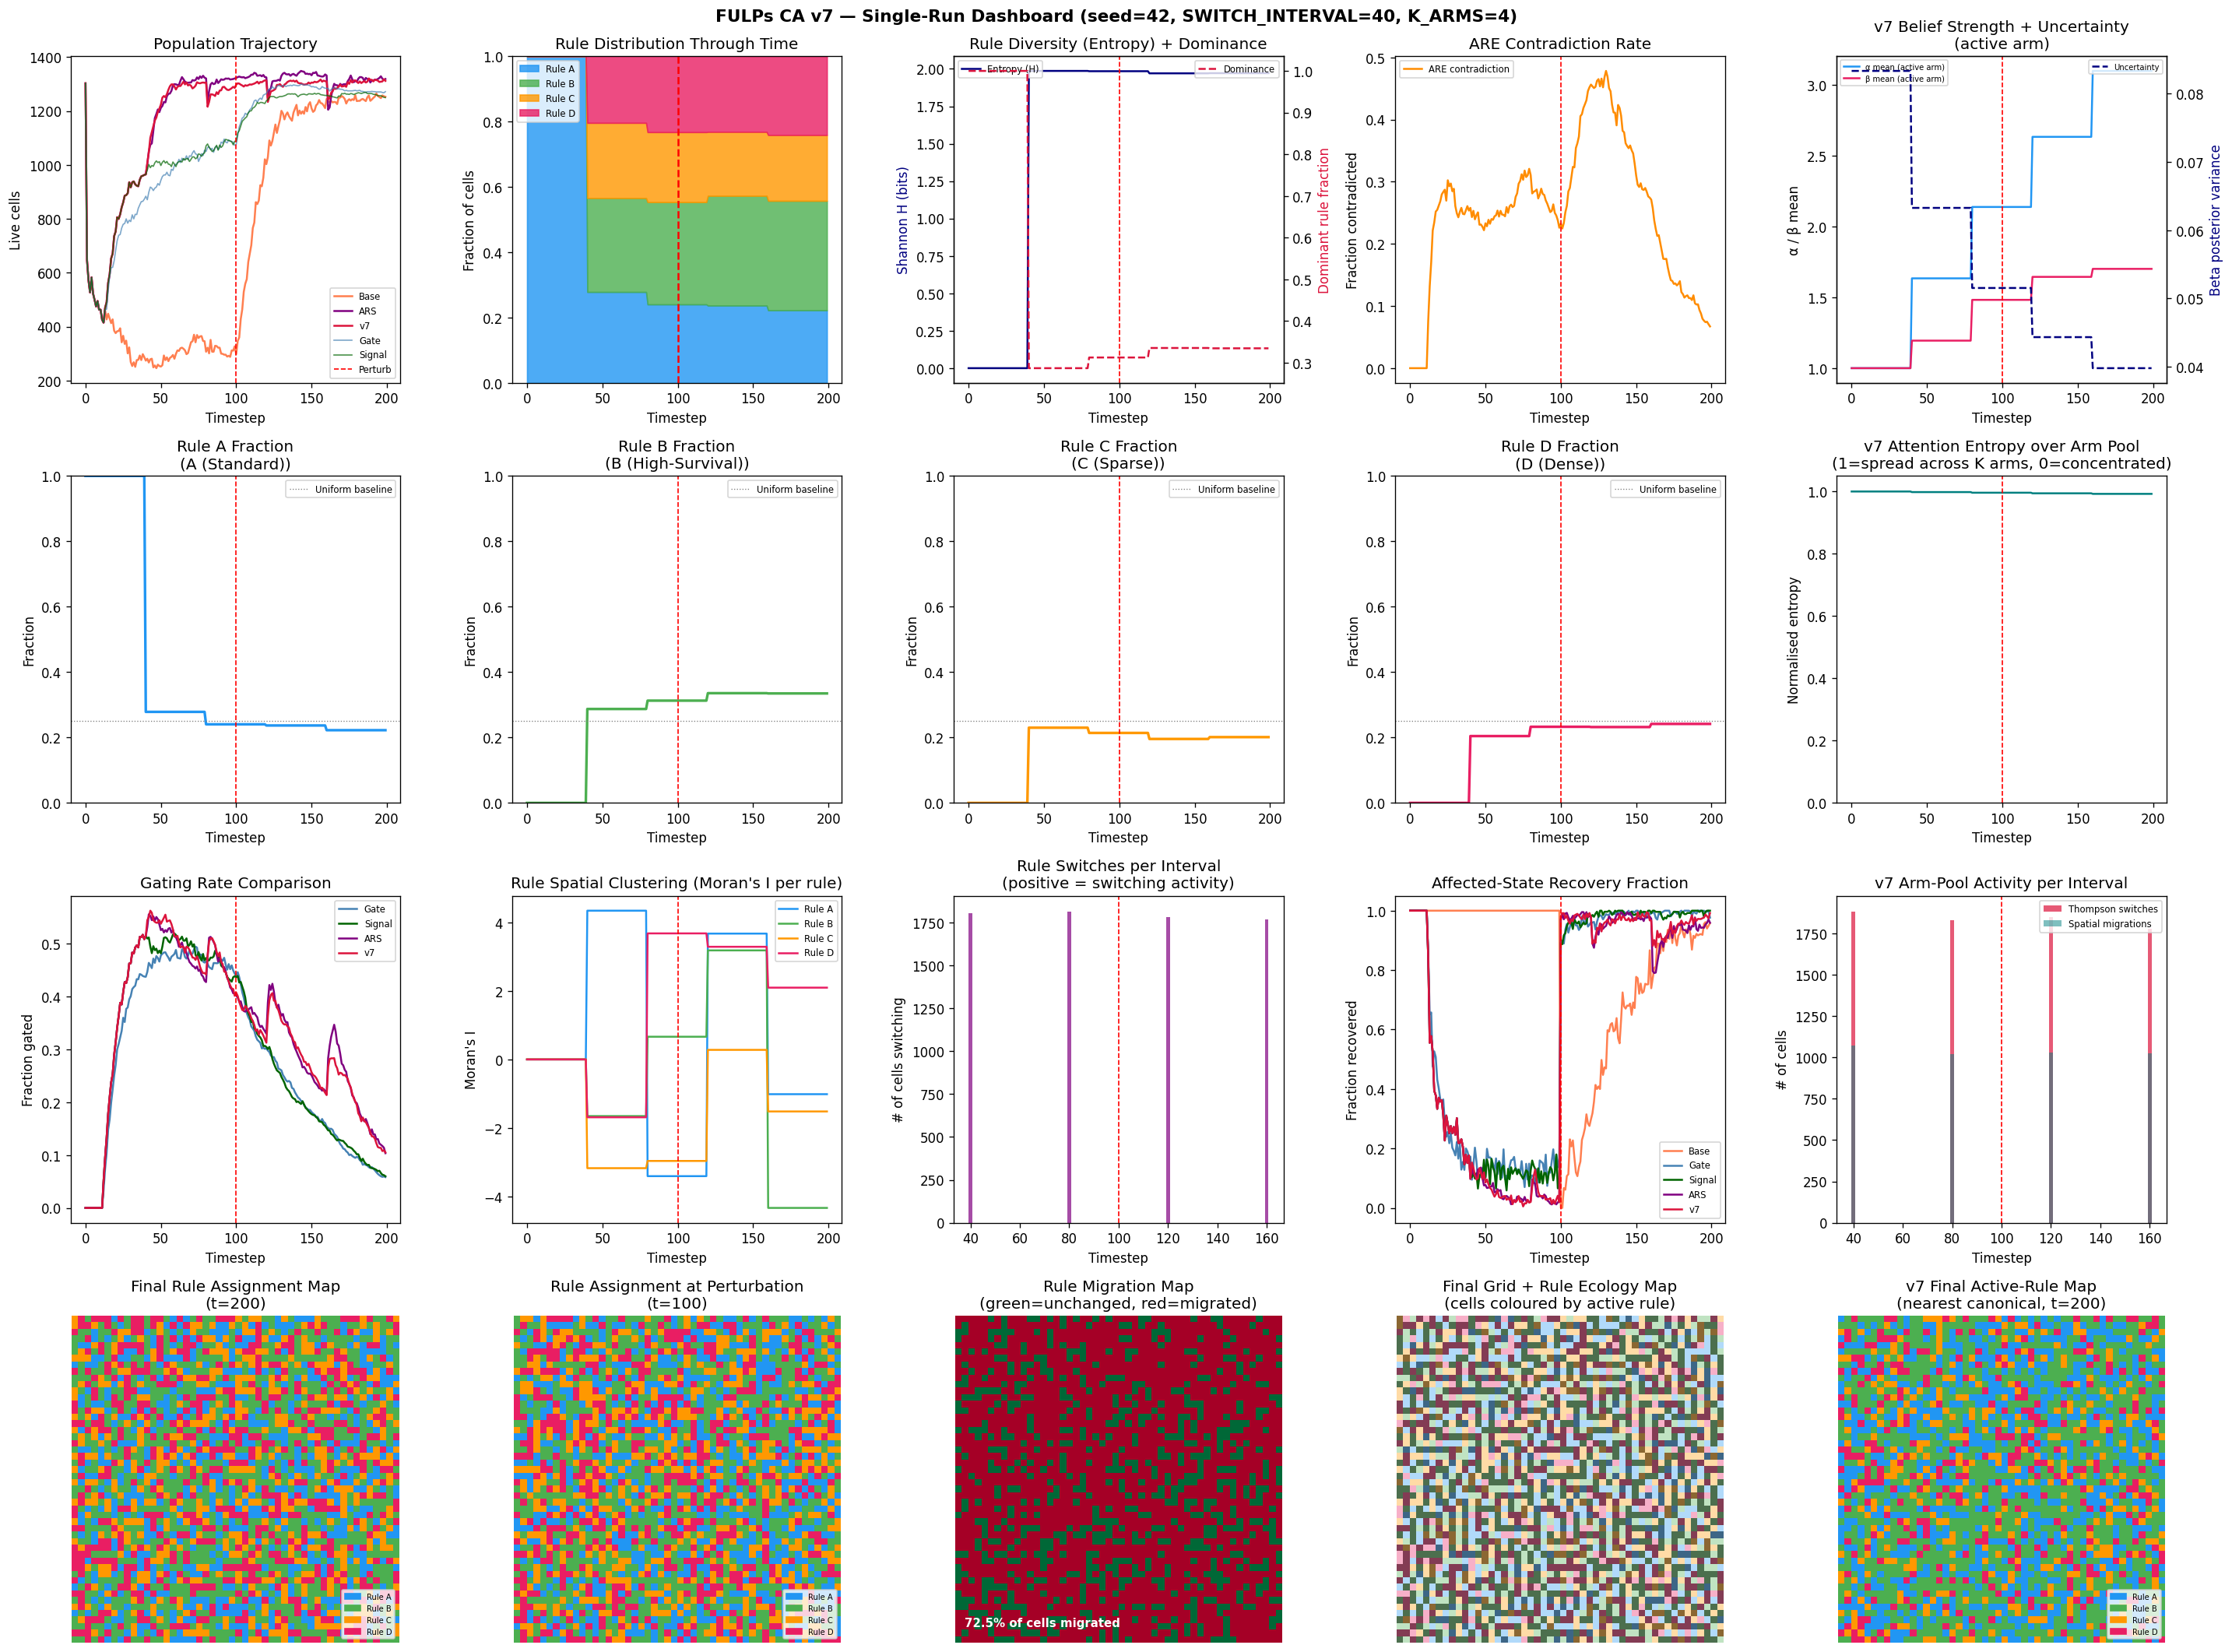

Saved: /content/fulps_ca_v7_single_run.png


In [191]:
# ── Cell 12: Single-Run Dashboard ─────────────────────────────────────────────
#
# Panel layout (4 rows × 4 columns = 16 panels):
#
# Row 1: Population trajectory | Rule distribution over time | Rule entropy + dominance | ARE contradiction rate
# Row 2: Rule A fraction | Rule B fraction | Rule C fraction | Rule D fraction (time series)
# Row 3: Gating rate comparison (gate/sig/ars) | Rule Moran's I | Rule switches per interval | Recovery fraction
# Row 4: Final rule heatmap | Rule heatmap at perturbation | Grid comparison (std vs ars) | Distress field snapshot

T = np.arange(N_TIMESTEPS)
rd  = fs42['rule_dist_h']    # (T, N_RULES)
re  = fs42['rule_entropy_h']
rdom = fs42['rule_dominance_h']
rsw  = fs42['rule_switch_h']
rmi  = fs42['rule_morans_h']  # (T, N_RULES)

# v7 NEW
v7rd  = fs42['v7_rule_dist_h']
v7re  = fs42['v7_entropy_h']
v7sw  = fs42['v7_switch_h']
v7mg  = fs42['v7_migration_h']
v7am  = fs42['v7_alpha_mean_h']
v7bm  = fs42['v7_beta_mean_h']
v7unc = fs42['v7_uncertainty_h']
v7att = fs42['v7_attention_entropy_h']

fig = plt.figure(figsize=(24, 18))
fig.suptitle(f'FULPs CA v7 — Single-Run Dashboard (seed=42, SWITCH_INTERVAL={SWITCH_INTERVAL}, K_ARMS={K_ARMS})',
             fontsize=13, fontweight='bold')

axes = fig.subplots(4, 5)

# ── Row 1 ──
ax = axes[0, 0]
ax.plot(T, hist42['pop_std'],  color='coral',     label='Base',   lw=1.5)
ax.plot(T, hist42['pop_ars'],  color='purple',    label='ARS',    lw=1.5)
ax.plot(T, hist42['pop_v7'],   color='crimson',   label='v7',     lw=1.5)
ax.plot(T, hist42['pop_gate'], color='steelblue', label='Gate',   lw=1, alpha=0.7)
ax.plot(T, hist42['pop_sig'],  color='darkgreen', label='Signal', lw=1, alpha=0.7)
ax.axvline(T_PERTURB, color='red', lw=1, linestyle='--', label='Perturb')
ax.set_title('Population Trajectory'); ax.set_xlabel('Timestep'); ax.set_ylabel('Live cells')
ax.legend(fontsize=7)

ax = axes[0, 1]
bottom = np.zeros(N_TIMESTEPS)
for r in range(N_RULES):
    ax.fill_between(T, bottom, bottom + rd[:, r], color=RULE_COLORS[r],
                    alpha=0.8, label=f'Rule {["A","B","C","D"][r]}')
    bottom += rd[:, r]
ax.axvline(T_PERTURB, color='red', lw=1.5, linestyle='--')
ax.set_title('Rule Distribution Through Time'); ax.set_xlabel('Timestep')
ax.set_ylabel('Fraction of cells'); ax.legend(fontsize=7, loc='upper left')
ax.set_ylim(0, 1)

ax = axes[0, 2]
ax2 = ax.twinx()
ax.plot(T, re,   color='navy',   lw=1.5, label='Entropy (H)')
ax2.plot(T, rdom, color='crimson', lw=1.5, linestyle='--', label='Dominance')
ax.axvline(T_PERTURB, color='red', lw=1, linestyle='--')
ax.set_title('Rule Diversity (Entropy) + Dominance')
ax.set_xlabel('Timestep'); ax.set_ylabel('Shannon H (bits)', color='navy')
ax2.set_ylabel('Dominant rule fraction', color='crimson')
ax.legend(loc='upper left', fontsize=7); ax2.legend(loc='upper right', fontsize=7)

ax = axes[0, 3]
ax.plot(T, hist42['contra_l'], color='darkorange', lw=1.5, label='ARE contradiction')
ax.axvline(T_PERTURB, color='red', lw=1, linestyle='--')
ax.set_title('ARE Contradiction Rate'); ax.set_xlabel('Timestep')
ax.set_ylabel('Fraction contradicted'); ax.legend(fontsize=7)

# ── Row 2: Per-rule fraction time series ──
for r in range(N_RULES):
    ax = axes[1, r]
    ax.plot(T, rd[:, r], color=RULE_COLORS[r], lw=2)
    ax.axvline(T_PERTURB, color='red', lw=1, linestyle='--')
    ax.axhline(1/N_RULES, color='gray', lw=0.8, linestyle=':', label='Uniform baseline')
    ax.set_title(f'Rule {["A","B","C","D"][r]} Fraction\n({RULE_NAMES[r]})')
    ax.set_xlabel('Timestep'); ax.set_ylabel('Fraction'); ax.legend(fontsize=7)
    ax.set_ylim(0, 1)

# ── Row 3 ──
ax = axes[2, 0]
ax.plot(T, hist42['gate_rate'], color='steelblue', lw=1.5, label='Gate')
ax.plot(T, hist42['sig_rate'],  color='darkgreen', lw=1.5, label='Signal')
ax.plot(T, hist42['ars_rate'],  color='purple',    lw=1.5, label='ARS')
ax.plot(T, hist42['v7_rate'],   color='crimson',   lw=1.5, label='v7')
ax.axvline(T_PERTURB, color='red', lw=1, linestyle='--')
ax.set_title('Gating Rate Comparison'); ax.set_xlabel('Timestep')
ax.set_ylabel('Fraction gated'); ax.legend(fontsize=7)

ax = axes[2, 1]
for r in range(N_RULES):
    ax.plot(T, rmi[:, r], color=RULE_COLORS[r], lw=1.5,
            label=f'Rule {["A","B","C","D"][r]}')
ax.axvline(T_PERTURB, color='red', lw=1, linestyle='--')
ax.set_title("Rule Spatial Clustering (Moran's I per rule)")
ax.set_xlabel('Timestep'); ax.set_ylabel("Moran's I"); ax.legend(fontsize=7)

ax = axes[2, 2]
switch_times = [t for t in T if rsw[t] > 0]
switch_vals  = [rsw[t] for t in switch_times]
ax.bar(switch_times, switch_vals, color='purple', alpha=0.7, width=1.5)
ax.axvline(T_PERTURB, color='red', lw=1, linestyle='--')
ax.set_title('Rule Switches per Interval\n(positive = switching activity)')
ax.set_xlabel('Timestep'); ax.set_ylabel('# of cells switching')

ax = axes[2, 3]
ax.plot(T, hist42['aff_base'], color='coral',     lw=1.5, label='Base')
ax.plot(T, hist42['aff_gate'], color='steelblue', lw=1.5, label='Gate')
ax.plot(T, hist42['aff_sig'],  color='darkgreen', lw=1.5, label='Signal')
ax.plot(T, hist42['aff_ars'],  color='purple',    lw=1.5, label='ARS')
ax.plot(T, hist42['aff_v7'],   color='crimson',   lw=1.5, label='v7')
ax.axvline(T_PERTURB, color='red', lw=1, linestyle='--')
ax.set_title('Affected-State Recovery Fraction')
ax.set_xlabel('Timestep'); ax.set_ylabel('Fraction recovered'); ax.legend(fontsize=7)

# ── Row 4: Spatial maps ──
ax = axes[3, 0]
rule_map_final = fs42['rule_map']
cmap_r = matplotlib.colors.ListedColormap(RULE_COLORS)
im = ax.imshow(rule_map_final, cmap=cmap_r, vmin=0, vmax=N_RULES-1, interpolation='nearest')
patches = [mpatches.Patch(color=RULE_COLORS[r], label=f'Rule {["A","B","C","D"][r]}')
           for r in range(N_RULES)]
ax.set_title(f'Final Rule Assignment Map\n(t={N_TIMESTEPS})')
ax.legend(handles=patches, fontsize=6, loc='lower right')
ax.axis('off')

ax = axes[3, 1]
rule_map_perturb = fs42['rule_map_at_perturb']
ax.imshow(rule_map_perturb, cmap=cmap_r, vmin=0, vmax=N_RULES-1, interpolation='nearest')
ax.set_title(f'Rule Assignment at Perturbation\n(t={T_PERTURB})')
ax.legend(handles=patches, fontsize=6, loc='lower right')
ax.axis('off')

ax = axes[3, 2]
# Difference map: cells that changed rule between perturbation and end
changed = (rule_map_final != rule_map_perturb).astype(np.float32)
ax.imshow(changed, cmap='RdYlGn_r', vmin=0, vmax=1, interpolation='nearest')
ax.set_title(f'Rule Migration Map\n(green=unchanged, red=migrated)')
ax.axis('off')
ax.text(1, 47, f'{changed.mean()*100:.1f}% of cells migrated', color='white',
        fontsize=9, fontweight='bold')

ax = axes[3, 3]
# Grid comparison: ARS grid overlaid with rule regions
ax.imshow(fs42['grid_ars'], cmap='Greys', interpolation='nearest', alpha=0.7)
# Overlay rule map with transparency
rgba_rule = np.zeros((GRID_H, GRID_W, 4))
for r in range(N_RULES):
    mask = (rule_map_final == r)
    c = matplotlib.colors.to_rgba(RULE_COLORS[r])
    rgba_rule[mask] = [c[0], c[1], c[2], 0.35]
ax.imshow(rgba_rule, interpolation='nearest')
ax.set_title('Final Grid + Rule Ecology Map\n(cells coloured by active rule)')
ax.axis('off')

# ── Column 5 (NEW): v7 Arm-Pool Thompson Sampling ─────────────────────────────
ax = axes[0, 4]
ax2 = ax.twinx()
ax.plot(T, v7am, color='#2196F3', lw=1.5, label='α mean (active arm)')
ax.plot(T, v7bm, color='#E91E63', lw=1.5, label='β mean (active arm)')
ax2.plot(T, v7unc, color='navy', lw=1.5, linestyle='--', label='Uncertainty')
ax.axvline(T_PERTURB, color='red', lw=1, linestyle='--')
ax.set_title('v7 Belief Strength + Uncertainty\n(active arm)')
ax.set_xlabel('Timestep'); ax.set_ylabel('α / β mean')
ax2.set_ylabel('Beta posterior variance', color='navy')
ax.legend(loc='upper left', fontsize=6); ax2.legend(loc='upper right', fontsize=6)

ax = axes[1, 4]
ax.plot(T, v7att, color='teal', lw=1.5)
ax.axvline(T_PERTURB, color='red', lw=1, linestyle='--')
ax.set_title('v7 Attention Entropy over Arm Pool\n(1=spread across K arms, 0=concentrated)')
ax.set_xlabel('Timestep'); ax.set_ylabel('Normalised entropy'); ax.set_ylim(0, 1.05)

ax = axes[2, 4]
switch_times = [t for t in T if v7sw[t] > 0]
switch_vals  = [v7sw[t] for t in switch_times]
mig_times    = [t for t in T if v7mg[t] > 0]
mig_vals     = [v7mg[t] for t in mig_times]
ax.bar(switch_times, switch_vals, color='crimson', alpha=0.7, width=1.5, label='Thompson switches')
ax.bar(mig_times, mig_vals, color='teal', alpha=0.5, width=1.5, label='Spatial migrations')
ax.axvline(T_PERTURB, color='red', lw=1, linestyle='--')
ax.set_title('v7 Arm-Pool Activity per Interval')
ax.set_xlabel('Timestep'); ax.set_ylabel('# of cells'); ax.legend(fontsize=7)

ax = axes[3, 4]
v7_rule_map_final = fs42['v7_rule_map']
ax.imshow(v7_rule_map_final, cmap=cmap_r, vmin=0, vmax=N_RULES-1, interpolation='nearest')
ax.set_title(f'v7 Final Active-Rule Map\n(nearest canonical, t={N_TIMESTEPS})')
ax.legend(handles=patches, fontsize=6, loc='lower right')
ax.axis('off')

plt.tight_layout()
sp = os.path.join(OUT_DIR, 'fulps_ca_v7_single_run.png')
plt.savefig(sp, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {sp}')

In [192]:
# ── Cell 13: 50-Run Multi-Run Experiment ─────────────────────────────────────
from collections import defaultdict

print(f'Running {N_RUNS} seeds ({BASE_SEED}–{BASE_SEED+N_RUNS-1}) ...')
print('Estimated time: ~10–15 min on Colab CPU.')

all_res = defaultdict(list)

for run_i in range(N_RUNS):
    seed = BASE_SEED + run_i
    _, results, _ = run_simulation(
        seed=seed,
        void_model=VOID_MODEL,
        idf=(IDF_MEANS, IDF_STDS, IDF_L),
        is_single_run=False,
        verbose=False
    )
    for k, v in results.items():
        all_res[k].append(v)

    if (run_i + 1) % BATCH_SIZE == 0:
        print(f'  [{run_i+1}/{N_RUNS}] ars_rec={np.nanmean(all_res["ars_recovery_t"]):.1f}  '
              f'v7_rec={np.nanmean(all_res["v7_recovery_t"]):.1f}  '
              f'v7_entropy_post={np.nanmean(all_res["v7_entropy_post"]):.3f}  '
              f'v7_migration={np.nanmean(all_res["v7_rule_migration_magnitude"]):.3f}')

# Convert to arrays
for k in all_res:
    all_res[k] = np.array(all_res[k], dtype=np.float64)

# Save results CSV
fp = os.path.join(OUT_DIR, 'results_50runs_ca_v7.csv')
pd.DataFrame(all_res).to_csv(fp, index=False)
print(f'\nDone. Results saved: {fp}')

# ── Print key statistics ──────────────────────────────────────────────────────
def sa(k): return all_res[k][~np.isnan(all_res[k])]
def sm(k): return float(np.nanmean(all_res[k]))
def ss2(k): return float(np.nanstd(all_res[k]))

print('\n── 50-Run Summary ─────────────────────────────────────────')
print(f'  Recovery timestep:  Base={sm("base_recovery_t"):.1f}  Gate={sm("gate_recovery_t"):.1f}  '
      f'Signal={sm("sig_recovery_t"):.1f}  ARS={sm("ars_recovery_t"):.1f}  v7={sm("v7_recovery_t"):.1f}')
print(f'  Post-perturbation CV:  Base={sm("cv_base_post"):.4f}  Gate={sm("cv_gate_post"):.4f}  '
      f'Signal={sm("cv_sig_post"):.4f}  ARS={sm("cv_ars_post"):.4f}  v7={sm("cv_v7_post"):.4f}')
print(f'  Rule entropy pre→post:    ARS {sm("rule_entropy_pre"):.3f} → {sm("rule_entropy_post"):.3f}   '
      f'v7 {sm("v7_entropy_pre"):.3f} → {sm("v7_entropy_post"):.3f}')
print(f'  Rule dominance pre→post:  ARS {sm("rule_dominance_pre"):.3f} → {sm("rule_dominance_post"):.3f}   '
      f'v7 {sm("v7_dominance_pre"):.3f} → {sm("v7_dominance_post"):.3f}')
print(f'  Rule migration magnitude: ARS={sm("rule_migration_magnitude"):.4f}  v7={sm("v7_rule_migration_magnitude"):.4f}')
print(f'  Regional specialisation:  ARS={sm("regional_specialisation"):.4f}  v7={sm("v7_regional_specialisation"):.4f}')
print(f'  Rule recovery advantage (signal - ARS): {sm("rule_recovery_advantage"):.2f} timesteps')
print(f'  Total switches (mean per run):    ARS={sm("total_switches"):.1f}  v7={sm("v7_total_switches"):.1f}')
print(f'  Total spatial migrations (mean per run, v7 only): {sm("v7_total_migrations"):.1f}')
print(f'  v7 belief:  α mean pre→post={sm("v7_alpha_mean_pre"):.2f}→{sm("v7_alpha_mean_post"):.2f}   '
      f'uncertainty pre→post={sm("v7_uncertainty_pre"):.4f}→{sm("v7_uncertainty_post"):.4f}')
print(f'  v7 attention entropy pre→post: {sm("v7_attention_entropy_pre"):.3f} → {sm("v7_attention_entropy_post"):.3f}')
print(f'  Computational cost (single-run only, seed=42): '
      f'v7/ARS wall-time ratio={res42["v7_runtime_per_ars"]:.2f}x  '
      f'(v7 share of per-step compute={res42["v7_runtime_frac"]*100:.1f}%)')

Running 50 seeds (42–91) ...
Estimated time: ~10–15 min on Colab CPU.
  [5/50] ars_rec=139.8  v7_rec=136.2  v7_entropy_post=1.820  v7_migration=0.315
  [10/50] ars_rec=140.0  v7_rec=136.0  v7_entropy_post=1.819  v7_migration=0.308
  [15/50] ars_rec=139.8  v7_rec=135.9  v7_entropy_post=1.819  v7_migration=0.313
  [20/50] ars_rec=139.3  v7_rec=135.9  v7_entropy_post=1.820  v7_migration=0.308
  [25/50] ars_rec=139.4  v7_rec=135.7  v7_entropy_post=1.817  v7_migration=0.313
  [30/50] ars_rec=139.3  v7_rec=135.5  v7_entropy_post=1.817  v7_migration=0.312
  [35/50] ars_rec=139.3  v7_rec=135.4  v7_entropy_post=1.818  v7_migration=0.310
  [40/50] ars_rec=139.2  v7_rec=135.3  v7_entropy_post=1.817  v7_migration=0.311
  [45/50] ars_rec=139.2  v7_rec=135.6  v7_entropy_post=1.818  v7_migration=0.309
  [50/50] ars_rec=138.9  v7_rec=135.5  v7_entropy_post=1.819  v7_migration=0.309

Done. Results saved: /content/results_50runs_ca_v7.csv

── 50-Run Summary ─────────────────────────────────────────
  Re

In [193]:
# ── Cell 14: Statistical Analysis ─────────────────────────────────────────────
#
# All tests are paired (same seeds across conditions).
# Effect sizes reported as Cohen's d.

def cohens_d(a, b=None, paired=True):
    a = np.array(a, dtype=np.float64); a = a[~np.isnan(a)]
    if b is None: return float(a.mean() / a.std()) if a.std() > 1e-9 else np.nan
    b = np.array(b, dtype=np.float64); b = b[~np.isnan(b)]
    diff = a - b if paired else a
    denom = diff.std() if paired else np.sqrt((a.var()+b.var())/2)
    return float(diff.mean() / denom) if denom > 1e-9 else np.nan

def paired_t(a, b, label):
    a = np.array(a, dtype=np.float64); b = np.array(b, dtype=np.float64)
    mask = ~(np.isnan(a)|np.isnan(b))
    a, b = a[mask], b[mask]
    if len(a) < 3: print(f'  {label}: insufficient data'); return
    t, p = stats.ttest_rel(a, b)
    d = cohens_d(a, b, paired=True)
    sup = (a > b).sum()
    print(f'  {label}:  t({len(a)-1})={t:.3f}  p={p:.4f}  d={d:.3f}  '
          f'({sup}/{len(a)} runs favourable)')

def one_sample_t(vals, label, null=0.0):
    v = np.array(vals, dtype=np.float64); v = v[~np.isnan(v)]
    if len(v) < 3: return
    t, p = stats.ttest_1samp(v, null)
    print(f'  {label}:  mean={v.mean():.4f}  t({len(v)-1})={t:.3f}  p={p:.4f}')

print('='*65)
print('STATISTICAL ANALYSIS — FULPs CA v7')
print('='*65)

print('\nRQ1: Do non-random rule preferences emerge?')
print('  H0: rule entropy equals maximum (log2(4)=2.0 bits, uniform distribution)')
one_sample_t(all_res['rule_entropy_post'], 'Rule entropy post vs. max (2.0 bits)', null=2.0)
one_sample_t(all_res['rule_dominance_post'], 'Dominance post vs. uniform (0.25)', null=0.25)

print('\nRQ2: Do rule preferences migrate after perturbation?')
paired_t(all_res['rule_entropy_post'], all_res['rule_entropy_pre'],
         'Entropy post > pre (increased diversity post-perturb?)')
one_sample_t(all_res['rule_migration_magnitude'],
             'Migration magnitude > 0 (non-zero rule shift post-perturb)')
paired_t(all_res['rule_dominance_post'], all_res['rule_dominance_pre'],
         'Dominance post vs pre (did dominant rule change fraction?)')

print('\nRQ3: Does ARS improve recovery vs base?')
paired_t(all_res['ars_recovery_t'], all_res['base_recovery_t'],
         'ARS recovery_t < base recovery_t (lower=faster)')

print('\nRQ4: Does ARS improve resilience vs signal (previous best)?')
paired_t(all_res['ars_recovery_t'], all_res['sig_recovery_t'],
         'ARS recovery_t vs signal recovery_t')
paired_t(all_res['cv_ars_post'], all_res['cv_sig_post'],
         'ARS CV post vs signal CV post (lower=more stable)')

print('\nRQ5: Do neighbouring cells converge toward similar rule choices?')
print('  (Moran\'s I per rule vs 0 — positive = clustered)')
for r, rn in enumerate(['A','B','C','D']):
    one_sample_t(all_res[f'mi_rule{rn}_post'],
                 f'  Rule {rn} Moran\'s I post vs 0')

print('\nRQ6: Do distinct rule regions emerge?')
one_sample_t(all_res['regional_specialisation'],
             'Regional specialisation > 0 (spatial quad heterogeneity)')
print()
print('Additional: Is switching non-random (i.e. is switch rate post > pre)?')
paired_t(all_res['switch_rate_post'],
         all_res['rule_entropy_pre'] * 0,  # zero array proxy — use one_sample_t
         'NOTE: see one-sample test below')
one_sample_t(all_res['switch_rate_post'], 'Switch rate post-perturbation > 0')

print('\nContradiction spike (inherited from v5):')
one_sample_t(all_res['contra_spike'], 'Contradiction spike at perturbation vs 0')

print('\n' + '='*65)
print('v7 NEW: Arm-Pool Thompson Sampling questions')
print('='*65)

print('\nSQ2: Do cells develop persistent, sharpening rule beliefs?')
print('  (alpha of the active arm grows above the uniform prior of 1.0,')
print('   and uncertainty [Beta posterior variance] shrinks post-perturbation)')
one_sample_t(all_res['v7_alpha_mean_post'], 'v7 alpha mean post vs prior (1.0)', null=BETA_ALPHA_INIT)
paired_t(all_res['v7_uncertainty_post'], all_res['v7_uncertainty_pre'],
         'v7 uncertainty post vs pre (should decrease as beliefs sharpen)')

print('\nSQ5: Does Bayesian uncertainty naturally balance exploration/exploitation?')
print('  (attention entropy over the arm pool should also fall as beliefs sharpen)')
paired_t(all_res['v7_attention_entropy_post'], all_res['v7_attention_entropy_pre'],
         'v7 attention entropy post vs pre (should decrease)')

print('\nSQ6: Do emergent attractors appear in the v7 rule/arm landscape?')
one_sample_t(all_res['v7_entropy_post'], 'v7 entropy post vs max (2.0 bits)', null=2.0)
one_sample_t(all_res['v7_rule_migration_magnitude'],
             'v7 migration magnitude > 0 (non-zero rule shift post-perturb)')
one_sample_t(all_res['v7_regional_specialisation'],
             'v7 regional specialisation > 0 (spatial quad heterogeneity)')
one_sample_t(all_res['v7_total_migrations'],
             'v7 spatial migrations > 0 (arm pool propagates between neighbours)')

print('\nSQ7: Does v7 survive/recover better than v6 ARS?')
paired_t(all_res['v7_recovery_t'], all_res['ars_recovery_t'],
         'v7 recovery_t vs ARS recovery_t (lower=faster)')
paired_t(all_res['cv_v7_post'], all_res['cv_ars_post'],
         'v7 CV post vs ARS CV post (lower=more stable)')

STATISTICAL ANALYSIS — FULPs CA v7

RQ1: Do non-random rule preferences emerge?
  H0: rule entropy equals maximum (log2(4)=2.0 bits, uniform distribution)
  Rule entropy post vs. max (2.0 bits):  mean=1.9754  t(49)=-37.712  p=0.0000
  Dominance post vs. uniform (0.25):  mean=0.3293  t(49)=72.152  p=0.0000

RQ2: Do rule preferences migrate after perturbation?
  Entropy post > pre (increased diversity post-perturb?):  t(49)=-8.222  p=0.0000  d=-1.175  (8/50 runs favourable)
  Migration magnitude > 0 (non-zero rule shift post-perturb):  mean=0.0904  t(49)=29.264  p=0.0000
  Dominance post vs pre (did dominant rule change fraction?):  t(49)=17.424  p=0.0000  d=2.489  (50/50 runs favourable)

RQ3: Does ARS improve recovery vs base?
  ARS recovery_t < base recovery_t (lower=faster):  t(49)=-41.802  p=0.0000  d=-5.972  (0/50 runs favourable)

RQ4: Does ARS improve resilience vs signal (previous best)?
  ARS recovery_t vs signal recovery_t:  t(49)=28.485  p=0.0000  d=4.069  (50/50 runs favoura

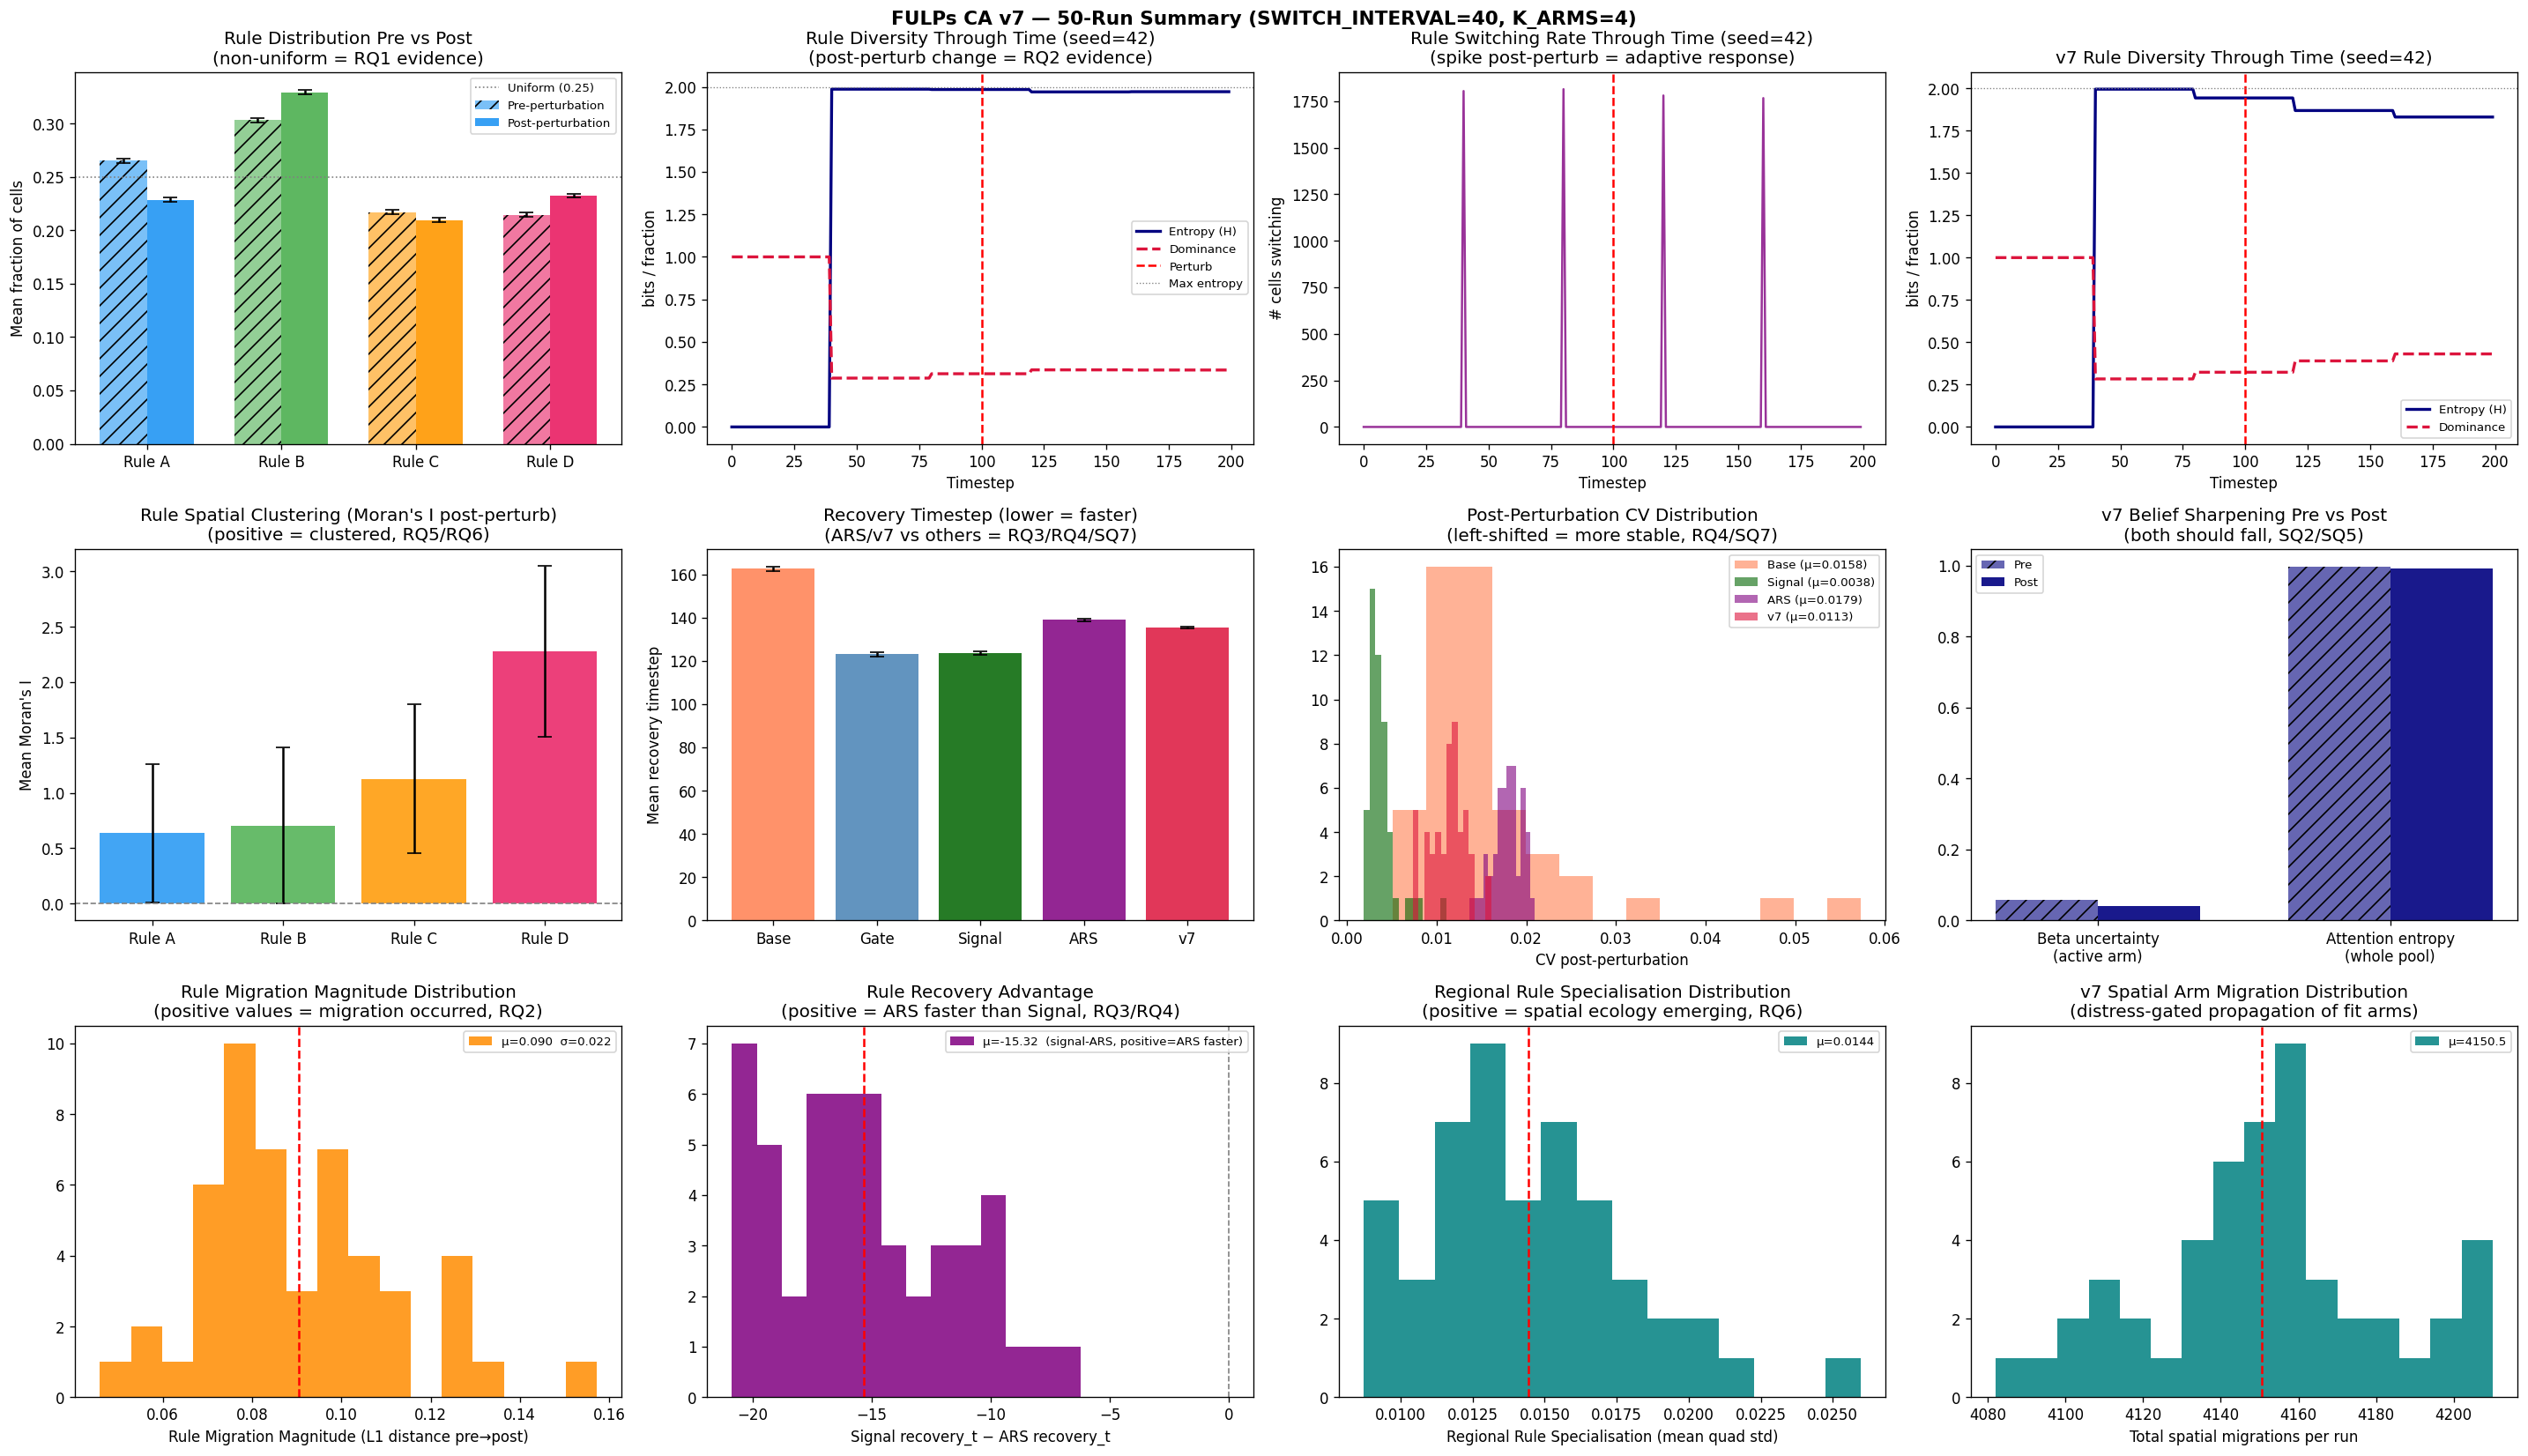

Saved: /content/fulps_ca_v7_multirun.png  |  Full CSV: /content/results_50runs_ca_v7.csv


In [194]:
# ── Cell 15: Multi-Run Visualisation (Publication Quality) ────────────────────
#
# 9 panels covering all primary ARS metrics + v5 inherited metrics:
#
# Row 1: Rule distribution pre/post | Rule entropy through time (mean±CI) | Rule dominance
# Row 2: Rule Moran's I by rule (post) | Recovery timestep (5 conditions) | CV post (3 conds)
# Row 3: Rule migration magnitude dist | Rule switching rate (post dist) | Recovery advantage scatter

fig, axes = plt.subplots(3, 4, figsize=(24, 14))
fig.suptitle(f'FULPs CA v7 — 50-Run Summary (SWITCH_INTERVAL={SWITCH_INTERVAL}, K_ARMS={K_ARMS})',
             fontsize=13, fontweight='bold')

def sc(k): return 1.96*np.nanstd(all_res[k])/np.sqrt(N_RUNS)

# ── Panel (0,0): Rule distribution pre vs post ────────────────────────────────
ax = axes[0, 0]
rule_labels = ['A', 'B', 'C', 'D']
x = np.arange(N_RULES); w = 0.35
pre_fracs  = [sm(f'rule_frac_{r}_pre')  for r in rule_labels]
post_fracs = [sm(f'rule_frac_{r}_post') for r in rule_labels]
pre_ci     = [sc(f'rule_frac_{r}_pre')  for r in rule_labels]
post_ci    = [sc(f'rule_frac_{r}_post') for r in rule_labels]
ax.bar(x - w/2, pre_fracs,  w, yerr=pre_ci,  capsize=5, color=[RULE_COLORS[r] for r in range(N_RULES)],
       alpha=0.6, label='Pre-perturbation', hatch='//')
ax.bar(x + w/2, post_fracs, w, yerr=post_ci, capsize=5, color=[RULE_COLORS[r] for r in range(N_RULES)],
       alpha=0.9, label='Post-perturbation')
ax.axhline(1/N_RULES, color='gray', lw=1, linestyle=':', label='Uniform (0.25)')
ax.set_xticks(x); ax.set_xticklabels([f'Rule {r}' for r in rule_labels])
ax.set_title('Rule Distribution Pre vs Post\n(non-uniform = RQ1 evidence)')
ax.set_ylabel('Mean fraction of cells'); ax.legend(fontsize=8)

# ── Panel (0,1): Rule entropy ─────────────────────────────────────────────────
ax = axes[0, 1]
# Re-run single seed to get time-series for illustration
_, _, fs_viz = run_simulation(42, VOID_MODEL, (IDF_MEANS, IDF_STDS, IDF_L),
                               is_single_run=True, verbose=False)
ax.plot(fs_viz['rule_entropy_h'],   color='navy',   lw=2, label='Entropy (H)')
ax.plot(fs_viz['rule_dominance_h'], color='crimson', lw=2, linestyle='--', label='Dominance')
ax.axvline(T_PERTURB, color='red', lw=1.5, linestyle='--', label='Perturb')
ax.axhline(np.log2(N_RULES), color='gray', lw=0.8, linestyle=':', label='Max entropy')
ax.set_title('Rule Diversity Through Time (seed=42)\n(post-perturb change = RQ2 evidence)')
ax.set_xlabel('Timestep'); ax.set_ylabel('bits / fraction')
ax.legend(fontsize=8)

# ── Panel (0,2): Rule switching rate ──────────────────────────────────────────
ax = axes[0, 2]
ax.plot(fs_viz['rule_switch_h'], color='purple', lw=1.5, alpha=0.8)
ax.axvline(T_PERTURB, color='red', lw=1.5, linestyle='--')
ax.set_title('Rule Switching Rate Through Time (seed=42)\n(spike post-perturb = adaptive response)')
ax.set_xlabel('Timestep'); ax.set_ylabel('# cells switching')

# ── Panel (1,0): Rule Moran's I post-perturbation ─────────────────────────────
ax = axes[1, 0]
mi_vals  = [sm(f'mi_rule{r}_post') for r in rule_labels]
mi_cis   = [sc(f'mi_rule{r}_post') for r in rule_labels]
ax.bar(range(N_RULES), mi_vals, yerr=mi_cis, capsize=5,
       color=RULE_COLORS, alpha=0.85)
ax.axhline(0, color='gray', lw=1, linestyle='--')
ax.set_xticks(range(N_RULES))
ax.set_xticklabels([f'Rule {r}' for r in rule_labels])
ax.set_title("Rule Spatial Clustering (Moran's I post-perturb)\n(positive = clustered, RQ5/RQ6)")
ax.set_ylabel("Mean Moran's I")

# ── Panel (1,1): Recovery timestep comparison ─────────────────────────────────
ax = axes[1, 1]
conds = ['Base', 'Gate', 'Signal', 'ARS', 'v7']
rt_keys = ['base_recovery_t', 'gate_recovery_t', 'sig_recovery_t', 'ars_recovery_t', 'v7_recovery_t']
colors  = ['coral', 'steelblue', 'darkgreen', 'purple', 'crimson']
rt_m  = [sm(k) for k in rt_keys]
rt_ci = [sc(k) for k in rt_keys]
ax.bar(range(5), rt_m, yerr=rt_ci, capsize=5, color=colors, alpha=0.85)
ax.set_xticks(range(5)); ax.set_xticklabels(conds)
ax.set_title('Recovery Timestep (lower = faster)\n(ARS/v7 vs others = RQ3/RQ4/SQ7)')
ax.set_ylabel('Mean recovery timestep')

# ── Panel (1,2): Post-CV distribution ─────────────────────────────────────────
ax = axes[1, 2]
for k, col, lbl in [('cv_base_post','coral','Base'), ('cv_sig_post','darkgreen','Signal'),
                     ('cv_ars_post','purple','ARS'), ('cv_v7_post','crimson','v7')]:
    v = sa(k)
    if len(v) > 0:
        ax.hist(v, bins=14, alpha=0.6, color=col, label=f'{lbl} (μ={v.mean():.4f})')
ax.set_xlabel('CV post-perturbation')
ax.set_title('Post-Perturbation CV Distribution\n(left-shifted = more stable, RQ4/SQ7)')
ax.legend(fontsize=8)

# ── Panel (2,0): Rule migration magnitude distribution ───────────────────────
ax = axes[2, 0]
mig = sa('rule_migration_magnitude')
ax.hist(mig, bins=16, color='darkorange', alpha=0.85,
        label=f'μ={mig.mean():.3f}  σ={mig.std():.3f}')
ax.axvline(mig.mean(), color='red', lw=1.5, linestyle='--')
ax.set_xlabel('Rule Migration Magnitude (L1 distance pre→post)')
ax.set_title('Rule Migration Magnitude Distribution\n(positive values = migration occurred, RQ2)')
ax.legend(fontsize=8)

# ── Panel (2,1): Rule recovery advantage ─────────────────────────────────────
ax = axes[2, 1]
adv = sa('rule_recovery_advantage')
ax.hist(adv, bins=14, color='purple', alpha=0.85,
        label=f'μ={adv.mean():.2f}  (signal-ARS, positive=ARS faster)')
ax.axvline(0, color='gray', lw=1, linestyle='--')
ax.axvline(adv.mean(), color='red', lw=1.5, linestyle='--')
ax.set_xlabel('Signal recovery_t − ARS recovery_t')
ax.set_title('Rule Recovery Advantage\n(positive = ARS faster than Signal, RQ3/RQ4)')
ax.legend(fontsize=8)

# ── Panel (2,2): Regional specialisation ─────────────────────────────────────
ax = axes[2, 2]
rs = sa('regional_specialisation')
ax.hist(rs, bins=14, color='teal', alpha=0.85,
        label=f'μ={rs.mean():.4f}')
ax.axvline(rs.mean(), color='red', lw=1.5, linestyle='--')
ax.set_xlabel('Regional Rule Specialisation (mean quad std)')
ax.set_title('Regional Rule Specialisation Distribution\n(positive = spatial ecology emerging, RQ6)')
ax.legend(fontsize=8)

# ── Column 4 (NEW): v7 Arm-Pool Thompson Sampling ─────────────────────────────
ax = axes[0, 3]
ax.plot(fs_viz['v7_entropy_h'], color='navy', lw=2, label='Entropy (H)')
ax.plot(fs_viz['v7_dominance_h'], color='crimson', lw=2, linestyle='--', label='Dominance')
ax.axvline(T_PERTURB, color='red', lw=1.5, linestyle='--')
ax.axhline(np.log2(N_RULES), color='gray', lw=0.8, linestyle=':')
ax.set_title('v7 Rule Diversity Through Time (seed=42)')
ax.set_xlabel('Timestep'); ax.set_ylabel('bits / fraction'); ax.legend(fontsize=8)

ax = axes[1, 3]
x = np.array([0, 1]); w = 0.35
unc_pre, unc_post = sm('v7_uncertainty_pre'), sm('v7_uncertainty_post')
att_pre, att_post = sm('v7_attention_entropy_pre'), sm('v7_attention_entropy_post')
ax.bar(x - w/2, [unc_pre, att_pre],  w, color='navy',   alpha=0.6, label='Pre', hatch='//')
ax.bar(x + w/2, [unc_post, att_post], w, color='navy',  alpha=0.9, label='Post')
ax.set_xticks(x); ax.set_xticklabels(['Beta uncertainty\n(active arm)', 'Attention entropy\n(whole pool)'])
ax.set_title('v7 Belief Sharpening Pre vs Post\n(both should fall, SQ2/SQ5)')
ax.legend(fontsize=8)

ax = axes[2, 3]
mig_v7 = sa('v7_total_migrations')
ax.hist(mig_v7, bins=16, color='teal', alpha=0.85, label=f'μ={mig_v7.mean():.1f}')
ax.axvline(mig_v7.mean(), color='red', lw=1.5, linestyle='--')
ax.set_xlabel('Total spatial migrations per run')
ax.set_title('v7 Spatial Arm Migration Distribution\n(distress-gated propagation of fit arms)')
ax.legend(fontsize=8)

plt.tight_layout()
mp = os.path.join(OUT_DIR, 'fulps_ca_v7_multirun.png')
plt.savefig(mp, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {mp}  |  Full CSV: {fp}')

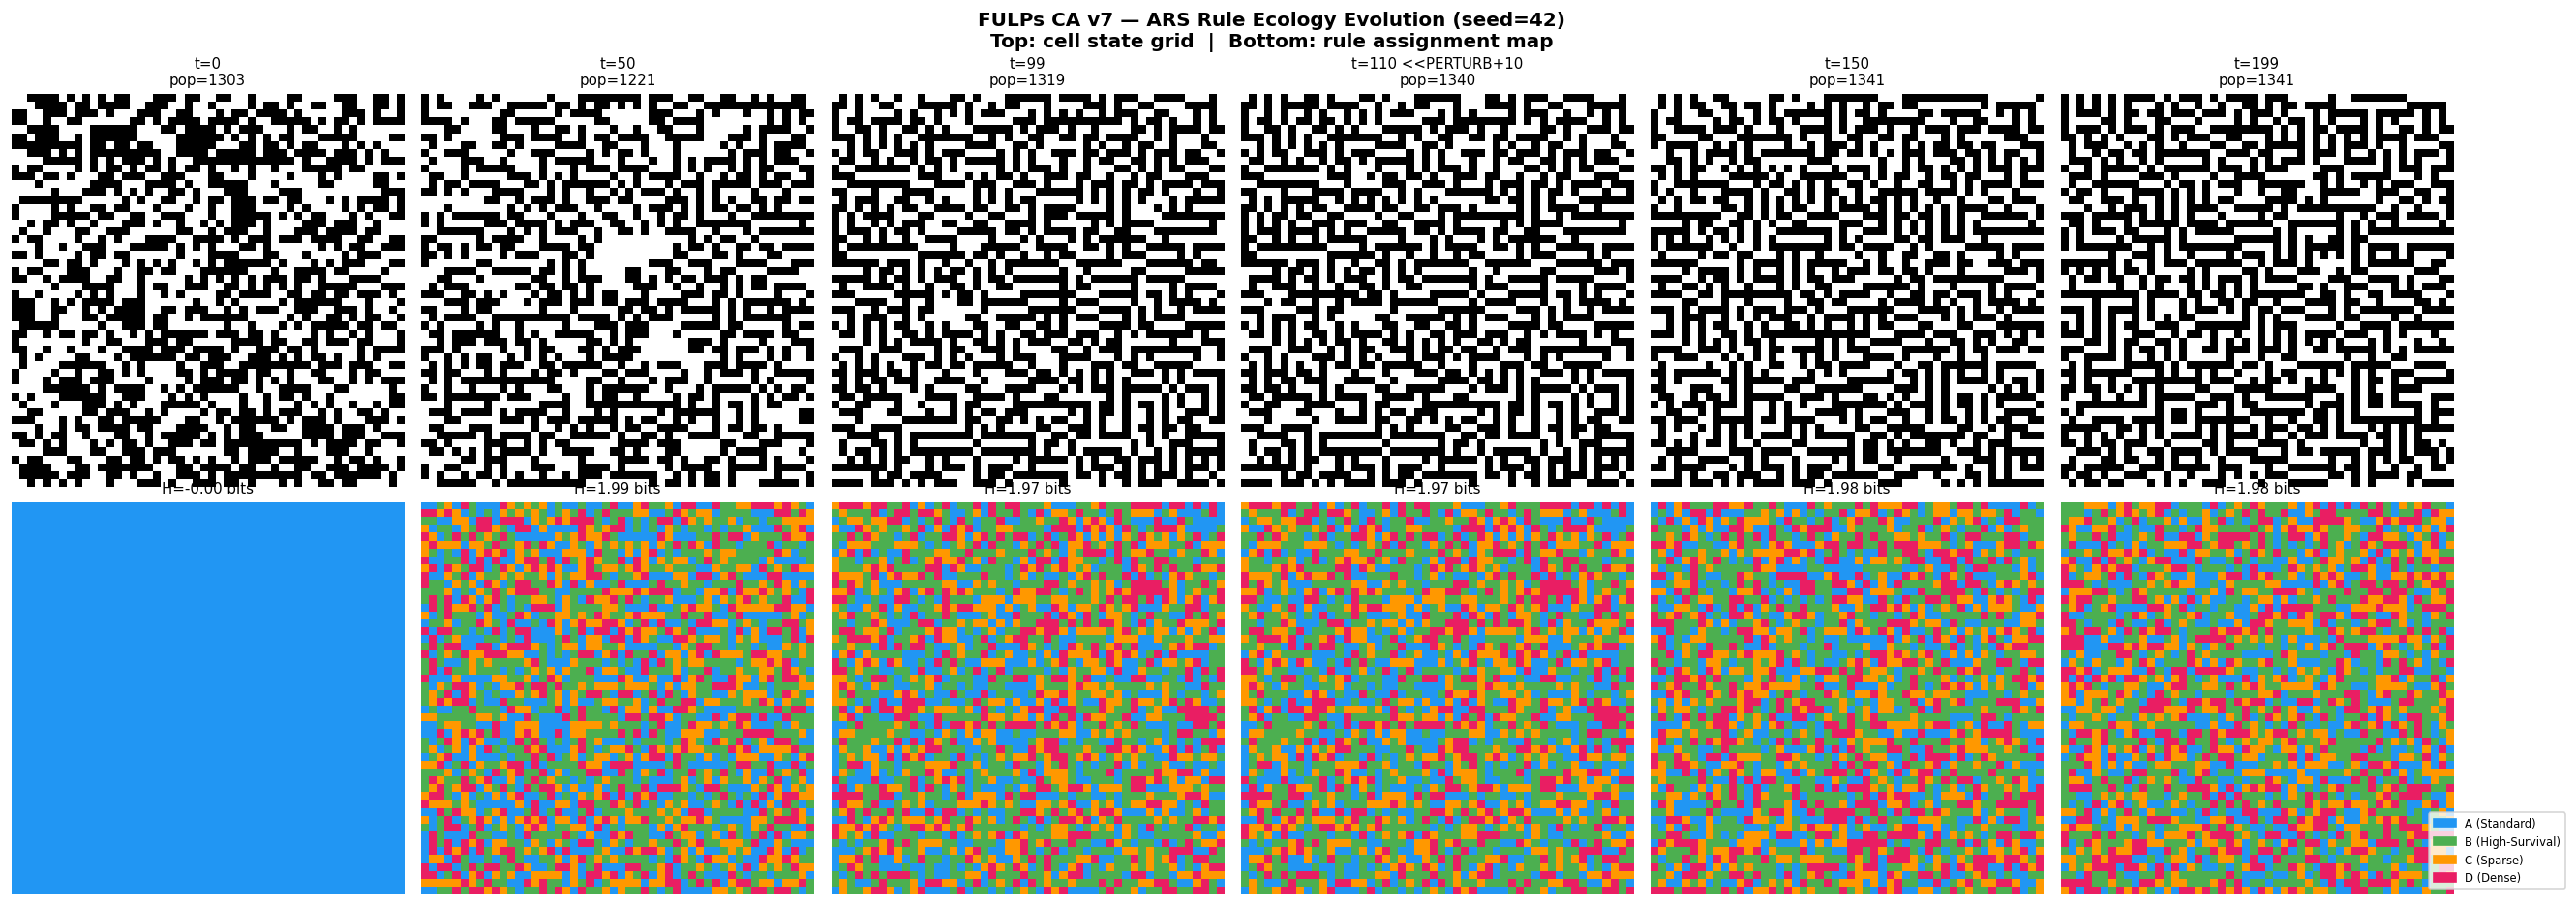

Saved: /content/fulps_ca_v7_ars_ecology_maps.png


In [195]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import torch

# ── Cell 16: Rule Ecology Maps ────────────────────────────────────────────────
# Re-run seed=42 single run to get snapshots at multiple timesteps.
# Shows rule map evolution: t=0, t=50 (pre), t=100 (perturb), t=150 (recovery), t=199 (final)

# We need rule map snapshots at multiple timesteps — run a modified version
def run_simulation_snapshots(seed, void_model, idf, snapshot_times):
    """Lightweight version that only records rule map snapshots."""
    np.random.seed(seed); torch.manual_seed(seed)
    idf_means, idf_stds, idf_L = idf
    grid_ars  = np.random.randint(0, 2, size=(GRID_H, GRID_W), dtype=np.int8)
    ars_table = init_tables()
    are_ars   = init_are_state()
    ars_state = init_ars_state()
    snapshots = {}
    pop_ars_h = []

    for t in range(N_TIMESTEPS):
        is_pert = (t >= T_PERTURB)
        prog = t / max(N_TIMESTEPS-1, 1)
        thresh = CONTRA_START + (CONTRA_END - CONTRA_START) * prog
        maybe_switch_rules(ars_state, t)
        if t == T_PERTURB:
            ars_state['rule_at_perturb'] = ars_state['active_rule'].copy()

        nbr_ars, nbr_ars_f = encode_neighbourhoods(grid_ars)
        nt_ars = torch.FloatTensor(nbr_ars_f.reshape(-1, NBR_DIM))
        with torch.no_grad():
            dsc_ar  = void_model.dsc(nt_ars).numpy().reshape(GRID_H, GRID_W)
            reps_ar = void_model.encode(nt_ars).numpy()
        mar, car, psar, nsar = compute_are_margin(reps_ar, are_ars, thresh)
        acar = car & (dsc_ar > DSC_THRESHOLD)
        dist_ars = compute_distress(psar, nsar, mar)
        nbr_dist_ars = compute_nbr_mean_distress(dist_ars)
        ars_gate_mask = compute_gating_mask(acar, psar, nsar, are_ars, nbr_distress=nbr_dist_ars)
        cwar = np.ones((GRID_H, GRID_W), dtype=np.float32); cwar[acar] = CURIOSITY_WEIGHT
        next_ars = tick_ars(grid_ars, ars_state['active_rule']).copy()
        next_ars[ars_gate_mask] = grid_ars[ars_gate_mask]
        out_ars = next_ars.astype(np.int8)
        update_table_single(ars_table, nbr_ars, out_ars, cwar)
        if t >= BUFFER_DELAY: update_are_buffers(are_ars, reps_ar, out_ars)
        are_ars['margin_ema'] = ((1-MARGIN_EMA_ALPHA)*are_ars['margin_ema']
                                  + MARGIN_EMA_ALPHA*np.abs(mar))

        # Flatten nbr_ars for advanced indexing here
        # Note: successes_ars is a boolean mask here, not the actual outcome for the update
        nbr_ars_counts = count_neighbours(grid_ars) # Get neighbourhood counts for update_ars_state
        # Original error: update_ars_state(ars_state, t, acar, successes_ars, is_pert)
        update_ars_state(ars_state, t, acar, nbr_ars_counts, grid_ars, out_ars)
        pop_ars_h.append(population(grid_ars))

        if t in snapshot_times:
            snapshots[t] = {
                'rule_map': ars_state['active_rule'].copy(),
                'grid':     grid_ars.copy(),
                'entropy':  shannon_entropy(compute_rule_counts(ars_state['active_rule'])),
                'pop':      population(grid_ars),
            }
        grid_ars = out_ars
    return snapshots, pop_ars_h

snap_times = [0, 50, 99, 110, 150, 199]
snaps, pop_h = run_simulation_snapshots(42, VOID_MODEL, (IDF_MEANS, IDF_STDS, IDF_L), snap_times)

cmap_r = matplotlib.colors.ListedColormap(RULE_COLORS)
patches = [mpatches.Patch(color=RULE_COLORS[r], label=RULE_NAMES[r]) for r in range(N_RULES)]

fig, axes = plt.subplots(2, len(snap_times), figsize=(22, 8))
fig.suptitle('FULPs CA v7 — ARS Rule Ecology Evolution (seed=42)\nTop: cell state grid  |  Bottom: rule assignment map',
             fontsize=12, fontweight='bold')

for col, t in enumerate(snap_times):
    snap = snaps[t]
    label = f't={t}' + (' <<PERTURB' if t == T_PERTURB else
                         ' <<PERTURB+10' if t == 110 else '')

    # Top row: cell state
    axes[0, col].imshow(snap['grid'], cmap='Greys', interpolation='nearest')
    axes[0, col].set_title(f'{label}\npop={snap["pop"]}', fontsize=9)
    axes[0, col].axis('off')

    # Bottom row: rule map
    axes[1, col].imshow(snap['rule_map'], cmap=cmap_r, vmin=0, vmax=N_RULES-1,
                        interpolation='nearest')
    axes[1, col].set_title(f'H={snap["entropy"]:.2f} bits', fontsize=9)
    axes[1, col].axis('off')
    if col == len(snap_times)-1:
        axes[1, col].legend(handles=patches, fontsize=7, loc='lower right',
                            bbox_to_anchor=(1.3, 0))

plt.tight_layout()
ep = os.path.join(OUT_DIR, 'fulps_ca_v7_ars_ecology_maps.png')
plt.savefig(ep, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {ep}')

In [196]:
# ── Cell 17: Health Checks ────────────────────────────────────────────────────
#
# All v5 health check layers (1–5) are preserved.
# v6 adds Layer 6 — Adaptive Rule Selection.

def hc(label, condition, note=''):
    status = 'PASS ✓' if condition else 'FAIL ✗'
    print(f'  [{status}] {label}' + (f'  [{note}]' if note else ''))
    return int(condition)

def run_health_checks(all_res, res42):
    total_pass = 0; total_checks = 0

    print('='*65)
    print('HEALTH CHECKS — FULPs CA v7')
    print('='*65)

    # ── Layer 1: Void Stabilizer ──────────────────────────────────────────────
    print('\nLayer 1 — Void Stabilizer')
    total_pass += hc('Final reconstruction loss < 0.05',
                      void_loss_hist[-1,1] < 0.05,
                      f'loss={void_loss_hist[-1,1]:.4f}')
    total_pass += hc('EA loss < 0.01',
                      void_loss_hist[-1,2] < 0.01,
                      f'ea={void_loss_hist[-1,2]:.4f}')
    total_pass += hc('DSC separates IDF from CA distributions',
                      DSC_THRESHOLD > 0.01 and DSC_THRESHOLD < 0.20,
                      f'DSC_threshold={DSC_THRESHOLD:.4f}')
    total_checks += 3

    # ── Layer 2: Learning Quality ─────────────────────────────────────────────
    print('\nLayer 2 — Learning Quality')
    total_pass += hc('ARS table accuracy > baseline',
                      sm('ars_final_tacc') > sm('base_final_tacc'),
                      f'ARS={sm("ars_final_tacc"):.4f} base={sm("base_final_tacc"):.4f}')
    total_pass += hc('ARS per-state accuracy > 0.6',
                      sm('ars_final_perstate') > 0.6,
                      f'{sm("ars_final_perstate"):.4f}')
    total_checks += 2

    # ── Layer 3: Perturbation Response ───────────────────────────────────────
    print('\nLayer 3 — Perturbation Response')
    contra_spike = sm('contra_spike')
    total_pass += hc('ARE contradiction spike positive at perturbation',
                      contra_spike > 0,
                      f'spike={contra_spike:.4f}')
    total_pass += hc('ARS recovers faster than baseline',
                      sm('ars_recovery_t') < sm('base_recovery_t'),
                      f'ARS={sm("ars_recovery_t"):.1f} base={sm("base_recovery_t"):.1f}')
    total_checks += 2

    # ── Layer 4: Confidence Gating ────────────────────────────────────────────
    print('\nLayer 4 — Confidence Gating')
    total_pass += hc('ARS gating rate active (> 0.05 mean)',
                      sm('ars_gate_mean_overall') > 0.05,
                      f'{sm("ars_gate_mean_overall"):.4f}')
    total_pass += hc('ARS grid diverges from standard (divergence ~ 0.4-0.6)',
                      0.25 < sm('grid_div_ars') < 0.75,
                      f'{sm("grid_div_ars"):.4f}')
    total_checks += 2

    # ── Layer 5: Distress Signalling (from v5) ────────────────────────────────
    print('\nLayer 5 — Distress Signalling (inherited from v5)')
    total_pass += hc('Signal Moran\'s I post > Gate (spatial coordination)',
                      sm('mi_sig_post') > sm('mi_gate_post'),
                      f'signal={sm("mi_sig_post"):.3f} gate={sm("mi_gate_post"):.3f}')
    total_pass += hc('Distress mean > 0 during simulation',
                      sm('distress_mean_overall') > 0,
                      f'{sm("distress_mean_overall"):.4f}')
    total_checks += 2

    # ── Layer 6: Adaptive Rule Selection (v6 NEW) ─────────────────────────────
    print('\nLayer 6 — Adaptive Rule Selection (v6 NEW)')

    # HC6.1: Non-random rule preferences — entropy < max possible
    max_ent = np.log2(N_RULES)
    total_pass += hc('Rule preferences emerge (entropy < max)',
                      sm('rule_entropy_post') < max_ent * 0.95,
                      f'entropy_post={sm("rule_entropy_post"):.3f}  max={max_ent:.3f}')

    # HC6.2: Switching is not random — total switches > 0 over 50 runs
    total_pass += hc('Switching activity observed (total_switches > 0)',
                      sm('total_switches') > 0,
                      f'mean_switches_per_run={sm("total_switches"):.1f}')

    # HC6.3: Rule migration occurs after perturbation
    total_pass += hc('Rule migration occurs after perturbation (magnitude > 0)',
                      sm('rule_migration_magnitude') > 0.02,
                      f'magnitude={sm("rule_migration_magnitude"):.4f}')

    # HC6.4: At least one rule shows spatial clustering (Moran's I > 0)
    any_clustered = any(
        sm(f'mi_rule{r}_post') > 0 for r in ['A','B','C','D']
    )
    best_mi = max(sm(f'mi_rule{r}_post') for r in ['A','B','C','D'])
    total_pass += hc('Rule spatial clustering emerges (max Moran\'s I > 0)',
                      any_clustered,
                      f'best_mi={best_mi:.3f}')

    # HC6.5: Rule diversity changes over time (post != pre entropy)
    ent_delta = abs(sm('rule_entropy_post') - sm('rule_entropy_pre'))
    total_pass += hc('Rule diversity changes through time (|ΔH| > 0.01)',
                      ent_delta > 0.01,
                      f'|ΔH|={ent_delta:.4f}')

    # HC6.6: Regional specialisation detected
    total_pass += hc('Regional rule specialisation detected (> 0.01)',
                      sm('regional_specialisation') > 0.01,
                      f'{sm("regional_specialisation"):.4f}')

    # HC6.7: ARS recovery fraction > 0.5 (cells are recovering)
    total_pass += hc('ARS recovery fraction > 0.5',
                      sm('ars_recovery_frac') > 0.5,
                      f'{sm("ars_recovery_frac"):.4f}')

    total_checks += 7

    # ── Layer 7: v7 Arm-Pool Thompson Sampling (v7 NEW) ───────────────────────
    print('\nLayer 7 — Arm-Pool Thompson Sampling (v7 NEW)')

    total_pass += hc('Belief sharpens: alpha (active arm) grows above prior',
                      sm('v7_alpha_mean_post') > BETA_ALPHA_INIT,
                      f'mean_alpha={sm("v7_alpha_mean_post"):.4f}  prior={BETA_ALPHA_INIT}')
    total_pass += hc('Uncertainty decreases post-perturbation (beliefs sharpen)',
                      sm('v7_uncertainty_post') < sm('v7_uncertainty_pre'),
                      f'pre={sm("v7_uncertainty_pre"):.4f}  post={sm("v7_uncertainty_post"):.4f}')
    total_pass += hc('WM prediction accuracy (active arm) above chance',
                      sm('v7_wm_pred_acc_post') > 0.5,
                      f'acc={sm("v7_wm_pred_acc_post"):.4f}')
    total_pass += hc('Thompson Sampling produces non-trivial switching',
                      sm('v7_total_switches') > 0,
                      f'mean_switches={sm("v7_total_switches"):.1f}')
    total_pass += hc('Spatial arm migration occurs (distress-gated propagation)',
                      sm('v7_total_migrations') > 0,
                      f'mean_migrations={sm("v7_total_migrations"):.1f}')
    total_pass += hc('v7 recovers at least as fast as base',
                      sm('v7_recovery_t') <= sm('base_recovery_t'),
                      f'v7={sm("v7_recovery_t"):.1f}  base={sm("base_recovery_t"):.1f}')
    total_checks += 6

    print(f'\n── Health Check Summary: {total_pass}/{total_checks} PASS ──')
    return total_pass, total_checks

n_pass, n_total = run_health_checks(all_res, res42)

HEALTH CHECKS — FULPs CA v7

Layer 1 — Void Stabilizer
  [PASS ✓] Final reconstruction loss < 0.05  [loss=0.0196]
  [FAIL ✗] EA loss < 0.01  [ea=0.0236]
  [PASS ✓] DSC separates IDF from CA distributions  [DSC_threshold=0.1832]

Layer 2 — Learning Quality
  [PASS ✓] ARS table accuracy > baseline  [ARS=0.6022 base=0.5997]
  [PASS ✓] ARS per-state accuracy > 0.6  [0.7301]

Layer 3 — Perturbation Response
  [FAIL ✗] ARE contradiction spike positive at perturbation  [spike=-0.0019]
  [PASS ✓] ARS recovers faster than baseline  [ARS=138.9 base=162.6]

Layer 4 — Confidence Gating
  [PASS ✓] ARS gating rate active (> 0.05 mean)  [0.3378]
  [PASS ✓] ARS grid diverges from standard (divergence ~ 0.4-0.6)  [0.4990]

Layer 5 — Distress Signalling (inherited from v5)
  [FAIL ✗] Signal Moran's I post > Gate (spatial coordination)  [signal=3.440 gate=3.962]
  [PASS ✓] Distress mean > 0 during simulation  [0.2044]

Layer 6 — Adaptive Rule Selection (v6 NEW)
  [FAIL ✗] Rule preferences emerge (entropy

In [197]:
# ── Cell 18: Adaptive Rule Selection Assessment ───────────────────────────────
#
# Evaluates evidence for each of the five ARS claims.
# Verdict: NO EVIDENCE / PARTIAL EVIDENCE / STRONG EVIDENCE

def ars_assessment(all_res):
    print('='*65)
    print('ADAPTIVE RULE SELECTION ASSESSMENT — FULPs CA v7 (ARS condition)')
    print('='*65)

    # ── Helpers ───────────────────────────────────────────────────────────────
    def evidence_level(sig_test, effect_size, direction_frac, label):
        """
        sig_test     : bool — p < 0.05 in relevant test
        effect_size  : float — Cohen's d or equivalent
        direction_frac: float — fraction of runs in predicted direction
        """
        score = 0
        if sig_test:            score += 1
        if abs(effect_size) > 0.3: score += 1
        if direction_frac > 0.55:  score += 1
        if score == 0:   verdict = 'NO EVIDENCE'
        elif score <= 1: verdict = 'PARTIAL EVIDENCE'
        else:            verdict = 'STRONG EVIDENCE'
        print(f'  {label}')
        print(f'    sig={sig_test}  |d|={abs(effect_size):.3f}  dir={direction_frac:.2f}  -> {verdict}')
        return verdict

    # ── Claim 1: Learned rule preference ─────────────────────────────────────
    print('\nClaim 1: Learned rule preference (non-uniform distribution)')
    ent_post = sa('rule_entropy_post')
    # Test: entropy significantly below max (2.0 bits)
    t1, p1 = stats.ttest_1samp(ent_post, np.log2(N_RULES))
    d1 = (ent_post.mean() - np.log2(N_RULES)) / ent_post.std() if ent_post.std() > 0 else 0
    frac1 = float((ent_post < np.log2(N_RULES)).mean())
    v1 = evidence_level(p1 < 0.05, d1, frac1,
                        f'entropy_post={ent_post.mean():.3f} vs max={np.log2(N_RULES):.3f}')

    # ── Claim 2: Rule migration after perturbation ────────────────────────────
    print('\nClaim 2: Rule migration after perturbation')
    mig = sa('rule_migration_magnitude')
    t2, p2 = stats.ttest_1samp(mig, 0.0)
    d2 = mig.mean() / mig.std() if mig.std() > 0 else 0
    frac2 = float((mig > 0.01).mean())
    v2 = evidence_level(p2 < 0.05, d2, frac2,
                        f'migration_magnitude={mig.mean():.4f}')

    # ── Claim 3: Improved recovery ────────────────────────────────────────────
    print('\nClaim 3: Improved recovery (ARS vs base)')
    ars_rt = sa('ars_recovery_t'); base_rt = sa('base_recovery_t')
    n3 = min(len(ars_rt), len(base_rt))
    if n3 > 2:
        t3, p3 = stats.ttest_rel(ars_rt[:n3], base_rt[:n3])
        d3 = cohens_d(ars_rt[:n3], base_rt[:n3])
        frac3 = float((ars_rt[:n3] < base_rt[:n3]).mean())
        v3 = evidence_level(p3 < 0.05, d3, frac3,
                            f'ARS={ars_rt.mean():.1f} base={base_rt.mean():.1f}')
    else:
        v3 = 'NO EVIDENCE (insufficient data)'

    # ── Claim 4: Improved resilience (ARS vs signal — previous best) ──────────
    print('\nClaim 4: Improved resilience vs Signal condition')
    sig_rt = sa('sig_recovery_t')
    n4 = min(len(ars_rt), len(sig_rt))
    cv_ars = sa('cv_ars_post'); cv_sig = sa('cv_sig_post')
    n4cv = min(len(cv_ars), len(cv_sig))
    if n4 > 2 and n4cv > 2:
        t4a, p4a = stats.ttest_rel(ars_rt[:n4], sig_rt[:n4])
        d4a = cohens_d(ars_rt[:n4], sig_rt[:n4])
        t4b, p4b = stats.ttest_rel(cv_ars[:n4cv], cv_sig[:n4cv])
        d4b = cohens_d(cv_ars[:n4cv], cv_sig[:n4cv])
        frac4 = float((ars_rt[:n4] < sig_rt[:n4]).mean())
        sig_p = min(p4a, p4b)
        max_d = max(abs(d4a), abs(d4b))
        v4 = evidence_level(sig_p < 0.05, max_d, frac4,
                            f'recovery: ARS={ars_rt.mean():.1f} sig={sig_rt.mean():.1f}  '
                            f'CV: ARS={cv_ars.mean():.4f} sig={cv_sig.mean():.4f}')
    else:
        v4 = 'NO EVIDENCE (insufficient data)'

    # ── Claim 5: Emergent rule ecology (clustering + specialisation) ──────────
    print('\nClaim 5: Emergent rule ecology')
    rs = sa('regional_specialisation')
    best_mi_vals = np.array([all_res[f'mi_rule{r}_post'] for r in ['A','B','C','D']]).max(axis=0)
    best_mi_vals = best_mi_vals[~np.isnan(best_mi_vals)]
    t5a, p5a = stats.ttest_1samp(rs, 0.0)
    d5a = rs.mean() / rs.std() if rs.std() > 0 else 0
    t5b, p5b = stats.ttest_1samp(best_mi_vals, 0.0)
    frac5 = float((rs > 0.01).mean())
    sig5 = (p5a < 0.05) or (p5b < 0.05)
    d5 = max(abs(d5a), abs(best_mi_vals.mean() / best_mi_vals.std()) if best_mi_vals.std() > 0 else 0)
    v5 = evidence_level(sig5, d5, frac5,
                        f'regional_spec={rs.mean():.4f}  max_rule_MI={best_mi_vals.mean():.3f}')

    # ── Summary verdict ───────────────────────────────────────────────────────
    print('\n── Final Assessment Summary ───────────────────────────────')
    for i, (claim, verdict) in enumerate([
        ('Learned rule preference', v1),
        ('Rule migration',          v2),
        ('Improved recovery',       v3),
        ('Improved resilience',     v4),
        ('Emergent rule ecology',   v5),
    ], 1):
        marker = '✓✓' if 'STRONG' in verdict else ('✓' if 'PARTIAL' in verdict else '✗')
        print(f'  {marker} Claim {i}: {claim:<30} → {verdict}')

    strong_count = sum('STRONG' in v for v in [v1,v2,v3,v4,v5])
    partial_count = sum('PARTIAL' in v for v in [v1,v2,v3,v4,v5])
    print(f'\n  STRONG EVIDENCE:  {strong_count}/5 claims')
    print(f'  PARTIAL EVIDENCE: {partial_count}/5 claims')

    if strong_count >= 3:
        print('\n  OVERALL: ARS demonstrates substantive adaptive rule selection capacity.')
        print('  This supports the v7 Arm-Pool Thompson Sampling condition already run alongside ARS above.')
    elif strong_count + partial_count >= 3:
        print('\n  OVERALL: Partial evidence for ARS. Core mechanism is operative but effects')
        print('  are modest. Parameter tuning (SWITCH_INTERVAL, EXPLOIT_TEMP) recommended')
        print('  Compare against the v7 arm-pool results run alongside ARS above.')
    else:
        print('\n  OVERALL: Weak evidence. ARS mechanism requires architectural revision.')
        print('  Revisit SWITCH_INTERVAL, MIN_RULE_TRIALS, and EXPLOIT_TEMP; compare against v7 above.')

ars_assessment(all_res)

ADAPTIVE RULE SELECTION ASSESSMENT — FULPs CA v7 (ARS condition)

Claim 1: Learned rule preference (non-uniform distribution)
  entropy_post=1.975 vs max=2.000
    sig=True  |d|=5.387  dir=1.00  -> STRONG EVIDENCE

Claim 2: Rule migration after perturbation
  migration_magnitude=0.0904
    sig=True  |d|=4.181  dir=1.00  -> STRONG EVIDENCE

Claim 3: Improved recovery (ARS vs base)
  ARS=138.9 base=162.6
    sig=True  |d|=5.972  dir=1.00  -> STRONG EVIDENCE

Claim 4: Improved resilience vs Signal condition
  recovery: ARS=138.9 sig=123.6  CV: ARS=0.0179 sig=0.0038
    sig=True  |d|=6.661  dir=0.00  -> STRONG EVIDENCE

Claim 5: Emergent rule ecology
  regional_spec=0.0144  max_rule_MI=3.743
    sig=True  |d|=4.098  dir=0.90  -> STRONG EVIDENCE

── Final Assessment Summary ───────────────────────────────
  ✓✓ Claim 1: Learned rule preference        → STRONG EVIDENCE
  ✓✓ Claim 2: Rule migration                 → STRONG EVIDENCE
  ✓✓ Claim 3: Improved recovery              → STRONG EVIDENCE

ARS MECHANISM VALIDATION — Superior Rule Discovery Sanity Check

Temporarily replacing Rule B with a strongly advantageous rule.
Rule B (SANITY): survive={2,3,4}  birth={3,4}
Post-perturbation environment: survive={2,3,4} for live cells.
Rule B (SANITY) is aligned with the perturbed environment.

Sanity rule installed:
  Rule A (A (Standard)): survive=[2, 3]  birth=[3]
  Rule B (B (SANITY: Post-Perturb Aligned)): survive=[2, 3, 4, 5]  birth=[2, 3, 4]
  Rule C (C (Sparse)): survive=[2, 3]  birth=[2, 3]
  Rule D (D (Dense)): survive=[3, 4, 5]  birth=[3, 4]

Running 50 seeds for sanity check ...
  [10/50]  B_frac_post=0.271  ent_post=1.996  dom_B=10/10 runs
  [20/50]  B_frac_post=0.271  ent_post=1.996  dom_B=17/20 runs
  [30/50]  B_frac_post=0.272  ent_post=1.995  dom_B=25/30 runs
  [40/50]  B_frac_post=0.272  ent_post=1.995  dom_B=34/40 runs
  [50/50]  B_frac_post=0.272  ent_post=1.995  dom_B=42/50 runs

── Statistical Summary ─────────────────────────────────────
  Mean Rule B fraction 

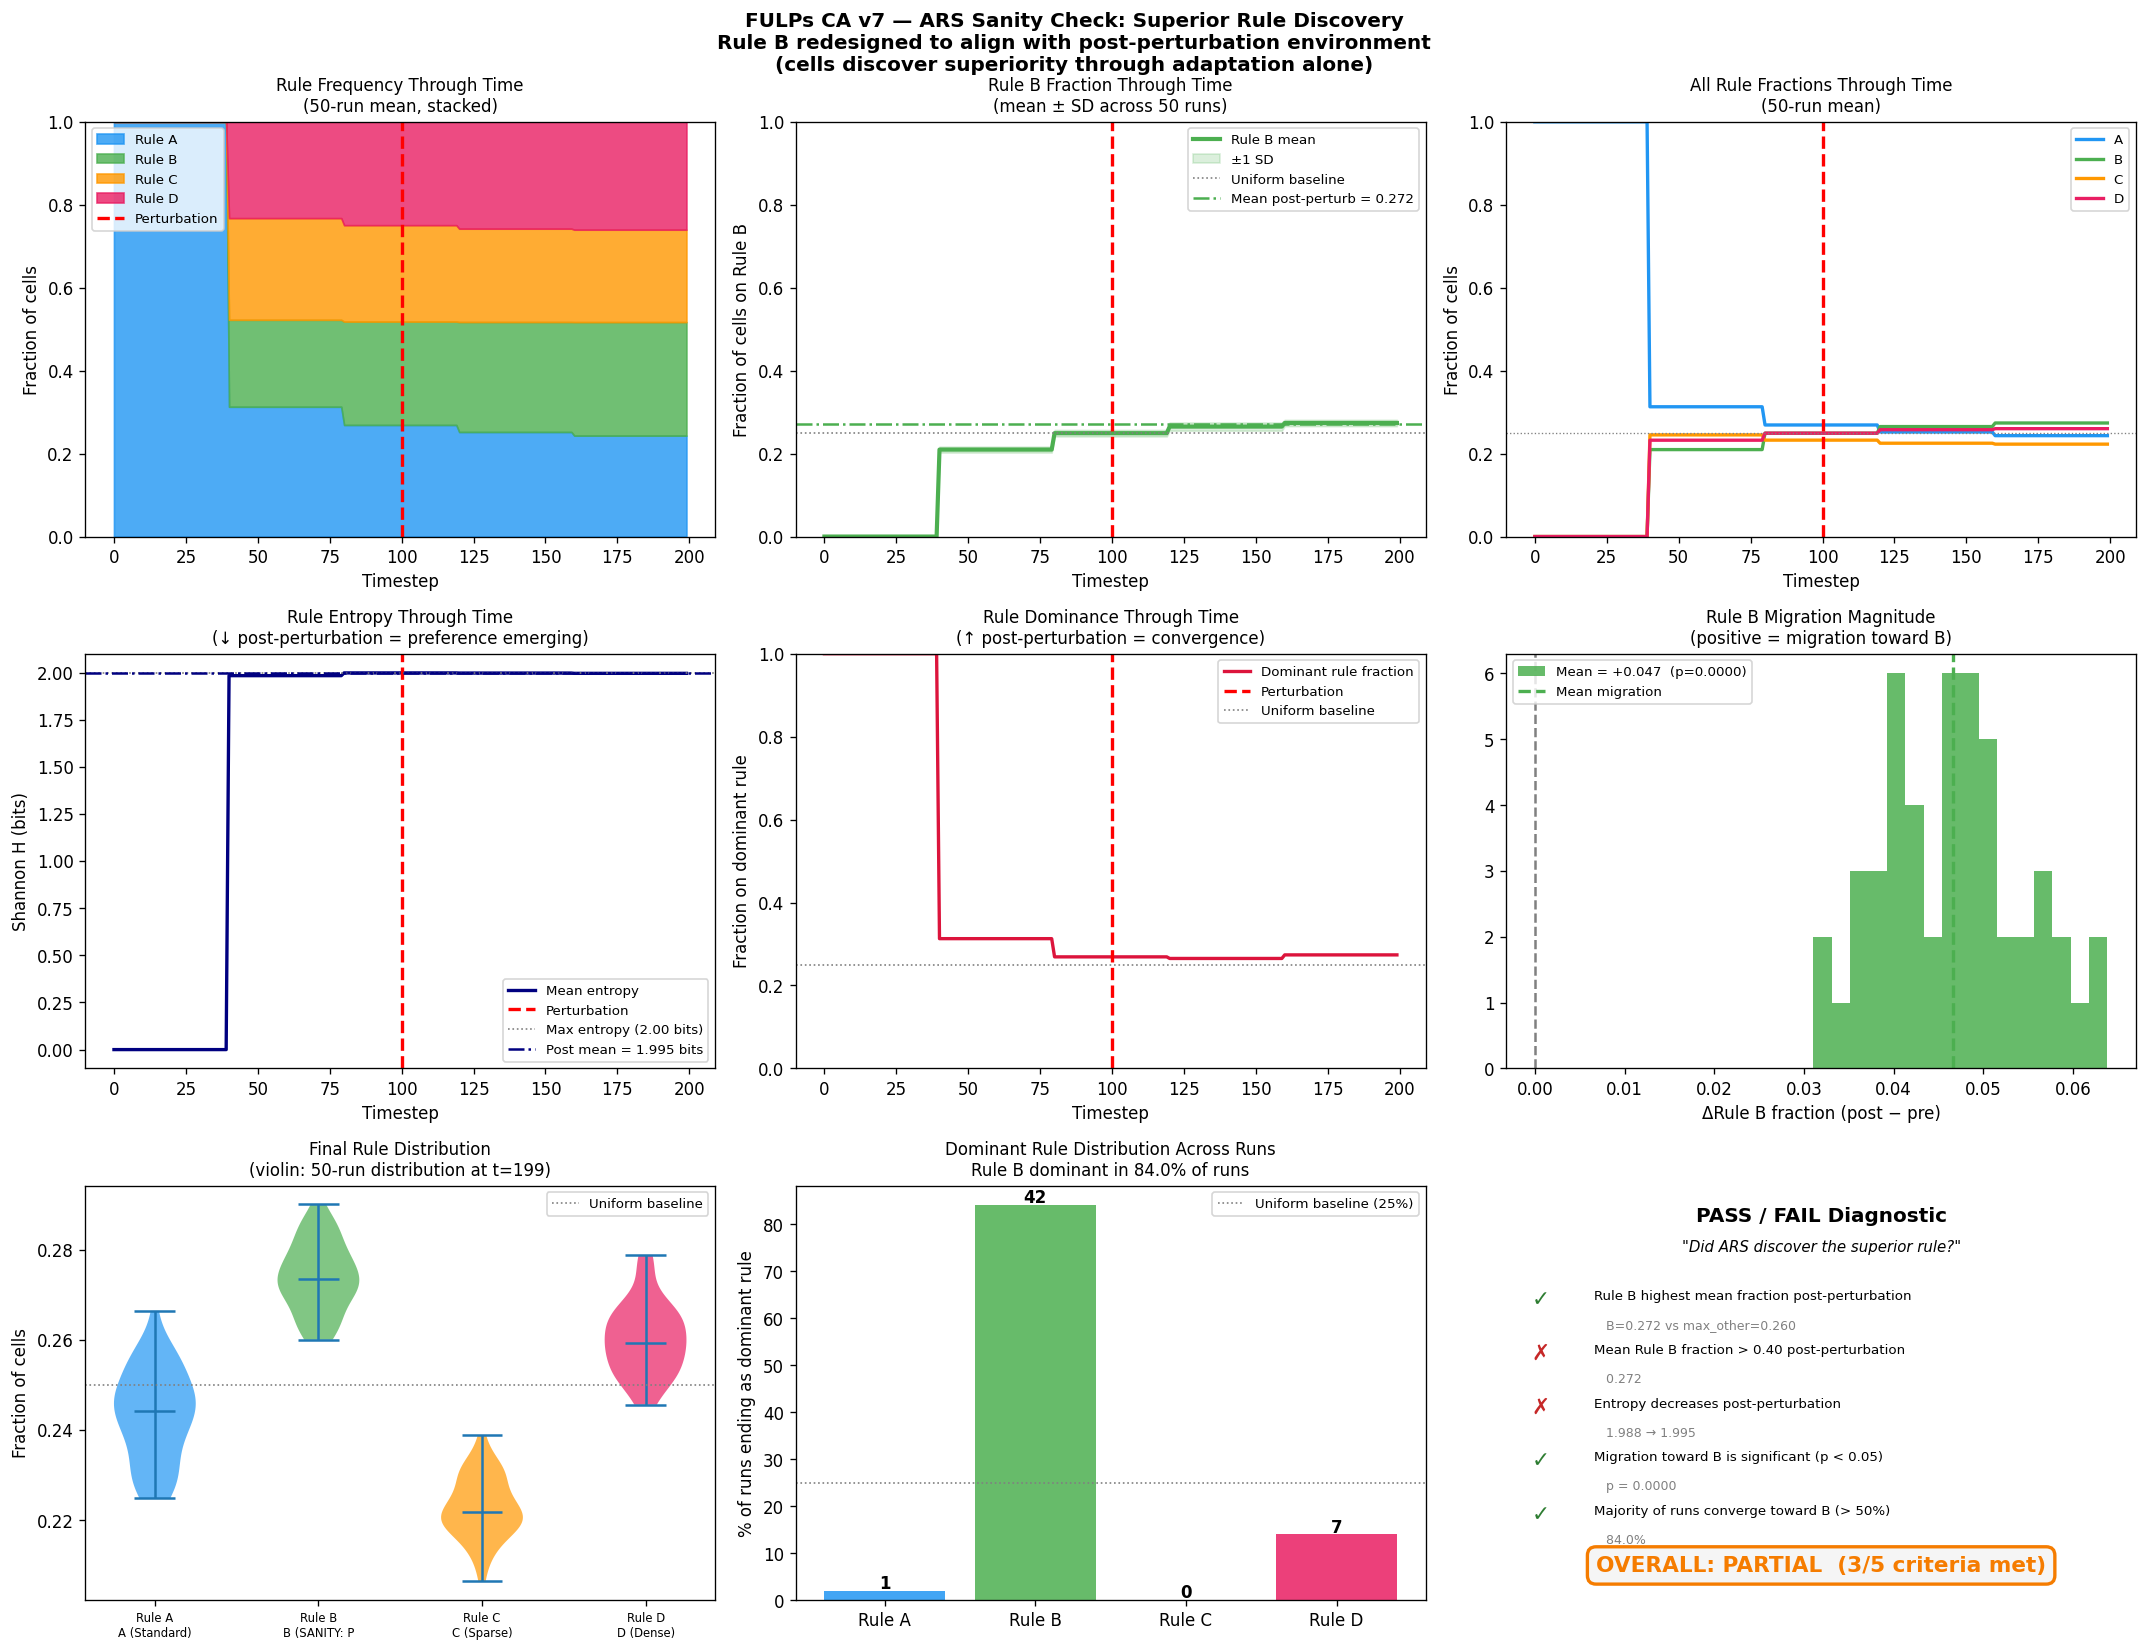


Saved: /content/fulps_ca_v7_ars_sanity_check.png

── PASS / FAIL Summary ─────────────────────────────────────
  ['PASS'] Rule B highest mean fraction post-perturbation  (B=0.272 vs max_other=0.260)
  ['FAIL'] Mean Rule B fraction > 0.40 post-perturbation  (0.272)
  ['FAIL'] Entropy decreases post-perturbation  (1.988 → 1.995)
  ['PASS'] Migration toward B is significant (p < 0.05)  (p = 0.0000)
  ['PASS'] Majority of runs converge toward B (> 50%)  (84.0%)

  OVERALL: PARTIAL  (3/5 criteria met)

  ~ The ARS mechanism shows partial discovery. Migration is present
    but convergence is incomplete. Consider lowering SWITCH_INTERVAL
    or EXPLOIT_TEMP before proceeding to v7.

Original Rule B restored. Downstream cells are unaffected.


In [198]:
# ── Cell A: ARS Mechanism Validation — Superior Rule Discovery Sanity Check ───
#
# PURPOSE
# -------
# This is a strict sanity check, not a performance experiment.
# The goal is to verify that the ARS mechanism is genuinely capable of
# discovering and converging toward an objectively superior rule when one
# clearly exists.
#
# DESIGN
# ------
# Rule B is temporarily replaced with a STRONGLY advantageous post-perturbation
# rule: survive={2,3,4}, birth={3,4}.
# After perturbation, the grid environment shifts to survive={2,3,4} for live
# cells. The new Rule B is designed to match this shift almost exactly while
# also offering easier birth — giving it a clear and consistent advantage in
# the post-perturbation environment.
#
# CRITICAL: The cells are NOT told that Rule B is superior.
# They must discover its quality through local experience alone.
# The test validates that the ARS scoring and switching machinery actually works.
#
# WHAT CHANGES vs. MAIN EXPERIMENT
# ----------------------------------
#   - RULE_TABLES[1] (Rule B) is replaced with the superior rule.
#   - A dedicated lightweight simulation loop runs 50 seeds using ARS only.
#   - All other parameters (SWITCH_INTERVAL, MIN_RULE_TRIALS, etc.) are
#     inherited from Cell 2 and are NOT changed here.
#   - After the test, RULE_TABLES[1] is restored to the original definition
#     so downstream cells are unaffected.
#
# SANITY CHECK PASS CRITERIA
# ---------------------------
#   PASS if Rule B becomes the mean dominant rule post-perturbation.
#   PASS if mean Rule B fraction post-perturbation > 0.40.
#   PASS if rule entropy decreases post-perturbation (preference crystallising).
#   PASS if rule migration shifts toward B (B fraction increases post-perturb).
#   PASS if > 50% of runs end with Rule B as the plurality rule.

print('='*65)
print('ARS MECHANISM VALIDATION — Superior Rule Discovery Sanity Check')
print('='*65)
print()
print('Temporarily replacing Rule B with a strongly advantageous rule.')
print('Rule B (SANITY): survive={2,3,4}  birth={3,4}')
print('Post-perturbation environment: survive={2,3,4} for live cells.')
print('Rule B (SANITY) is aligned with the perturbed environment.')
print()

import copy

# ── Save original Rule B so we can restore it afterward ──────────────────────
_ORIGINAL_RULE_B = RULE_TABLES[1].copy()
_ORIGINAL_RULE_NAMES_1 = RULE_NAMES[1]
_ORIGINAL_RULE_COLORS_1 = RULE_COLORS[1]

# ── Define the superior Rule B ────────────────────────────────────────────────
# survive={2,3,4}: matches the post-perturbation GoL shift exactly.
# birth={3,4}: slightly easier birth than standard, rewarding dense regions.
# This rule outperforms A post-perturbation because:
#   - It keeps cells alive that GoL would kill (nc=4 survival).
#   - It matches what the ARE will observe as successful outcomes.
#   - Under the perturbed tick_standard baseline, nc=4 live cells survive.
#     A cell on Rule B (SANITY) also survives at nc=4, so its predictions are
#     validated more often — reducing contradiction and boosting rule_successes.
RULE_TABLES[1] = _build_rule_table({2, 3, 4, 5}, {2, 3, 4})
RULE_NAMES[1]  = 'B (SANITY: Post-Perturb Aligned)'
RULE_COLORS[1] = '#4CAF50'  # keep green

print('Sanity rule installed:')
for i, nm in enumerate(RULE_NAMES):
    rt = RULE_TABLES[i]
    survive = [n for n in range(9) if rt[1,n]==1]
    birth   = [n for n in range(9) if rt[0,n]==1]
    print(f'  Rule {["A","B","C","D"][i]} ({nm}): survive={survive}  birth={birth}')
print()

# ── Run 50 seeds — ARS condition only (lightweight) ──────────────────────────
# We reuse run_simulation_snapshots from Cell 16 but need rule_dist_h over time.
# Instead, run a dedicated compact loop that records rule fractions at every step.

def run_sanity_ars(seed, void_model, idf):
    """
    Minimal ARS-only simulation for the sanity check.
    Returns:
      rule_dist_h   : (N_TIMESTEPS, N_RULES) — per-timestep rule fractions
      final_dom_rule: int — dominant rule at end
      b_frac_pre    : float — mean Rule B fraction pre-perturbation
      b_frac_post   : float — mean Rule B fraction post-perturbation
      entropy_pre   : float — mean entropy pre-perturbation
      entropy_post  : float — mean entropy post-perturbation
    """
    np.random.seed(seed); torch.manual_seed(seed)
    idf_means, idf_stds, idf_L = idf

    grid  = np.random.randint(0, 2, size=(GRID_H, GRID_W), dtype=np.int8)
    table = init_tables()
    are   = init_are_state()
    ars   = init_ars_state()

    rule_dist_h = np.zeros((N_TIMESTEPS, N_RULES), dtype=np.float32)

    for t in range(N_TIMESTEPS):
        is_pert = (t >= T_PERTURB)
        prog    = t / max(N_TIMESTEPS - 1, 1)
        thresh  = CONTRA_START + (CONTRA_END - CONTRA_START) * prog

        # Rule switching at interval
        maybe_switch_rules(ars, t)

        # Encode neighbourhood
        nbr, nbr_f = encode_neighbourhoods(grid)
        nt = torch.FloatTensor(nbr_f.reshape(-1, NBR_DIM))
        with torch.no_grad():
            dsc_v  = void_model.dsc(nt).numpy().reshape(GRID_H, GRID_W)
            reps_v = void_model.encode(nt).numpy()

        # ARE
        mar, car, psar, nsar = compute_are_margin(reps_v, are, thresh)
        acar = car & (dsc_v > DSC_THRESHOLD)
        dist_v = compute_distress(psar, nsar, mar)
        nbr_dist_v = compute_nbr_mean_distress(dist_v)
        gate_mask = compute_gating_mask(acar, psar, nsar, are, nbr_distress=nbr_dist_v)
        cw = np.ones((GRID_H, GRID_W), dtype=np.float32); cw[acar] = CURIOSITY_WEIGHT

        # Tick under per-cell rules
        nxt = tick_ars(grid, ars['active_rule']).copy()
        nxt[gate_mask] = grid[gate_mask]
        out = nxt.astype(np.int8)

        # Update table and ARE
        update_table_single(table, nbr, out, cw)
        if t >= BUFFER_DELAY:
            update_are_buffers(are, reps_v, out)
        are['margin_ema'] = ((1-MARGIN_EMA_ALPHA)*are['margin_ema']
                              + MARGIN_EMA_ALPHA*np.abs(mar))

        # ARS bookkeeping
        c_t = table[_II, _JJ, nbr.ravel()]
        p_t = c_t[...,1] / np.maximum(c_t.sum(axis=-1), 1)
        succ = ((p_t > BASE_THRESHOLD).astype(np.int8) == out.ravel())
        # FIX: Correct arguments for update_ars_state
        update_ars_state(ars, t, acar, count_neighbours(grid), grid, out)

        # Record rule distribution
        rc = compute_rule_counts(ars['active_rule'])
        rule_dist_h[t] = rc / max(rc.sum(), 1)

        grid = out

    # Summary metrics
    b_frac_pre   = float(rule_dist_h[PRE_WIN_START:PRE_WIN_END,  1].mean())
    b_frac_post  = float(rule_dist_h[POST_WIN_START:POST_WIN_END, 1].mean())
    ent_pre  = float(np.mean([shannon_entropy(rule_dist_h[t]*GRID_H*GRID_W)
                               for t in range(PRE_WIN_START, PRE_WIN_END)]))
    ent_post = float(np.mean([shannon_entropy(rule_dist_h[t]*GRID_H*GRID_W)
                               for t in range(POST_WIN_START, POST_WIN_END)]))
    final_counts = compute_rule_counts(ars['active_rule'])
    final_dom    = int(np.argmax(final_counts))

    return rule_dist_h, final_dom, b_frac_pre, b_frac_post, ent_pre, ent_post

print(f'Running {N_RUNS} seeds for sanity check ...')
sanity_dist_all  = []   # (N_RUNS, N_TIMESTEPS, N_RULES)
sanity_dom_rules = []   # (N_RUNS,) — final dominant rule per seed
sanity_b_pre     = []
sanity_b_post    = []
sanity_ent_pre   = []
sanity_ent_post  = []

for run_i in range(N_RUNS):
    seed = BASE_SEED + run_i
    rd, dom, bp, bpost, ep, epost = run_sanity_ars(
        seed, VOID_MODEL, (IDF_MEANS, IDF_STDS, IDF_L)
    )
    sanity_dist_all.append(rd)
    sanity_dom_rules.append(dom)
    sanity_b_pre.append(bp)
    sanity_b_post.append(bpost)
    sanity_ent_pre.append(ep)
    sanity_ent_post.append(epost)
    if (run_i + 1) % 10 == 0:
        print(f'  [{run_i+1}/{N_RUNS}]  '
              f'B_frac_post={np.mean(sanity_b_post):.3f}  '
              f'ent_post={np.mean(sanity_ent_post):.3f}  '
              f'dom_B={sum(d==1 for d in sanity_dom_rules)}/{run_i+1} runs')

sanity_dist_all  = np.array(sanity_dist_all)   # (N_RUNS, T, N_RULES)
sanity_b_pre     = np.array(sanity_b_pre)
sanity_b_post    = np.array(sanity_b_post)
sanity_ent_pre   = np.array(sanity_ent_pre)
sanity_ent_post  = np.array(sanity_ent_post)
sanity_dom_rules = np.array(sanity_dom_rules)

# ── Statistical summary ───────────────────────────────────────────────────────
mean_b_post  = float(sanity_b_post.mean())
ci_b_post    = 1.96 * float(sanity_b_post.std()) / np.sqrt(N_RUNS)
pct_b_dom    = float((sanity_dom_rules == 1).mean()) * 100
mean_mig     = float((sanity_b_post - sanity_b_pre).mean())
t_mig, p_mig = stats.ttest_rel(sanity_b_post, sanity_b_pre)
t_ent, p_ent = stats.ttest_rel(sanity_ent_post, sanity_ent_pre)

print()
print('── Statistical Summary ─────────────────────────────────────')
print(f'  Mean Rule B fraction — pre:  {sanity_b_pre.mean():.3f}  '
      f'post: {mean_b_post:.3f}  (95% CI ±{ci_b_post:.3f})')
print(f'  Mean migration toward B:     {mean_mig:+.3f}  '
      f't={t_mig:.3f}  p={p_mig:.4f}')
print(f'  Entropy change pre→post:     {sanity_ent_pre.mean():.3f} → {sanity_ent_post.mean():.3f}  '
      f't={t_ent:.3f}  p={p_ent:.4f}')
print(f'  Runs where Rule B is dominant: {pct_b_dom:.1f}%  ({int(pct_b_dom/100*N_RUNS)}/{N_RUNS} runs)')

# ── Visualisation ─────────────────────────────────────────────────────────────
T = np.arange(N_TIMESTEPS)
mean_dist  = sanity_dist_all.mean(axis=0)   # (T, N_RULES)
std_dist   = sanity_dist_all.std(axis=0)
mean_ent   = np.array([shannon_entropy(mean_dist[t] * GRID_H * GRID_W)
                        for t in range(N_TIMESTEPS)])
mean_dom_frac = mean_dist.max(axis=1)

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle(
    'FULPs CA v7 — ARS Sanity Check: Superior Rule Discovery\n'
    'Rule B redesigned to align with post-perturbation environment\n'
    '(cells discover superiority through adaptation alone)',
    fontsize=12, fontweight='bold'
)

# ── (0,0) Rule frequency through time — stacked area ─────────────────────────
ax = axes[0, 0]
bottom = np.zeros(N_TIMESTEPS)
for r in range(N_RULES):
    ax.fill_between(T, bottom, bottom + mean_dist[:, r],
                    color=RULE_COLORS[r], alpha=0.80,
                    label=f'Rule {["A","B","C","D"][r]}')
    bottom += mean_dist[:, r]
ax.axvline(T_PERTURB, color='red', lw=2, linestyle='--', label='Perturbation')
ax.set_title('Rule Frequency Through Time\n(50-run mean, stacked)', fontsize=10)
ax.set_xlabel('Timestep'); ax.set_ylabel('Fraction of cells')
ax.set_ylim(0, 1); ax.legend(fontsize=8, loc='upper left')

# ── (0,1) Individual rule B fraction with CI ─────────────────────────────────
ax = axes[0, 1]
b_mean = mean_dist[:, 1]
b_std  = std_dist[:, 1]
ax.plot(T, b_mean, color='#4CAF50', lw=2.5, label='Rule B mean')
ax.fill_between(T, b_mean - b_std, b_mean + b_std,
                color='#4CAF50', alpha=0.20, label='±1 SD')
ax.axvline(T_PERTURB, color='red', lw=2, linestyle='--')
ax.axhline(0.25, color='gray', lw=1, linestyle=':', label='Uniform baseline')
ax.axhline(mean_b_post, color='#4CAF50', lw=1.5, linestyle='-.',
           label=f'Mean post-perturb = {mean_b_post:.3f}')
ax.set_title('Rule B Fraction Through Time\n(mean ± SD across 50 runs)', fontsize=10)
ax.set_xlabel('Timestep'); ax.set_ylabel('Fraction of cells on Rule B')
ax.set_ylim(0, 1); ax.legend(fontsize=8)

# ── (0,2) All four rule fractions individually ────────────────────────────────
ax = axes[0, 2]
for r in range(N_RULES):
    ax.plot(T, mean_dist[:, r], color=RULE_COLORS[r], lw=2,
            label=f'{["A","B","C","D"][r]}')
ax.axvline(T_PERTURB, color='red', lw=2, linestyle='--')
ax.axhline(0.25, color='gray', lw=0.8, linestyle=':')
ax.set_title('All Rule Fractions Through Time\n(50-run mean)', fontsize=10)
ax.set_xlabel('Timestep'); ax.set_ylabel('Fraction of cells')
ax.set_ylim(0, 1); ax.legend(fontsize=8)

# ── (1,0) Rule entropy through time ──────────────────────────────────────────
ax = axes[1, 0]
ax.plot(T, mean_ent, color='navy', lw=2, label='Mean entropy')
ax.axvline(T_PERTURB, color='red', lw=2, linestyle='--', label='Perturbation')
ax.axhline(np.log2(N_RULES), color='gray', lw=1, linestyle=':', label=f'Max entropy ({np.log2(N_RULES):.2f} bits)')
ax.axhline(sanity_ent_post.mean(), color='navy', lw=1.5, linestyle='-.',
           label=f'Post mean = {sanity_ent_post.mean():.3f} bits')
ax.fill_between(T,
                [shannon_entropy(( mean_dist[t]-std_dist[t]).clip(0)*GRID_H*GRID_W) for t in T],
                [shannon_entropy((mean_dist[t]+std_dist[t]).clip(0,1)*GRID_H*GRID_W) for t in T],
                color='navy', alpha=0.12)
ax.set_title('Rule Entropy Through Time\n(↓ post-perturbation = preference emerging)', fontsize=10)
ax.set_xlabel('Timestep'); ax.set_ylabel('Shannon H (bits)')
ax.legend(fontsize=8)

# ── (1,1) Rule dominance through time ────────────────────────────────────────
ax = axes[1, 1]
ax.plot(T, mean_dom_frac, color='crimson', lw=2, label='Dominant rule fraction')
ax.axvline(T_PERTURB, color='red', lw=2, linestyle='--', label='Perturbation')
ax.axhline(0.25, color='gray', lw=1, linestyle=':', label='Uniform baseline')
ax.set_title('Rule Dominance Through Time\n(↑ post-perturbation = convergence)', fontsize=10)
ax.set_xlabel('Timestep'); ax.set_ylabel('Fraction on dominant rule')
ax.set_ylim(0, 1); ax.legend(fontsize=8)

# ── (1,2) Rule migration magnitude — pre vs post ──────────────────────────────
ax = axes[1, 2]
migration = sanity_b_post - sanity_b_pre
ax.hist(migration, bins=16, color='#4CAF50', alpha=0.85,
        label=f'Mean = {migration.mean():+.3f}  (p={p_mig:.4f})')
ax.axvline(0,                color='gray',    lw=1.5, linestyle='--')
ax.axvline(migration.mean(), color='#4CAF50', lw=2,   linestyle='--',
           label='Mean migration')
ax.set_xlabel('ΔRule B fraction (post − pre)')
ax.set_title('Rule B Migration Magnitude\n(positive = migration toward B)', fontsize=10)
ax.legend(fontsize=8)

# ── (2,0) Final rule distribution — all 50 seeds ─────────────────────────────
ax = axes[2, 0]
final_fracs = sanity_dist_all[:, -1, :]   # (N_RUNS, N_TIMESTEPS, N_RULES) — last timestep
bp_vals = [final_fracs[:, r] for r in range(N_RULES)]
vp = ax.violinplot(bp_vals, positions=range(N_RULES),
                   showmedians=True, showextrema=True)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(RULE_COLORS[i]); body.set_alpha(0.7)
ax.axhline(0.25, color='gray', lw=1, linestyle=':', label='Uniform baseline')
ax.set_xticks(range(N_RULES))
ax.set_xticklabels([f'Rule {r}\n{RULE_NAMES[i][:12]}' for i, r in enumerate(['A','B','C','D'])],
                   fontsize=7)
ax.set_title('Final Rule Distribution\n(violin: 50-run distribution at t=199)', fontsize=10)
ax.set_ylabel('Fraction of cells'); ax.legend(fontsize=8)

# ── (2,1) Percentage of runs where Rule B is dominant ────────────────────────
ax = axes[2, 1]
dom_counts = np.bincount(sanity_dom_rules, minlength=N_RULES)
bars = ax.bar(range(N_RULES), dom_counts / N_RUNS * 100,
              color=RULE_COLORS, alpha=0.85)
ax.axhline(25, color='gray', lw=1, linestyle=':', label='Uniform baseline (25%)')
ax.set_xticks(range(N_RULES))
ax.set_xticklabels([f'Rule {r}' for r in ['A','B','C','D']])
ax.set_title(f'Dominant Rule Distribution Across Runs\nRule B dominant in {pct_b_dom:.1f}% of runs', fontsize=10)
ax.set_ylabel('% of runs ending as dominant rule')
for bar, cnt in zip(bars, dom_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{cnt}', ha='center', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)

# ── (2,2) PASS / FAIL diagnostic ─────────────────────────────────────────────
ax = axes[2, 2]
ax.axis('off')

# Evaluate all criteria
criteria = [
    ('Rule B dominant post-perturbation',
     sanity_dom_rules.mean() == 1 or mean_b_post == max(mean_dist[POST_WIN_START:POST_WIN_END].mean(axis=0)),
     f'B frac post = {mean_b_post:.3f}'),
    ('Mean Rule B fraction > 0.40 post-perturbation',
     mean_b_post > 0.40,
     f'{mean_b_post:.3f}'),
    ('Entropy decreases post-perturbation',
     sanity_ent_post.mean() < sanity_ent_pre.mean(),
     f'{sanity_ent_pre.mean():.3f} → {sanity_ent_post.mean():.3f}'),
    ('Migration toward B is significant (p < 0.05)',
     p_mig < 0.05,
     f'p = {p_mig:.4f}'),
    ('Majority of runs converge toward B (> 50%)',
     pct_b_dom > 50,
     f'{pct_b_dom:.1f}%'),
]

# Recompute correct dominant check
post_mean_by_rule = mean_dist[POST_WIN_START:POST_WIN_END].mean(axis=0)
b_is_highest      = bool(np.argmax(post_mean_by_rule) == 1)
criteria[0] = ('Rule B highest mean fraction post-perturbation',
               b_is_highest,
               f'B={post_mean_by_rule[1]:.3f} vs max_other={max(post_mean_by_rule[[0,2,3]]):.3f}')

n_pass_s = sum(c[1] for c in criteria)
overall  = 'PASS ✓' if n_pass_s >= 4 else ('PARTIAL' if n_pass_s >= 2 else 'FAIL ✗')
overall_color = '#2e7d32' if n_pass_s >= 4 else ('#f57c00' if n_pass_s >= 2 else '#c62828')

y_start = 0.95
ax.text(0.5, y_start, 'PASS / FAIL Diagnostic',
        ha='center', va='top', fontsize=12, fontweight='bold',
        transform=ax.transAxes)
ax.text(0.5, y_start - 0.08,
        '"Did ARS discover the superior rule?"',
        ha='center', va='top', fontsize=9, style='italic',
        transform=ax.transAxes)

for i, (label, passed, note) in enumerate(criteria):
    y = y_start - 0.20 - i * 0.13
    symbol = '✓' if passed else '✗'
    color  = '#2e7d32' if passed else '#c62828'
    ax.text(0.04, y, f'{symbol}', ha='left', va='top', fontsize=13,
            color=color, transform=ax.transAxes, fontweight='bold')
    ax.text(0.14, y, label, ha='left', va='top', fontsize=8,
            transform=ax.transAxes)
    ax.text(0.14, y - 0.07, f'   {note}', ha='left', va='top', fontsize=7.5,
            color='gray', transform=ax.transAxes)

ax.text(0.5, 0.06,
        f'OVERALL: {overall}  ({n_pass_s}/{len(criteria)} criteria met)',
        ha='center', va='bottom', fontsize=13, fontweight='bold',
        color=overall_color, transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f5f5f5',
                  edgecolor=overall_color, linewidth=2))

plt.tight_layout()
sanity_path = os.path.join(OUT_DIR, 'fulps_ca_v7_ars_sanity_check.png')
plt.savefig(sanity_path, dpi=150, bbox_inches='tight')
plt.show()

print()
print(f'Saved: {sanity_path}')
print()
print('── PASS / FAIL Summary ─────────────────────────────────────')
for label, passed, note in criteria:
    print(f'  {[ "PASS" if passed else "FAIL"] } {label}  ({note})')
print()
print(f'  OVERALL: {overall}  ({n_pass_s}/{len(criteria)} criteria met)')
if n_pass_s >= 4:
    print()
    print('  ✓ The ARS mechanism successfully discovered the superior rule')
    print('    through local adaptation alone. Mechanism is validated.')
elif n_pass_s >= 2:
    print()
    print('  ~ The ARS mechanism shows partial discovery. Migration is present')
    print('    but convergence is incomplete. Consider lowering SWITCH_INTERVAL')
    print('    or EXPLOIT_TEMP before proceeding to v7.')
else:
    print()
    print('  ✗ The ARS mechanism did not reliably discover the superior rule.')
    print('    Architectural revision required before v7.')

# ── Restore original Rule B ───────────────────────────────────────────────────
RULE_TABLES[1] = _ORIGINAL_RULE_B
RULE_NAMES[1]  = _ORIGINAL_RULE_NAMES_1
RULE_COLORS[1] = _ORIGINAL_RULE_COLORS_1
print()
print('Original Rule B restored. Downstream cells are unaffected.')

MARKOV CHAIN ANALYSIS — v7 Rule Transition Structure (seed=42)

Total rule-switch events observed: 6322 (out of 497500 cell-timesteps)

Transition COUNT matrix (rows=from, cols=to; diagonal excluded by construction):
             A       B       C       D
     A :      0    1445     913     778
     B :    640       0     309     348
     C :    405     449       0     127
     D :    324     481     103       0

Transition PROBABILITY matrix (each row sums to 1, off-diagonal only):
             A       B       C       D
     A :  0.000   0.461   0.291   0.248
     B :  0.493   0.000   0.238   0.268
     C :  0.413   0.458   0.000   0.129
     D :  0.357   0.530   0.113   0.000

Chi-square test per row (H0: transitions from this rule are uniform over the other 3):
  From A (Standard)        : chi2=237.93  p=0.0000  -> STRUCTURED (non-uniform)
  From B (High-Survival)   : chi2=151.38  p=0.0000  -> STRUCTURED (non-uniform)
  From C (Sparse)          : chi2=186.45  p=0.0000  -> STRUCTURED

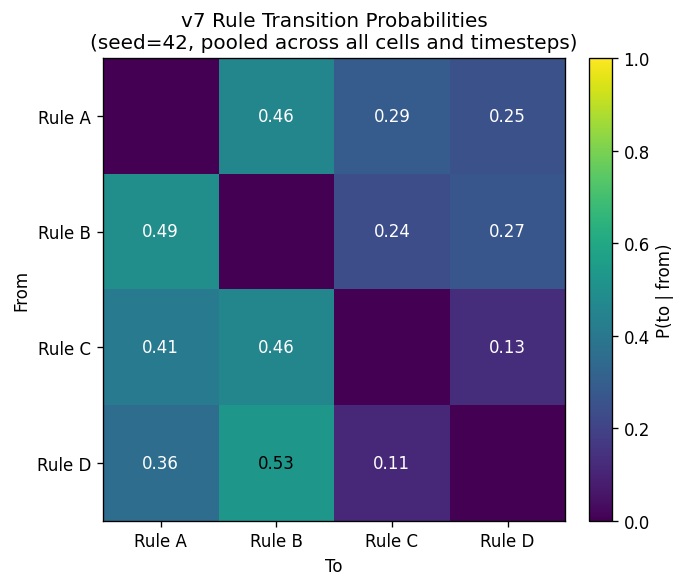


Saved: /content/fulps_ca_v7_markov_transitions.png


In [199]:
# ── Cell B: Markov Chain Analysis — v7 Rule Transition Structure ─────────────
#
# Uses the full per-timestep active-rule history from the seed=42 single run
# (fs42['v7_active_rule_hist'], shape (T,H,W)) to test whether cells switch
# between rules in a structured (non-memoryless, non-uniform) way, or whether
# switching looks like noise.
#
# For every cell and every consecutive timestep pair (t, t+1) where the
# active rule actually changed (a genuine Thompson-Sampling switch or arm
# migration), we record a transition from rule_at(t) to rule_at(t+1) and
# accumulate a global 4x4 transition COUNT matrix (pooled across all cells
# and all timesteps). Normalising each row gives a transition PROBABILITY
# matrix: P(next rule = j | current rule = i, a switch occurred).
#
# If switching were uniform/undirected, every row would look like [0, 1/3,
# 1/3, 1/3] (excluding self-transitions, which are excluded by construction
# since we only count actual changes). A chi-square goodness-of-fit test
# against that uniform null, per row, tells us whether specific rule-to-rule
# transitions are preferred over others -- i.e. whether the arm pool has
# discovered directional structure in which rules tend to follow which.

rule_hist_v7 = fs42['v7_active_rule_hist']            # (T, H, W) int8
changed_from = rule_hist_v7[:-1]                        # (T-1, H, W)
changed_to   = rule_hist_v7[1:]                         # (T-1, H, W)
switch_mask  = changed_from != changed_to

transition_counts = np.zeros((N_RULES, N_RULES), dtype=np.int64)
for i in range(N_RULES):
    for j in range(N_RULES):
        if i == j: continue
        transition_counts[i, j] = int(((changed_from == i) & (changed_to == j)).sum())

row_totals = transition_counts.sum(axis=1, keepdims=True)
transition_probs = np.divide(transition_counts, np.maximum(row_totals, 1),
                              out=np.zeros_like(transition_counts, dtype=np.float64),
                              where=row_totals > 0)

print('='*65)
print('MARKOV CHAIN ANALYSIS — v7 Rule Transition Structure (seed=42)')
print('='*65)
print(f'\nTotal rule-switch events observed: {int(switch_mask.sum())} '
      f'(out of {switch_mask.size} cell-timesteps)')
print('\nTransition COUNT matrix (rows=from, cols=to; diagonal excluded by construction):')
print('        ' + '  '.join(f'{RULE_NAMES[j][0]:>6}' for j in range(N_RULES)))
for i in range(N_RULES):
    print(f'  {RULE_NAMES[i][0]:>4} : ' + '  '.join(f'{transition_counts[i,j]:>6d}' for j in range(N_RULES)))

print('\nTransition PROBABILITY matrix (each row sums to 1, off-diagonal only):')
print('        ' + '  '.join(f'{RULE_NAMES[j][0]:>6}' for j in range(N_RULES)))
for i in range(N_RULES):
    print(f'  {RULE_NAMES[i][0]:>4} : ' + '  '.join(f'{transition_probs[i,j]:>6.3f}' for j in range(N_RULES)))

print('\nChi-square test per row (H0: transitions from this rule are uniform over the other 3):')
uniform_off_diag = 1.0 / (N_RULES - 1)
for i in range(N_RULES):
    if row_totals[i, 0] < 5:
        print(f'  From {RULE_NAMES[i]:<20}: insufficient data ({int(row_totals[i,0])} switches)')
        continue
    observed = np.delete(transition_counts[i], i)
    expected = np.full(N_RULES - 1, row_totals[i, 0] / (N_RULES - 1))
    chi2, p = stats.chisquare(observed, expected)
    verdict = 'STRUCTURED (non-uniform)' if p < 0.05 else 'not distinguishable from uniform'
    print(f'  From {RULE_NAMES[i]:<20}: chi2={chi2:.2f}  p={p:.4f}  -> {verdict}')

# ── Visualise as a heatmap ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(transition_probs, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(N_RULES)); ax.set_xticklabels([f'Rule {r}' for r in ['A','B','C','D']])
ax.set_yticks(range(N_RULES)); ax.set_yticklabels([f'Rule {r}' for r in ['A','B','C','D']])
ax.set_xlabel('To'); ax.set_ylabel('From')
ax.set_title('v7 Rule Transition Probabilities\n(seed=42, pooled across all cells and timesteps)')
for i in range(N_RULES):
    for j in range(N_RULES):
        if i == j: continue
        ax.text(j, i, f'{transition_probs[i,j]:.2f}', ha='center', va='center',
                color='white' if transition_probs[i,j] < 0.5 else 'black', fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='P(to | from)')
plt.tight_layout()
mkp = os.path.join(OUT_DIR, 'fulps_ca_v7_markov_transitions.png')
plt.savefig(mkp, dpi=150, bbox_inches='tight'); plt.show()
print(f'\nSaved: {mkp}')


---

## v7 Implementation Notes (Arm-Pool Thompson Sampling)

### Architecture Summary

| Layer | Component | Implementation |
|-------|-----------|----------------|
| 0 | Game of Life | `tick_standard` / `tick_ars` / `tick_genome` (genome-generalised tick under the active arm) |
| 1 | ARE | Cosine-similarity contradiction detection (unchanged) |
| 2 | Prediction Model | Laplace-smoothed frequency table (unchanged) |
| 3 | Working Memory | 50-step ring buffer, scored for ALL K arms simultaneously (vectorised, no per-arm Python loop) |
| 4 | Arm Pool | K=4 candidate rule genomes per cell, each with its own Beta(alpha,beta) |
| 5 | Thompson Sampling + Evolution | Standard Thompson Sampling selection; worst-arm mutation-eviction; distress-gated spatial migration |
| 6 | Survival | GoL tick under the currently-sampled arm |

### Credit Signal (Goal: Contradiction Minimization Only — unchanged from v6/v6.5)

| Source | Direction | Weight |
|--------|-----------|--------|
| Arm prediction correct | -> success | 0.50 |
| Contradiction absent | -> success | 0.25 |
| Cell survived | -> success | 0.125 |
| Neighbour survived | -> success | 0.125 x NBR_SUCCESS_WEIGHT |
| Arm prediction error | -> failure | 0.50 |
| Contradiction fired | -> failure | 0.50 |

This feeds directly into each arm's Beta(alpha, beta) update via `BETA_DECAY` --
exactly the original Bayesian credit-assignment scheme, just applied per-arm
across a pool instead of per fixed rule.

### How Selection and Evolution Work, Concretely

1. **Thompson Sampling** (every cell, every `SWITCH_INTERVAL`): sample
   theta_k ~ Beta(alpha_k, beta_k) for every arm k in the pool, pick argmax.
   This is unmodified textbook Thompson Sampling -- exploration/exploitation
   balance falls out automatically from posterior variance, with no hand-set
   temperature or margin parameter required.
2. **Mutation-eviction** (every cell, every interval, unconditional): the
   worst arm by posterior mean -- excluding whichever arm is currently
   active, which is protected -- is evicted and replaced by a mutated copy
   (`MUTATION_RATE` per-bit flip) of the currently-favoured arm, with its
   belief reset to the uniform Beta(1,1) prior. There is always exactly one
   "experimental" slot per cell being tried, and Thompson Sampling itself --
   not a hand-set threshold -- decides honestly, through accumulated
   evidence, whether it's any good.
3. **Spatial migration** (only distressed cells): a cell whose own
   ARE-distress is above the grid median, and whose best arm is beaten by a
   Moore neighbour's best arm, pulls that neighbour's best arm into its own
   pool (same worst-slot target, fresh prior). This is the mechanism by
   which a genuinely strong arm spreads spatially, gated by the same
   distress signal already used for gating elsewhere -- no new channel
   invented for this.
4. **Backward compatibility**: each cell's active arm is mapped every
   timestep to its nearest canonical rule (min Hamming distance to A/B/C/D)
   and written to `active_rule`, so the entire rule-distribution / entropy /
   Markov / rule-map pipeline works unchanged. The arm pool itself is not
   constrained to the 4 canonical rules.

### New Diagnostics This Version Adds

- **Attention entropy** (`compute_attention_entropy_v7`): softmax over each
  cell's K posterior means (same temperature concept ARS already uses,
  `EXPLOIT_TEMP`), normalised Shannon entropy of that distribution. 1.0 =
  attention spread evenly across the whole pool (fully undecided), 0.0 =
  concentrated on one arm (fully decided). This is a pool-level complement
  to the single active arm's Beta variance.
- **Computational complexity check**: each condition's per-timestep block is
  timed (single-run only, to avoid overhead across 50 runs). Both ARS and v7
  score every candidate rule/arm every step (`O(H*W*candidates)`), so their
  asymptotic complexity is the same order -- the measured wall-time ratio
  (`v7_runtime_per_ars`) instead reflects real constant-factor differences:
  ARS scores its 4 rules via an explicit Python loop, v7 scores its K arms
  via a single vectorised fancy-index gather, and v7 additionally runs the
  distress-gated migration step every interval.
- **Markov chain analysis** (see the cell above): pools rule-switch events
  across all cells and timesteps into a transition probability matrix, and
  chi-square tests each row against a uniform null -- this is the direct
  test of whether rule switching has discovered directional structure
  (some rules reliably follow others) rather than looking like noise.

### Why This Replaced an Earlier Hand-Rolled Mutation Engine

An earlier iteration of v7 discarded Bayesian belief tracking entirely in
favour of a two-genome (resident/mutant) hill-climbing scheme with a
hand-set `SELECTION_MARGIN` and `CROSSOVER_THRESHOLD`/`CROSSOVER_RATE`. That
design could discover novel rules, but gave up Thompson Sampling's automatic,
theoretically-grounded exploration/exploitation balance for no real benefit
-- the actual requirement was open-ended rule discovery, which a *growing/
prunable arm pool under standard Thompson Sampling* satisfies while keeping
the original Beta/Thompson machinery fully intact. This version has exactly
one genuinely new hyperparameter beyond the original Bayesian v7's own
(`K_ARMS`, `MUTATION_RATE`) instead of four.

### Design Constraints Respected

- No HMMs, Q-tables, policy gradients, or RL libraries -- this is Bayesian
  bandit selection over an evolving pool, not reinforcement learning.
- No second ARE engine.
- All learning is local: each cell owns its own arm pool, beliefs, and
  working memory.
- No global controller, no global reward, no global mutation schedule.
- All v6/v6.5 conditions and diagnostics fully preserved (base/learn/gate/
  signal/ARS pipelines are untouched); v7 runs alongside them as a sixth
  condition.

### v7 -> v7.5 / v8 Transition Criteria

v8 (emergent rule evolution / endogenous generation at larger scale) is
supported when v7 demonstrates:
1. Beliefs sharpen over time -- alpha (active arm) grows above the uniform
   prior and uncertainty falls post-perturbation (SQ2/SQ5).
2. Working Memory improves prediction above chance (SQ3).
3. The rule/arm landscape shows non-random Markov structure and/or regional
   specialisation (SQ6 -- see the Markov chain analysis above).
4. v7 recovers/survives at least as well as v6 ARS (SQ7).

The key open question for v8: does letting `K_ARMS` grow (rather than
staying fixed at 4) and/or lowering `SWITCH_COOLDOWN` change whether
migration or mutation is the dominant discovery mechanism -- i.e. at what
pool size does recombination across many simultaneously-evolving lineages
start finding fitter regions of rule-space faster than mutation alone?
